In [1]:
import random
import logging
import numpy as np
import os
import re
import nibabel as nib
from _signal_tools import get_eigenvectors
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
import copy
from tqdm.auto import tqdm
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from osl_dynamics.data import Data, processing
from osl_dynamics.models.hmm import Config, Model
import math
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc
from collections import defaultdict
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, f_oneway, permutation_test

2026-04-24 09:17:53.024740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 09:17:53.028695: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 09:17:53.038618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777047473.054854 2579220 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777047473.059645 2579220 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777047473.073716 2579220 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

# Prepare Data

In [2]:
# Silence unnecessary messages
_logger = logging.getLogger("osl-dynamics")
_logger.setLevel(logging.CRITICAL + 1)

In [3]:
# Load data
experiment = 'LLstim' # rs, LLstim, or RLstim
data_prep_method = 'LEiDA' # PCA, ICA, or LEiDA
if data_prep_method == 'PCA':
    if experiment == 'rs':
        data_path = '../../CIMT_data/no_wm/rs_timecourse_csv_no_wm'
    elif experiment == 'LLstim':
        data_path = '../../CIMT_data/no_wm/LLstim_timecourse_csv_no_wm' # rsfMRI ROI time course CSVs
    elif experiment == 'RLstim':
        pass
    else:
        raise ValueError("Invalid experiment name")
            
    subj_order = []
    X = []
    y = []
    for tc in sorted(os.listdir(data_path)):
        subj_order.append(tc[:-4])
        X.append(np.loadtxt(os.path.join(data_path, tc), delimiter=','))
        y.append(tc[:12])
    
    X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
elif data_prep_method == 'ICA':
    if experiment == 'rs':
        data_path = '../../CIMT_data/no_wm/rs/rs_ICA_18c_hptf_ss'
        bad_ICs = [1, 6, 9, 18] # 1-based indexing
    elif experiment == 'LLstim':
        data_path = '../../CIMT_data/no_wm/LLstim/LLstim_ICA_18c_hptf_ss'
        bad_ICs = [6, 11, 12, 14] # 1-based indexing
    elif experiment == 'RLstim':
        pass
    else:
        raise ValueError("Invalid experiment name")
        
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    X = []
    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            nii = nib.load(os.path.join(data_path, tc))
            X.append(nii.get_fdata())
            y.append(subj_order[i][:-4])
            i += 1
    
    X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
    X = np.delete(X, obj=[IC - 1 for IC in bad_ICs], axis=2)

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    if experiment == 'rs':
        pass
    elif experiment == 'LLstim':
        data_path = '../../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy' 
        metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv')
        subj_order = metadata_corrected['subject_id'].unique()
        y = [subj[:-4] for subj in subj_order]
    elif experiment == 'RLstim':
        pass
    else:
        raise ValueError("Invalid experiment name")

    phase_coherence = np.load(data_path)
    d1, d2, d3, _ = phase_coherence.shape
    phase_coherence_flat = phase_coherence.reshape(d1 * d2, d3, d3)
    X = get_eigenvectors(phase_coherence_flat) # returns ndarray with shape (N_time_points, N_ROIs)
    X = X.reshape(d1, d2, d3)

subj_order = np.array(subj_order)
y = np.array(y)
print(X.shape)
print(subj_order.shape)
print(y.shape)

(114, 250, 114)
(114,)
(114,)


In [4]:
subj_order

array(['CCI_CIMT_07d_001', 'CCI_CIMT_07d_004', 'CCI_CIMT_07d_006',
       'CCI_CIMT_07d_007', 'CCI_CIMT_07d_010', 'CCI_CIMT_07d_011',
       'CCI_CIMT_07d_020', 'CCI_CIMT_07d_022', 'CCI_CIMT_07d_024',
       'CCI_CIMT_07d_032', 'CCI_CIMT_07d_033', 'CCI_CIMT_07d_037',
       'CCI_CIMT_07d_038', 'CCI_CIMT_07d_039', 'CCI_CIMT_07d_040',
       'CCI_CIMT_21d_001', 'CCI_CIMT_21d_004', 'CCI_CIMT_21d_006',
       'CCI_CIMT_21d_007', 'CCI_CIMT_21d_010', 'CCI_CIMT_21d_011',
       'CCI_CIMT_21d_020', 'CCI_CIMT_21d_022', 'CCI_CIMT_21d_024',
       'CCI_CIMT_21d_032', 'CCI_CIMT_21d_033', 'CCI_CIMT_21d_037',
       'CCI_CIMT_21d_038', 'CCI_CIMT_21d_039', 'CCI_CIMT_21d_040',
       'CCI_CIMT_49d_001', 'CCI_CIMT_49d_004', 'CCI_CIMT_49d_006',
       'CCI_CIMT_49d_007', 'CCI_CIMT_49d_010', 'CCI_CIMT_49d_011',
       'CCI_CIMT_49d_020', 'CCI_CIMT_49d_022', 'CCI_CIMT_49d_024',
       'CCI_CIMT_49d_032', 'CCI_CIMT_49d_033', 'CCI_CIMT_49d_037',
       'CCI_CIMT_49d_038', 'CCI_CIMT_49d_039', 'CCI_CIMT_49d_0

In [5]:
print(X[0].shape)
print(np.prod(X[0].shape)) # n_samples = timepoints * subjects

(250, 114)
28500


In [6]:
np.unique(y)

array(['CCI_CIMT_07d', 'CCI_CIMT_21d', 'CCI_CIMT_49d', 'CCI_none_07d',
       'CCI_none_21d', 'CCI_none_49d', 'SHM_none_07d', 'SHM_none_21d',
       'SHM_none_49d'], dtype='<U12')

In [7]:
full_data = Data(X)
print(full_data)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

Data
 id: 137883135222000
 n_sessions: 114
 n_samples: 28500
 n_channels: 114


In [8]:
# THIS CELL MUST BE RUN REGARDLESS OF data_prep_method TO ENSURE full_data IS STANDARDIZED
if data_prep_method == 'PCA':
    arrays = copy.deepcopy(full_data.arrays)
    n_channels = arrays[0].shape[-1]
    covariance = np.zeros([n_channels, n_channels])
    for array in tqdm(arrays, desc="Calculating PCA components"):
        std_data = processing.standardize(array)
        covariance += np.transpose(std_data) @ std_data
    
    s = np.linalg.svd(covariance, compute_uv=False) # since covariance is symmetric and PSD, its singular values equal its eigenvalues
    exp_var = s / np.sum(s)
    
    # Make scree plot
    max_n_pca_components = n_channels # number of PCs to display
    fig, ax = plt.subplots(1, 1)
    x = [i for i in range(1, max_n_pca_components + 1)]
    ax.scatter(x, exp_var[:max_n_pca_components])
    ax.axvline(x=7, color='r', linestyle='--')
    
    ax.set_title("Scree Plot")
    ax.set_xlabel("PC")
    ax.set_ylabel("Explained Variance")
    plt.show()

    n_pca_components = 7
    print(f"Proportion of variance explained by first {n_pca_components} PCs: {np.sum(exp_var[:n_pca_components])}")
    full_data.prepare({
        "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
else:
    full_data.prepare({
        "standardize": {},
    })

Standardize:   0%|          | 0/114 [00:00<?, ?it/s]

# Create Folds

In [9]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits)

In [10]:
split_plan = {
    'outer_train': [],
    'outer_test': [],
    'inner_train': [],
    'inner_val': [],
}

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i + 1}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    outer_train, outer_test, y_train, y_test = X[train_index,], X[test_index,], y[train_index,], y[test_index,]
    
    # Check for even splits within groups
    for group in np.unique(y):  
        print(np.sum(y_test == group) / np.sum(y == group))
    
    inner_train, inner_val, y_inner_train, y_inner_val = train_test_split(outer_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    outer_train = Data(outer_train)
    outer_test = Data(outer_test)
    inner_train = Data(inner_train)
    inner_val = Data(inner_val)
    
    if data_prep_method == 'PCA':
        # EVERYTHING WITHIN THE FOLD SHOULD BE IN THE SAME PCA SPACE
        outer_train.prepare({
            "pca": {"n_pca_components": n_pca_components},
            "standardize": {},
        })
        outer_test.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
        inner_train.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
        inner_val.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
    else:
        outer_train.prepare({"standardize": {}})
        outer_test.prepare({"standardize": {}})
        inner_train.prepare({"standardize": {}})
        inner_val.prepare({"standardize": {}})

    split_plan['outer_train'].append(outer_train)
    split_plan['outer_test'].append(outer_test)
    split_plan['inner_train'].append(inner_train)
    split_plan['inner_val'].append(inner_val)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  73  74  78  79  80  81  82  83  84  85  86  87  88  89
  92  93  94  95  96  97 100 101 102 103 104 105 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  75  76  77
  90  91  98  99 106]
0.2
0.2
0.2
0.2
0.2
0.2
0.25
0.25
0.125


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

Standardize:   0%|          | 0/92 [00:00<?, ?it/s]

Standardize:   0%|          | 0/22 [00:00<?, ?it/s]

Standardize:   0%|          | 0/73 [00:00<?, ?it/s]

Standardize:   0%|          | 0/19 [00:00<?, ?it/s]

# HMM Training

In [11]:
def get_param_combinations(param_grid):
    combinations = itertools.product(*param_grid.values())
    return [dict(zip(param_grid.keys(), combination)) for combination in combinations]

In [12]:
full_data.recommend_model_config()

Recommendation:
  config = Config(
      ...
      sequence_length=200,
      batch_size=28,
      learning_rate=0.01,
      n_epochs=20,
  )
Total number of sequences: 114
Total number of batches/parameter updates: 5


In [13]:
if data_prep_method == 'PCA':
    hmm_run = f"PCA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

if experiment == 'rs':
    hyperparam_grid = {
        'sequence_length': [225], # .recommend_model_config() recommends 200, so increase slightly to 225 for clean division of 450
        'batch_size': [57], # osl-dynamics chooses batch_size such that full_data.n_samples // (sequence_length * batch_size) = 4
        'learning_rate': [0.01], 
        'n_epochs': [200], # added more options to check for possible further improvement past 20 epochs
        'patience': [20],
    }
elif experiment == 'LLstim':
    hyperparam_grid = {
        'sequence_length': [50, 125],
        'batch_size': [28], # osl-dynamics chooses batch_size such that full_data.n_samples // (sequence_length * batch_size) = 4
        'learning_rate': [1e-4, 3e-4, 1e-3, 3e-3], 
        'lr_decay': [0.0, 0.01, 0.03, 0.05, 0.1], # Optimize learning_rate with a lr_decay of 0.05 first, then optimize lr_decay with the commented values
        'n_epochs': [10000], # using early stopping anyways, so just set to a high number
        'patience': [20],
    }
elif experiment == 'RLstim':
    pass

print("full_data.n_samples // (sequence_length * batch_size)) =", full_data.n_samples // (hyperparam_grid['sequence_length'][0] * hyperparam_grid['batch_size'][0]))
print(hmm_run)

full_data.n_samples // (sequence_length * batch_size)) = 20
LEiDA_114c_no_TDE


## k-fold CV to Determine Optimal Hyperparameters for Each Number of States

In [14]:
model_eval_log = {}

In [15]:
if os.path.exists(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl'):
    with open(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl', 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs('grid_search', exist_ok=True)

sorted(model_eval_log.keys())

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [16]:
# CV to determine optimal hyperparameters for each number of states 
min_n_states = 5 # must be >= 2
max_n_states = 8
for num_states in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {num_states} states...")
    if num_states not in model_eval_log:
        model_eval_log[num_states] = {
            'hyperparams': [], # [{hyperparams}]
            'histories': [], # [[history object from best run for each fold]]
            'best_epochs': [], # [[the best training epoch for each fold]]
            'test_free_energies': [], # [[float]]
        }

    random.seed(42)
    np.random.seed(42)
    i = 1
    for hyperparams in get_param_combinations(hyperparam_grid):
        print(f"\nParam set {i}: {hyperparams}")
        if hyperparams not in model_eval_log[num_states]['hyperparams']:
            histories = []
            best_epochs = []
            test_free_energies = []
            for f in range(n_splits):
                print(f"\nFold {f + 1}...")
                outer_test, inner_train, inner_val = split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
                config = Config(
                    n_states=num_states,
                    n_channels=inner_train.n_channels,
                    sequence_length=hyperparams['sequence_length'],
                    learn_means=False,
                    learn_covariances=True,
                    batch_size=hyperparams['batch_size'], 
                    learning_rate=hyperparams['learning_rate'], # Adam is the default optimizer
                    lr_decay=hyperparams['lr_decay'], # exponential decay schedule by default
                    n_epochs=hyperparams['n_epochs'],
                )
                
                model = Model(config)
                try:
                    model.random_state_time_course_initialization(inner_train, verbose=0)
                except ValueError:
                    print("random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.")
                    model.random_subset_initialization(inner_train, verbose=0)
                callback = EarlyStopping(monitor='val_loss', patience=hyperparams['patience'], verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
                history = model.fit(
                    inner_train,
                    validation_data=inner_val.dataset(
                        sequence_length=hyperparams['sequence_length'],
                        batch_size=hyperparams['batch_size'],
                    ),
                    verbose=0,
                    callbacks=[callback],
                )
                    
                histories.append(history)
                best_epochs.append(np.argmin(history['val_loss']) + 1)
                        
                test_free_energy = model.free_energy(outer_test)
                test_free_energies.append(test_free_energy)
    
            model_eval_log[num_states]['hyperparams'].append(hyperparams)
            model_eval_log[num_states]['histories'].append(histories)
            model_eval_log[num_states]['best_epochs'].append(best_epochs) # can take the mean across folds later (make sure to take the ceiling of the mean)
            model_eval_log[num_states]['test_free_energies'].append(test_free_energies) # can take the mean across folds later
        else:
            print(f"Param set {i} has already been evaluated, skipping...")
        
        i += 1

    with open(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl', 'wb') as f:
        pickle.dump(model_eval_log, f)


Grid searching with 5 states...

Param set 1: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}
Param set 1 has already been evaluated, skipping...

Param set 2: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}
Param set 2 has already been evaluated, skipping...

Param set 3: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.03, 'n_epochs': 10000, 'patience': 20}
Param set 3 has already been evaluated, skipping...

Param set 4: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.05, 'n_epochs': 10000, 'patience': 20}
Param set 4 has already been evaluated, skipping...

Param set 5: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.1, 'n_epochs': 10000, 'patience': 20}
Param set 5 has already been evaluated, skipping...

Param set 6: {'sequence_length': 50, '

In [17]:
sorted_states = sorted(model_eval_log.keys())
sorted_states

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

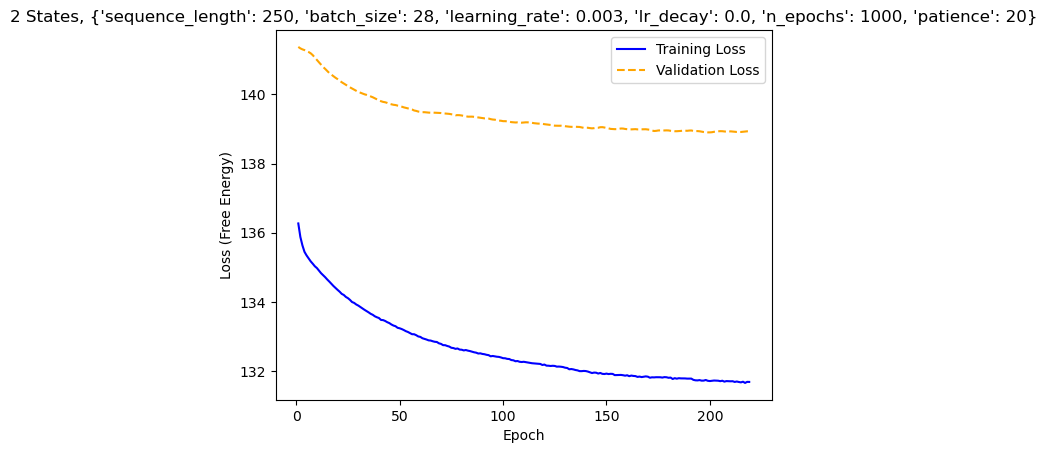

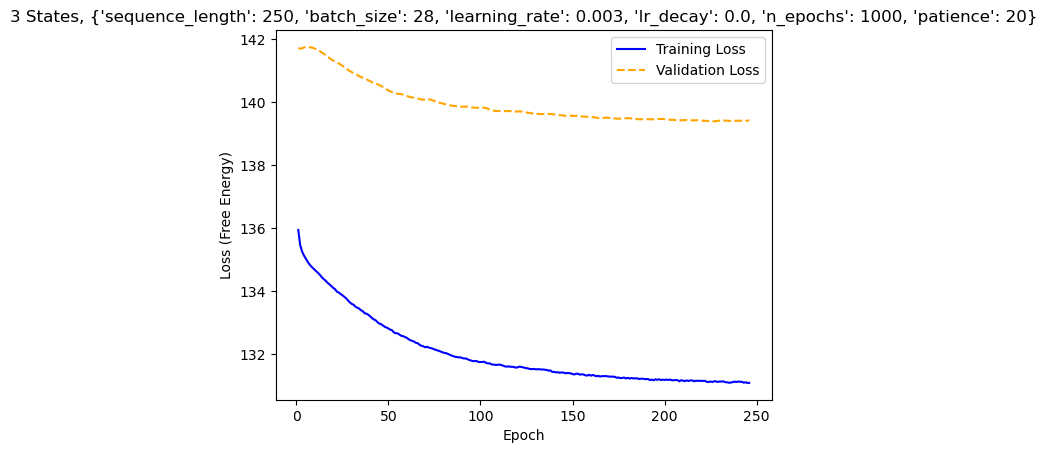

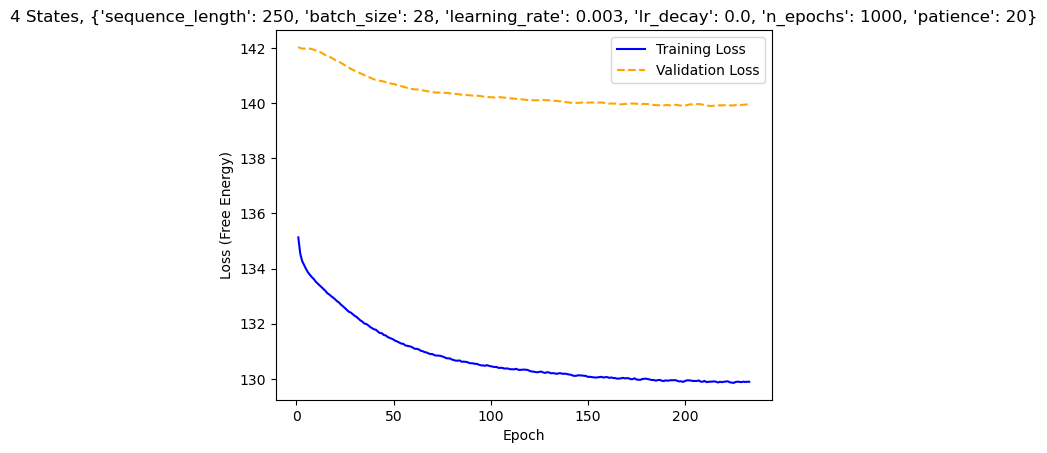

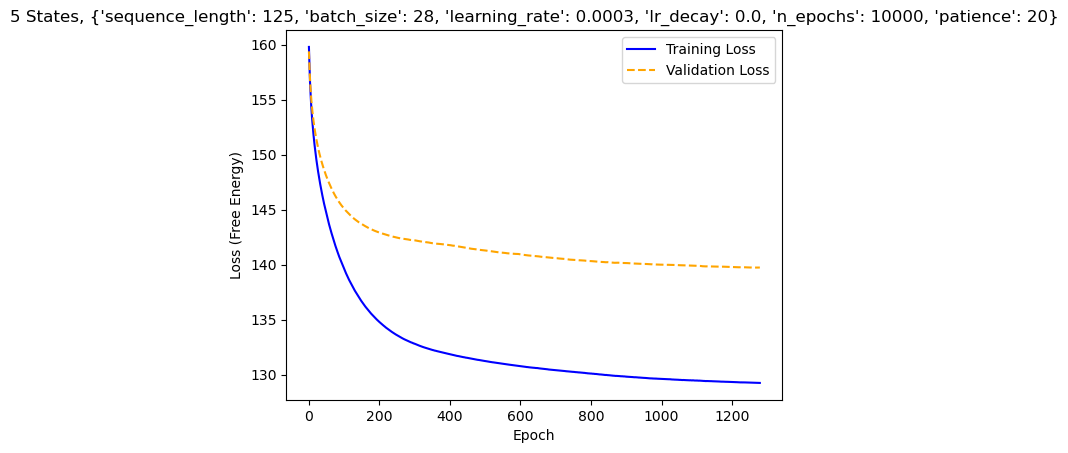

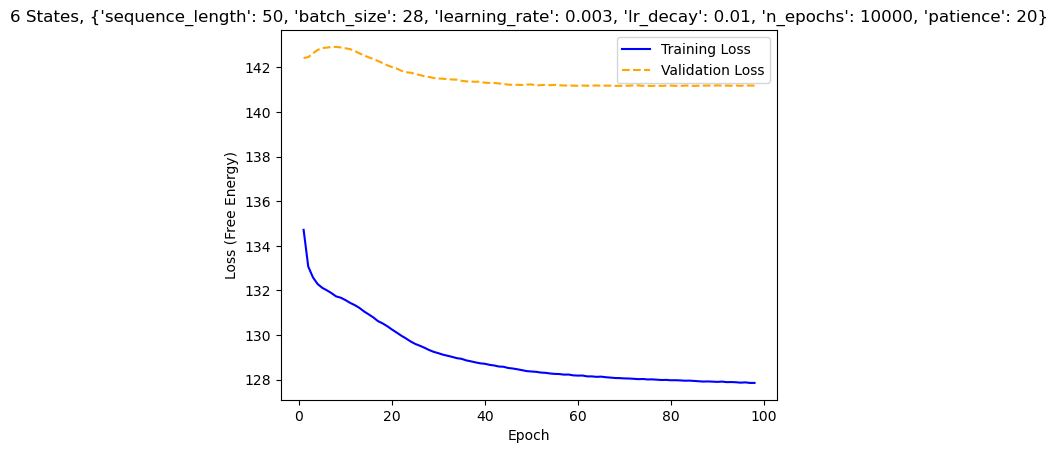

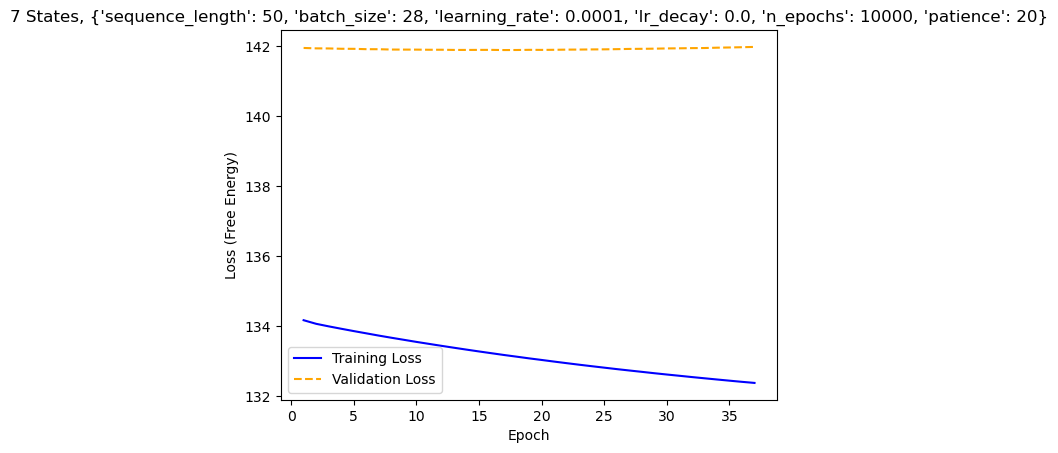

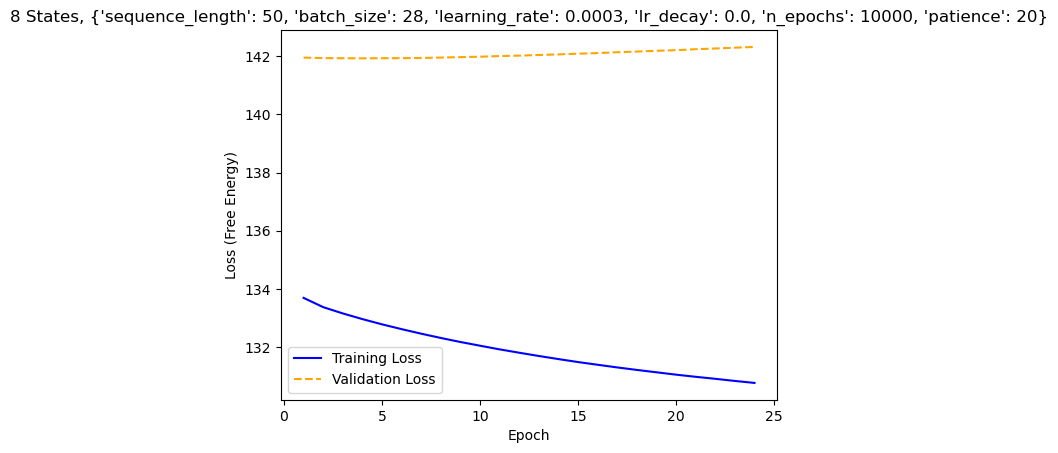

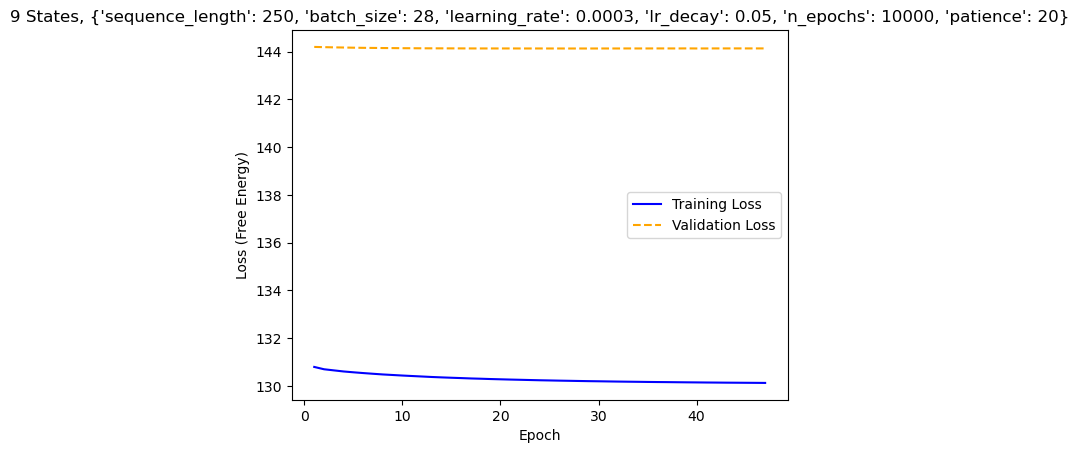

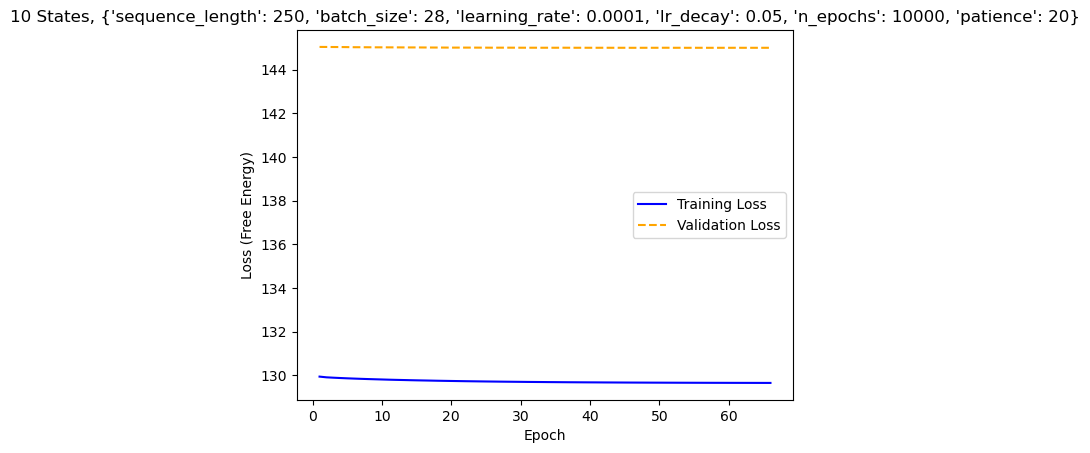

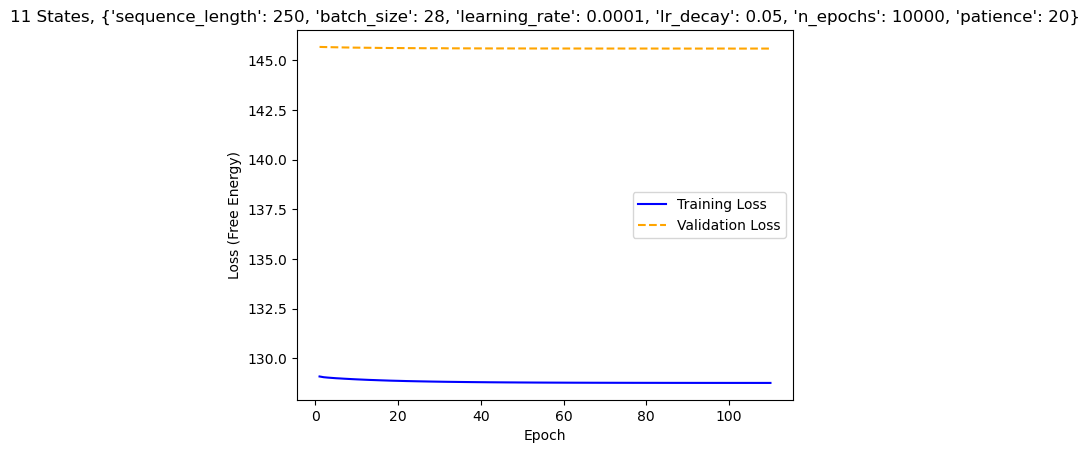

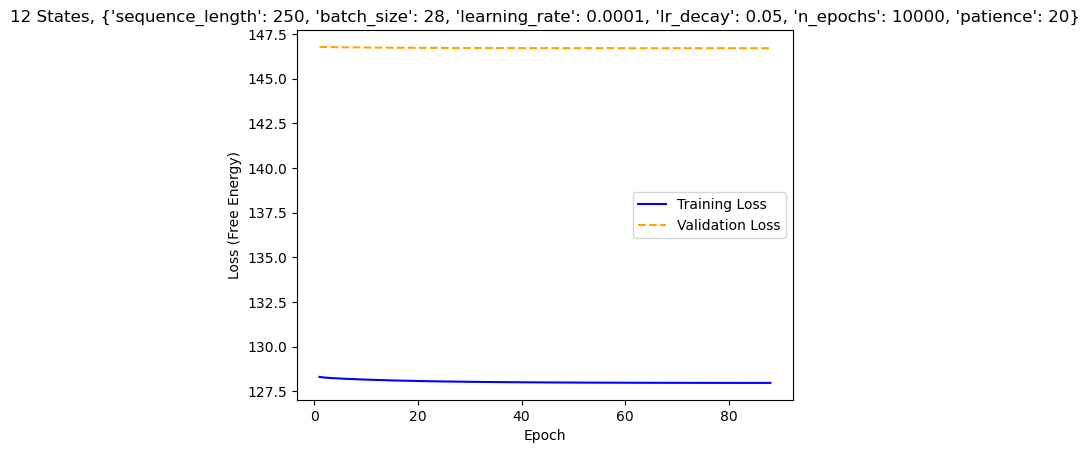

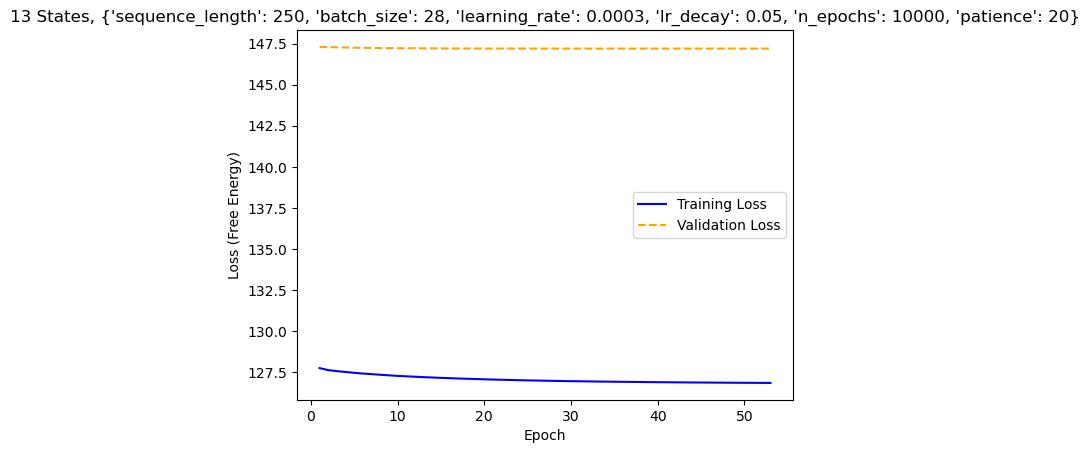

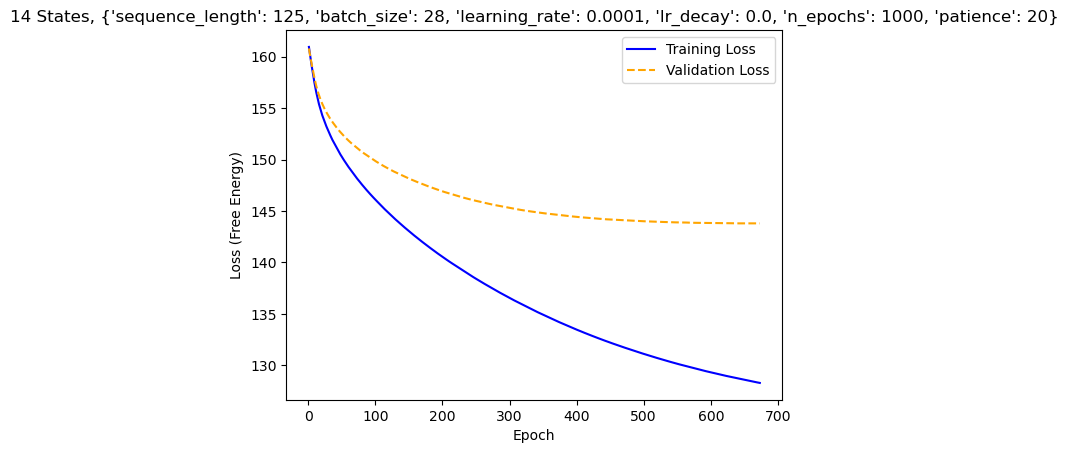

In [18]:
# Sanity check
f_idx = 0
for num_states in sorted_states:
    example = model_eval_log[num_states]['histories'][np.nanargmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(example[f_idx]['loss']) + 1)
    ax.plot(x, example[f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, example[f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(f"{num_states} States, " + str(model_eval_log[num_states]['hyperparams'][np.nanargmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    plt.show()

In [19]:
for num_states in sorted_states:
    print(f"Best params for {num_states} states: {model_eval_log[num_states]['hyperparams'][np.nanargmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]}")

Best params for 2 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.003, 'lr_decay': 0.0, 'n_epochs': 1000, 'patience': 20}
Best params for 3 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.003, 'lr_decay': 0.0, 'n_epochs': 1000, 'patience': 20}
Best params for 4 states: {'sequence_length': 250, 'batch_size': 28, 'learning_rate': 0.003, 'lr_decay': 0.0, 'n_epochs': 1000, 'patience': 20}
Best params for 5 states: {'sequence_length': 125, 'batch_size': 28, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}
Best params for 6 states: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.003, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}
Best params for 7 states: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}
Best params for 8 states: {'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'pa

In [20]:
def hyperparam_performance(num_states):
    for h, t, e in sorted(
        zip(
            model_eval_log[num_states]['hyperparams'], 
            np.mean(model_eval_log[num_states]['test_free_energies'], axis=1), 
            np.mean(model_eval_log[num_states]['best_epochs'], axis=1)
        ), 
        key=lambda x: x[1]
    ):
        print(f"{h}: {t:.3f}, took {e:.1f} epochs on average")

In [21]:
print(hyperparam_performance(8))

{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: 141.461, took 142.8 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: 141.683, took 86.4 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0003, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}: 142.214, took 56.0 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}: 142.487, took 102.8 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.0001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}: 142.692, took 124.0 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_rate': 0.001, 'lr_decay': 0.05, 'n_epochs': 10000, 'patience': 20}: 142.829, took 26.2 epochs on average
{'sequence_length': 50, 'batch_size': 28, 'learning_r

## Compute Model Evaluation Metrics on the Full Dataset for Each Number of States

In [22]:
num_realizations = 10
results_path = f'{experiment}/results/{hmm_run}'
os.makedirs(results_path, exist_ok=True) # don't worry, os.makedirs() never replaces a directory (or parent directory) if it already exists

In [23]:
# Compute full-dataset evaluation metrics
for num_states in [5, 8]: # sorted_states:
    print(f"Fitting model with {num_states} states...")
    if 'realizations' in model_eval_log[num_states] and len(model_eval_log[num_states]['realizations']) < num_realizations:
        del model_eval_log[num_states]['realizations']
        del model_eval_log[num_states]['free_energy']
        del model_eval_log[num_states]['full_LL'] 
        del model_eval_log[num_states]['BIC'] 
        del model_eval_log[num_states]['MMDL'] 
    
    if 'realizations' not in model_eval_log[num_states]:
        model_eval_log[num_states]['realizations'] = []
        realizations = [] # contains model object from each realization. Models can't be pickled, so we will pick the best realization and save the corresponding model object separately
        model_eval_log[num_states]['free_energy'] = []
        model_eval_log[num_states]['full_LL'] = []
        model_eval_log[num_states]['BIC'] = []
        model_eval_log[num_states]['MMDL'] = []
        random.seed(42)
        np.random.seed(42)
        for r in range(num_realizations): # account for variability in .random_state_time_course_initialization(), then average later
            print(f"Realization {r + 1}:")
            model_eval_log[num_states]['realizations'].append({})
            best_hyperparams_idx = np.nanargmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))
            best_hyperparams = model_eval_log[num_states]['hyperparams'][best_hyperparams_idx]
            config = Config(
                n_states=num_states,
                n_channels=full_data.n_channels,
                sequence_length=best_hyperparams['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                # n_init=best_hyperparams['n_init'],
                # n_init_epochs=best_hyperparams['n_init_epochs'],
                batch_size=best_hyperparams['batch_size'],
                learning_rate=best_hyperparams['learning_rate'],
                lr_decay=best_hyperparams['lr_decay'],
                n_epochs=math.ceil(np.mean(model_eval_log[num_states]['best_epochs'][best_hyperparams_idx])),
                loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
            )
    
            model = Model(config)
            try:
                model.random_state_time_course_initialization(full_data, verbose=0)
            except ValueError:
                print("random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.")
                model.random_subset_initialization(full_data, verbose=0)

            history = model.fit(full_data, verbose=0)
            realizations.append(model)
            
            free_energy = model.free_energy(full_data) # note that .free_energy() returns the free energy averaged over batches
            model_eval_log[num_states]['free_energy'].append(free_energy)
    
            _, covs = model.get_means_covariances() # learn_means=False so means will be zero 
            model_eval_log[num_states]['realizations'][r]['covs'] = covs
        
            off_diags = []
            dofs = [] # degrees of freedom of inverse covariance matrices (precision matrices), used to compute MMDL
            for cov in covs:
                ut = np.triu(cov, k=1) # upper triangle, excluding main diagonal
                off_diag = ut[ut != 0] # np.triu() returns a full matrix, so filter out lower triangle entries and flatten to a 1-D array
                off_diags.append(off_diag)
    
                precision_matrix = np.linalg.inv(cov)
                precision_matrix_ut = np.triu(precision_matrix) # upper triangle, incuding main diagonal
                dofs.append(np.sum(precision_matrix_ut != 0)) # "Df(k) is the number of non-zeroes in the precision matrix"
        
            model_eval_log[num_states]['realizations'][r]['off_diags'] = np.array(off_diags).T # (number of upper triangle entries x num_states)
            
            mean_per_timepoint_LL = model.evidence(full_data)
            full_LL = mean_per_timepoint_LL * full_data.n_samples
            model_eval_log[num_states]['full_LL'].append(full_LL)
        
            # Compute Bayesian Information Criterion (BIC)
            d = full_data.n_channels
            k = (num_states - 1) + num_states * (num_states - 1) + num_states * (d * (d + 1)) / 2 # number of estimated parameters, learn_means=False
            BIC = k * np.log(full_data.n_samples) - 2 * full_LL
            model_eval_log[num_states]['BIC'].append(BIC)
    
            # Compute Mixture Minimum Description Length (MMDL) 
            alpha = np.array(model.get_alpha(full_data)) # state probability time courses for each subject (subjects x timepoints x num_states)
            third_term = np.sum([np.log(full_data.n_samples * np.sum(alpha[:, :, state_num])) * dofs[state_num] for state_num in range(num_states)]) / 2
            MMDL = -full_LL + np.log(full_data.n_samples) * num_states * (num_states - 1) / 2 + third_term
            model_eval_log[num_states]['MMDL'].append(MMDL)
        
        model_dir = f'{results_path}/{num_states}_states'
        os.makedirs(model_dir, exist_ok=True)
        best_realization_path = f'{model_dir}/{num_states}_states_model'
        realizations[np.argmin(model_eval_log[num_states]['free_energy'])].save(best_realization_path) # save model object with lowest free energy
        model_eval_log[num_states]['best_realization_path'] = best_realization_path
        with open(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl', 'wb') as f:
            pickle.dump(model_eval_log, f)
    else:
        print(f"The model with {num_states} states has already been evaluated on the full dataset, skipping...")

Fitting model with 5 states...
Realization 1:


E0000 00:00:1777047518.400874 2579220 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777047518.401877 2579220 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.


Getting free energy:   0%|          | 0/9 [00:00<?, ?it/s]

2026-04-24 09:33:17.469445: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Getting alpha:   0%|          | 0/114 [00:00<?, ?it/s]

Realization 10:
random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.


Getting free energy:   0%|          | 0/21 [00:00<?, ?it/s]

Getting evidence:   0%|          | 0/21 [00:00<?, ?it/s]

Getting alpha:   0%|          | 0/114 [00:00<?, ?it/s]

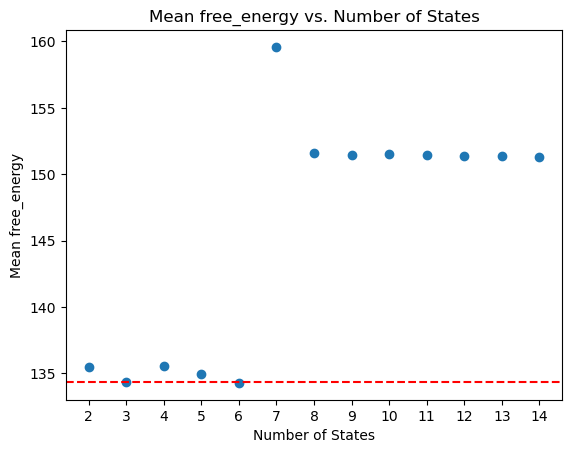

num_states: free_energy
6: 134.2798559624035


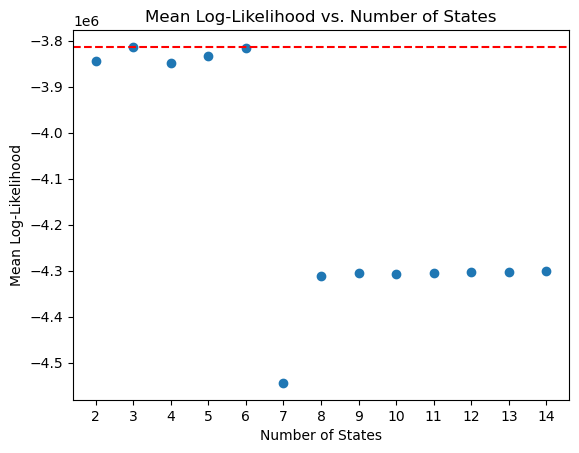

num_states: full_LL
3: -3813609.5


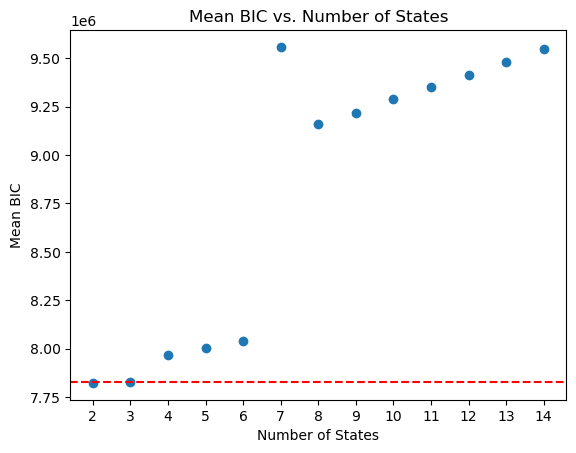

num_states: BIC
2: 7822147.587269723


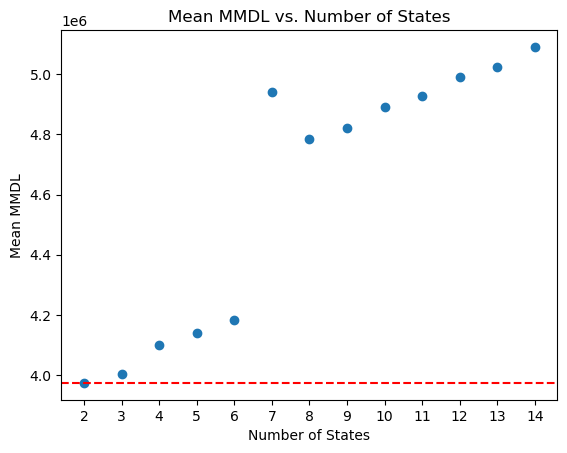

num_states: MMDL
2: 3973599.5904519195


In [22]:
metrics = ['free_energy', 'full_LL', 'BIC', 'MMDL']
max_num_states = 14
for metric in metrics:
    one_se_rule = {}
    
    for key, value in model_eval_log.items():
        if key <= max_num_states:
            one_se_rule[key] = {
                'mean': np.mean(value[metric]),
                'se': np.std(value[metric], ddof=1) / np.sqrt(num_realizations),
            }

    sorted_by_mean = sorted(list(one_se_rule.items()), key=lambda x: x[1]['mean'])
    
    fig, ax = plt.subplots(1, 1)
    num_states_list = [x[0] for x in sorted_by_mean]
    means = [x[1]['mean'] for x in sorted_by_mean]
    ax.scatter(num_states_list, means)
    if metric == 'full_LL':
        ax.axhline(y=sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se'], color='r', linestyle='--')
        ax.set_xticks(range(min(model_eval_log), max_num_states + 1))
        ax.set_title("Mean Log-Likelihood vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel("Mean Log-Likelihood")
        plt.show()

        print(f"num_states: {metric}")
        for num_states in num_states_list:
            if np.mean(model_eval_log[num_states][metric]) >= sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se']:
                print(f"{num_states}: {np.mean(model_eval_log[num_states][metric])}")
    else:
        ax.axhline(y=sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se'], color='r', linestyle='--')
        ax.set_xticks(range(min(model_eval_log), max_num_states + 1))
        ax.set_title(f"Mean {metric} vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel(f"Mean {metric}")
        plt.show()

        print(f"num_states: {metric}")
        for num_states in num_states_list:
            if np.mean(model_eval_log[num_states][metric]) <= sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se']:
                print(f"{num_states}: {np.mean(model_eval_log[num_states][metric])}")

In [58]:
def realization_corr(r1, r2):
    r1_stan = (r1 - np.mean(r1, axis=0, keepdims=True)) / np.std(r1, axis=0, keepdims=True)
    r2_stan = (r2 - np.mean(r2, axis=0, keepdims=True)) / np.std(r2, axis=0, keepdims=True)

    return r1_stan.T @ r2_stan / (r1_stan.shape[0] - 1) # (num_states x num_states)


Aligned States for n_states=5:

Aligned State 1:
Realization 1, state 5
Realization 2, state 1
Realization 3, state 3
Realization 4, state 3
Realization 5, state 1
Realization 6, state 2
Realization 7, state 4
Realization 8, state 1
Realization 9, state 2
Realization 10, state 5
Average between-realization correlation: 0.9995262393163233

Aligned State 2:
Realization 1, state 2
Realization 2, state 2
Realization 3, state 4
Realization 4, state 2
Realization 5, state 4
Realization 6, state 1
Realization 7, state 3
Realization 8, state 5
Realization 9, state 3
Realization 10, state 2
Average between-realization correlation: 0.979739346433052

Aligned State 3:
Realization 1, state 3
Realization 2, state 5
Realization 3, state 1
Realization 4, state 5
Realization 5, state 2
Realization 6, state 3
Realization 7, state 1
Realization 8, state 2
Realization 9, state 5
Realization 10, state 1
Average between-realization correlation: 0.9119808982555562

Aligned State 4:
Realization 1, state 1
R

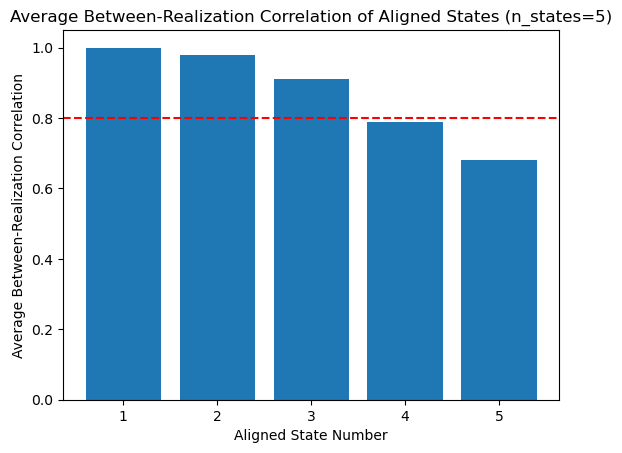


Aligned States for n_states=6:

Aligned State 1:
Realization 1, state 2
Realization 2, state 6
Realization 3, state 4
Realization 4, state 5
Realization 5, state 3
Realization 6, state 3
Realization 7, state 6
Realization 8, state 6
Realization 9, state 2
Realization 10, state 5
Average between-realization correlation: 0.9996245411588979

Aligned State 2:
Realization 1, state 6
Realization 2, state 4
Realization 3, state 1
Realization 4, state 6
Realization 5, state 5
Realization 6, state 5
Realization 7, state 4
Realization 8, state 2
Realization 9, state 4
Realization 10, state 3
Average between-realization correlation: 0.9687705331399751

Aligned State 3:
Realization 1, state 5
Realization 2, state 2
Realization 3, state 3
Realization 4, state 2
Realization 5, state 1
Realization 6, state 1
Realization 7, state 5
Realization 8, state 3
Realization 9, state 3
Realization 10, state 4
Average between-realization correlation: 0.9319820893563288

Aligned State 4:
Realization 1, state 4


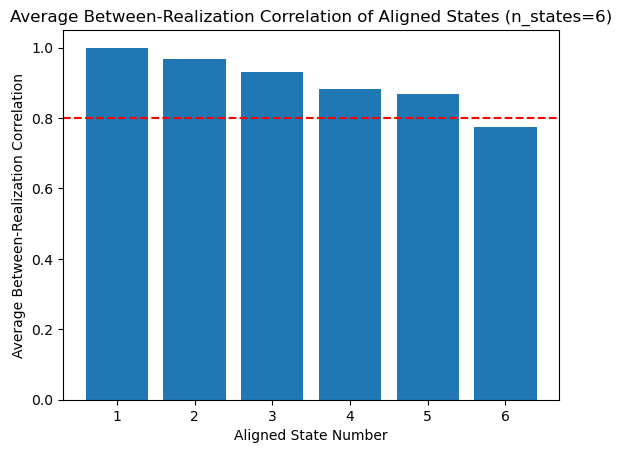


Aligned States for n_states=7:

Aligned State 1:
Realization 1, state 4
Realization 2, state 7
Realization 3, state 5
Realization 4, state 7
Realization 5, state 2
Realization 6, state 2
Realization 7, state 1
Realization 8, state 7
Realization 9, state 2
Realization 10, state 6
Average between-realization correlation: 0.9854745204351673

Aligned State 2:
Realization 1, state 6
Realization 2, state 3
Realization 3, state 7
Realization 4, state 2
Realization 5, state 7
Realization 6, state 6
Realization 7, state 7
Realization 8, state 3
Realization 9, state 4
Realization 10, state 3
Average between-realization correlation: 0.9358995384464095

Aligned State 3:
Realization 1, state 1
Realization 2, state 1
Realization 3, state 3
Realization 4, state 4
Realization 5, state 6
Realization 6, state 7
Realization 7, state 6
Realization 8, state 5
Realization 9, state 7
Realization 10, state 5
Average between-realization correlation: 0.7711763311555913

Aligned State 4:
Realization 1, state 7


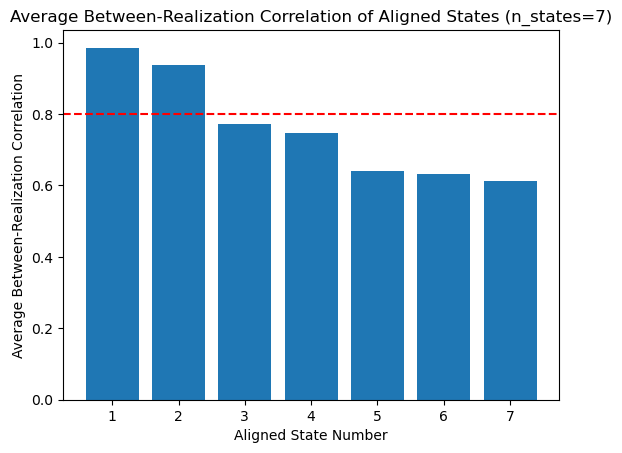


Aligned States for n_states=8:

Aligned State 1:
Realization 1, state 2
Realization 2, state 5
Realization 3, state 4
Realization 4, state 5
Realization 5, state 7
Realization 6, state 6
Realization 7, state 2
Realization 8, state 3
Realization 9, state 7
Realization 10, state 5
Average between-realization correlation: 0.995962939039951

Aligned State 2:
Realization 1, state 6
Realization 2, state 1
Realization 3, state 2
Realization 4, state 3
Realization 5, state 8
Realization 6, state 2
Realization 7, state 4
Realization 8, state 8
Realization 9, state 3
Realization 10, state 1
Average between-realization correlation: 0.950364623099441

Aligned State 3:
Realization 1, state 3
Realization 2, state 6
Realization 3, state 8
Realization 4, state 4
Realization 5, state 5
Realization 6, state 1
Realization 7, state 7
Realization 8, state 6
Realization 9, state 6
Realization 10, state 6
Average between-realization correlation: 0.8864530884273067

Aligned State 4:
Realization 1, state 4
Re

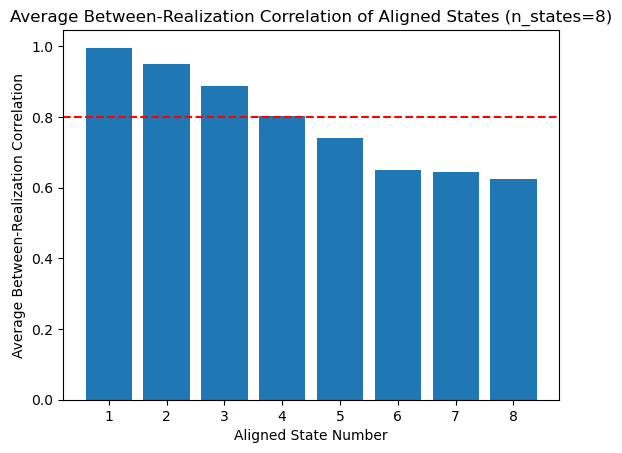

In [59]:
for num_states in [5, 6, 7, 8]: # sorted_states:
    CRCM = np.zeros(shape=(num_states * num_realizations, num_states * num_realizations)) # cross-realization correlation matrix (CRCM)
    for i in range(num_realizations):
        for j in range(num_realizations):
            if i != j:
                CRCM[i * num_states:(i * num_states) + num_states, j * num_states:(j * num_states) + num_states] = abs(realization_corr(
                    model_eval_log[num_states]['realizations'][i]['off_diags'], 
                    model_eval_log[num_states]['realizations'][j]['off_diags']
                ))

    state_groups = [] # [(realization number, state number), ...] using 1-based indexing for realization and state numbers for interpretability
    while np.max(CRCM) > 0:
        state_groups.append([])
        m, n = np.unravel_index(np.argmax(CRCM), shape=CRCM.shape)
        state_groups[-1].append((int(m // num_states + 1), int(m % num_states + 1)))
        state_groups[-1].append((int(n // num_states + 1), int(n % num_states + 1)))
        for i in range(num_realizations):
            if i != m // num_states and i != n // num_states:
                p_i = i * num_states + np.argmax(CRCM[m, i * num_states:(i * num_states) + num_states])
                q_i = i * num_states + np.argmax(CRCM[i * num_states:(i * num_states) + num_states, n])
                if p_i == q_i or CRCM[m, p_i] > CRCM[q_i, n]:
                    state_groups[-1].append((i + 1, int(p_i % num_states + 1)))
                    CRCM[:, p_i] = 0
                    CRCM[p_i, :] = 0
                else:
                    state_groups[-1].append((i + 1, int(q_i % num_states + 1)))
                    CRCM[q_i, :] = 0
                    CRCM[:, q_i] = 0
    
        CRCM[m, :] = 0
        CRCM[:, m] = 0
        CRCM[:, n] = 0
        CRCM[n, :] = 0

    within_group_avg_corrs = []
    for g in range(len(state_groups)):
        off_diags = []
        within_group_corrs = []
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            off_diags.append(model_eval_log[num_states]['realizations'][r - 1]['off_diags'][:, s - 1]) # r and s use 1-based indexing, so must subtract 1
            
        for i in range(len(off_diags)):
            for j in range(i + 1, len(off_diags)):
                within_group_corrs.append(np.corrcoef(off_diags[i], off_diags[j]))
    
        within_group_avg_corr = np.mean(within_group_corrs)
        within_group_avg_corrs.append(within_group_avg_corr)

    idx_seq = []
    for i, corr in sorted(enumerate(within_group_avg_corrs), key=lambda x: x[1], reverse=True):
        idx_seq.append(i)

    # Reorder state_groups and within_group_avg_corrs in order of decreasing average between-realization correlation
    state_groups = [state_groups[i] for i in idx_seq]
    within_group_avg_corrs = [within_group_avg_corrs[i] for i in idx_seq]
    print(f"\nAligned States for n_states={num_states}:")
    for g in range(len(state_groups)):
        print(f"\nAligned State {g + 1}:")
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            print(f"Realization {r}, state {s}")
    
        print(f"Average between-realization correlation: {within_group_avg_corrs[g]}")

    plt.bar(
        [str(i) for i in range(1, len(state_groups) + 1)],
        within_group_avg_corrs,
    )
    plt.axhline(y=0.8, color='r', linestyle='--') # stability threshold
    
    plt.title(f"Average Between-Realization Correlation of Aligned States (n_states={num_states})")
    plt.xlabel("Aligned State Number")
    plt.ylabel("Average Between-Realization Correlation")
    plt.show()

# Fit Best Model and Compute Summary Statistics

In [88]:
optimal_num_states = 7
model = load(model_eval_log[optimal_num_states]['best_realization_path'])

In [89]:
inf_params_path = f'{results_path}/{optimal_num_states}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [90]:
alpha_path = f'{inf_params_path}/alp_{optimal_num_states}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

In [91]:
# We first work with the dual-estimated means and covs
dual_estimates_path = f'{results_path}/{optimal_num_states}_states/dual_estimates'
if os.path.exists(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy') and os.path.exists(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy'):
    means, covs = np.load(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy'), np.load(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy')
else:  
    means, covs = model.dual_estimation(full_data, alpha=alpha)
    os.makedirs(dual_estimates_path, exist_ok=True) 
    np.save(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy', means)
    np.save(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy', covs)

print(means.shape)
print(covs.shape)

(114, 7, 114)
(114, 7, 114, 114)


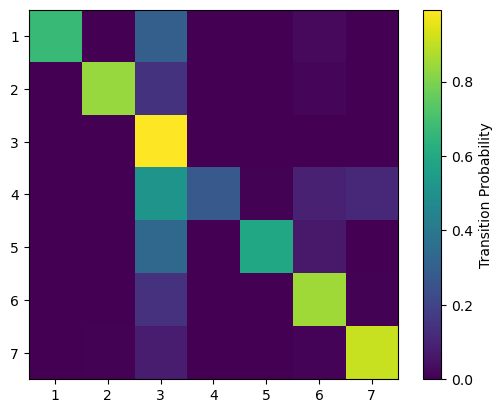

In [92]:
trans_matrix = model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.yticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [93]:
# Now the group-level means and covs
means, covs = model.get_means_covariances()
means.shape, covs.shape

((7, 114), (7, 114, 114))

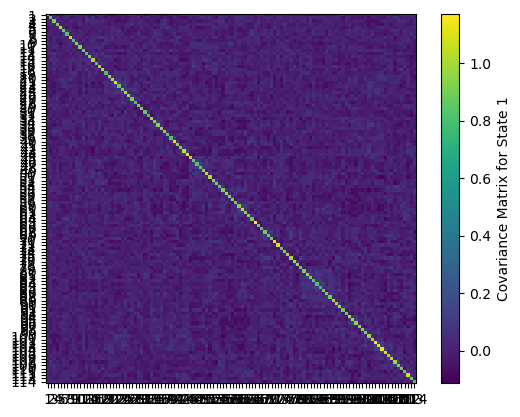

In [94]:
plt.imshow(covs[0], origin='upper')
plt.xticks(ticks=range(0, full_data.n_channels), labels=range(1, full_data.n_channels + 1))
plt.yticks(ticks=range(0, full_data.n_channels), labels=range(1, full_data.n_channels + 1))
plt.colorbar(label='Covariance Matrix for State 1')
plt.show()

In [95]:
np.save(f"{inf_params_path}/means_{optimal_num_states}_states.npy", means)
np.save(f"{inf_params_path}/covs_{optimal_num_states}_states.npy", covs)

In [96]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 114)

In [97]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = modes.argmax_time_courses(alpha) # state time course
print(type(stc))
print(len(stc))
print(stc[0].shape)

<class 'list'>
114
(250, 7)


In [98]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(114, 7)

In [99]:
# FO of each state averaged across subjects
sorted_fos = [] # (state_num, FO)
mean_fos = np.mean(fo, axis=0)
for i in range(optimal_num_states):
    sorted_fos.append((i + 1, mean_fos[i]))

sorted_fos.sort(key=lambda x: x[1], reverse=True)
for state, f in sorted_fos:
    print(f"State {state} FO:", f)

State 2 FO: 0.7211228070175442
State 7 FO: 0.10957894736842097
State 5 FO: 0.09733333333333327
State 3 FO: 0.05631578947368421
State 6 FO: 0.012280701754385968
State 1 FO: 0.002
State 4 FO: 0.0013684210526315789


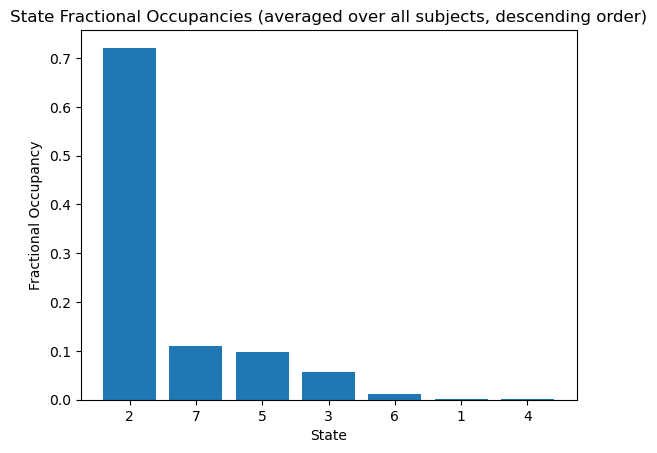

In [100]:
plt.bar(x=[str(x[0]) for x in sorted_fos], height=[x[1] for x in sorted_fos])
plt.title("State Fractional Occupancies (averaged over all subjects, descending order)")
plt.xlabel("State")
plt.ylabel("Fractional Occupancy")
plt.show()

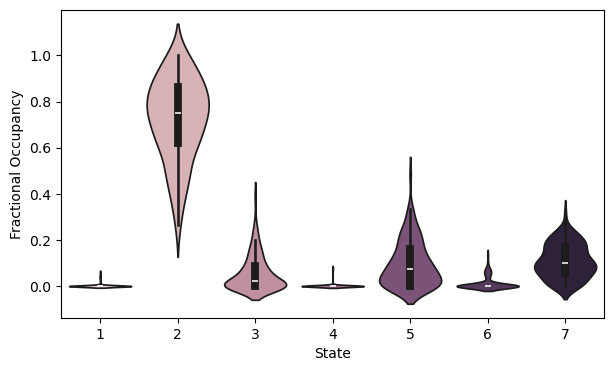

In [101]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

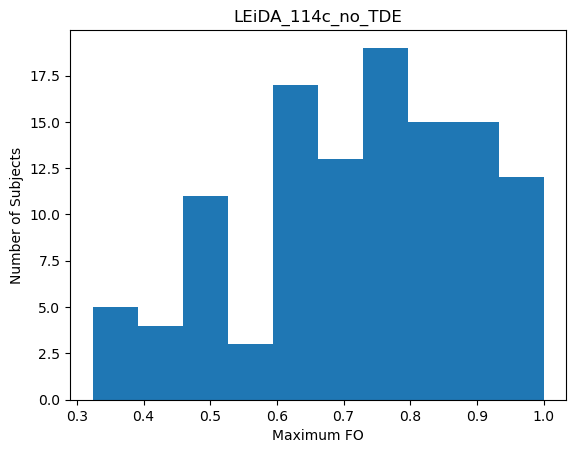

In [102]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(hmm_run)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [103]:
# Mean maxFOs for each experimental group
for group in np.unique(y):
    print(f"{group}:", np.mean(np.max(fo[np.where(y == group)[0],], axis=1)))

CCI_CIMT_07d: 0.8157333333333333
CCI_CIMT_21d: 0.6679999999999999
CCI_CIMT_49d: 0.6880000000000002
CCI_none_07d: 0.8160000000000001
CCI_none_21d: 0.6061333333333334
CCI_none_49d: 0.7858666666666667
SHM_none_07d: 0.782
SHM_none_21d: 0.548
SHM_none_49d: 0.777


In [104]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

CCI_CIMT_07d_001
CCI_CIMT_07d_004
CCI_CIMT_07d_040
CCI_CIMT_21d_007
CCI_CIMT_49d_038
CCI_none_07d_002
CCI_none_07d_029
CCI_none_07d_030
CCI_none_07d_031
CCI_none_21d_009
CCI_none_49d_025
CCI_none_49d_030
CCI_none_49d_031
SHM_none_07d_015
SHM_none_07d_028
SHM_none_07d_034
SHM_none_49d_014
SHM_none_49d_028


18

## Subject-Level State Time Courses (Viterbi Paths)

In [105]:
stim_times = ([0] * 15 + [1] * 10) * 10
len(stim_times)

250

In [106]:
def add_stim_times(ax):
    for i in range(len(stim_times)):
        if stim_times[i]:
            ax.plot(i, 0, color='black', marker='o')

### 07d

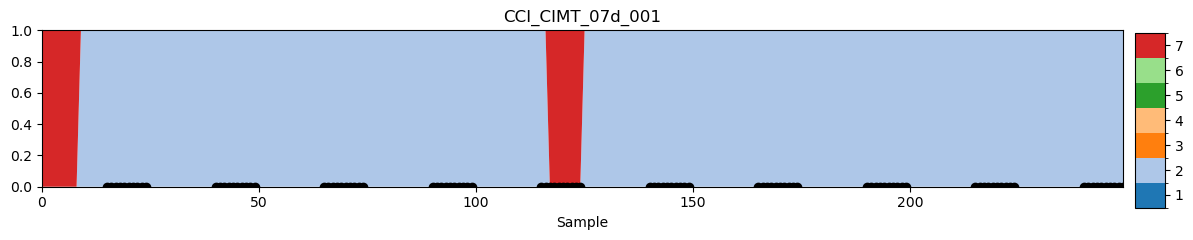

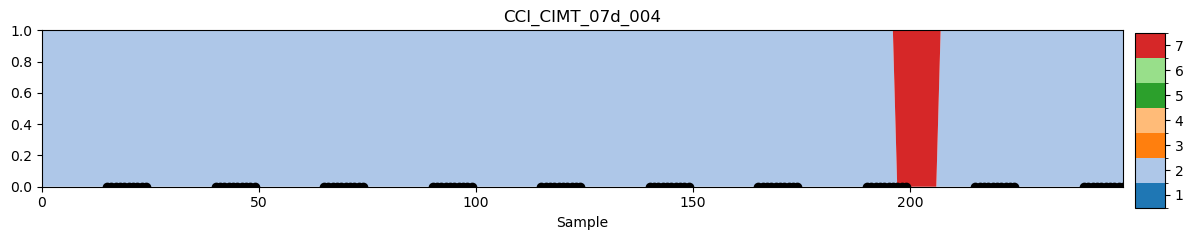

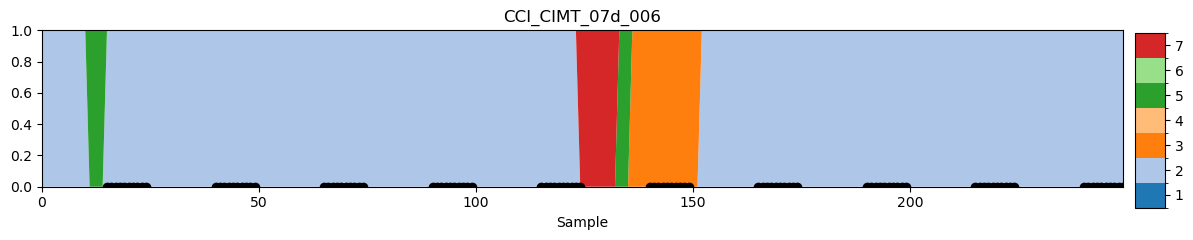

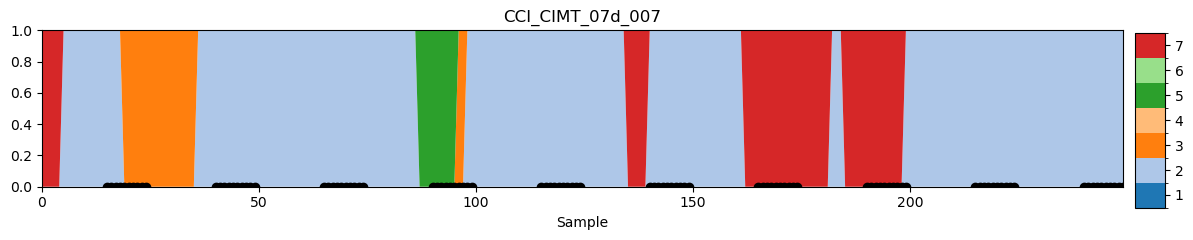

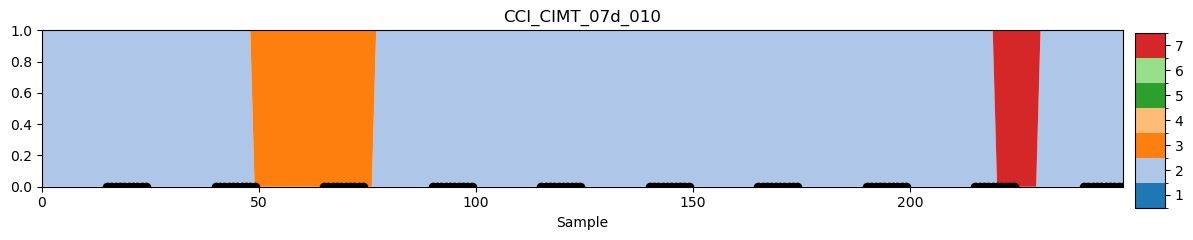

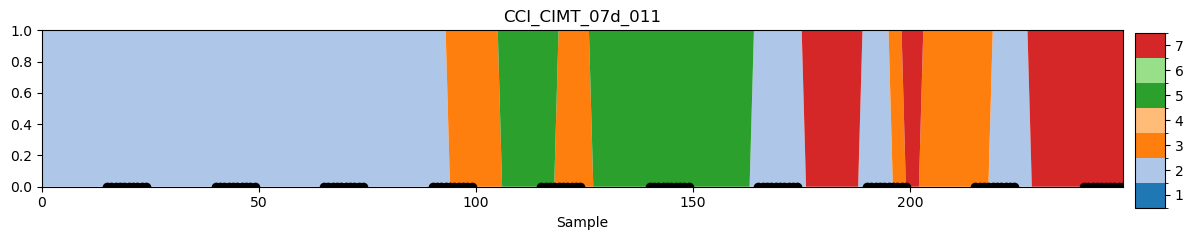

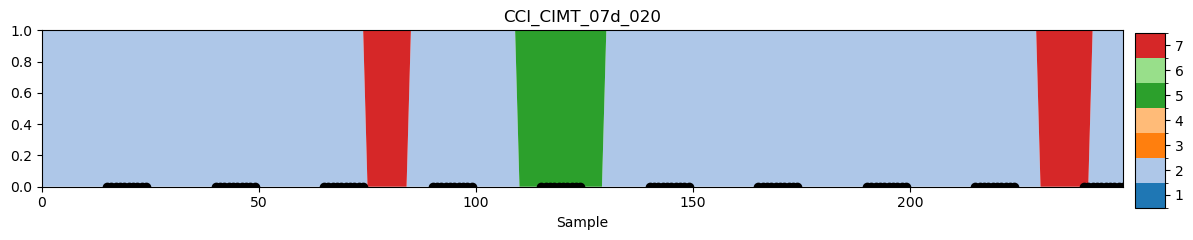

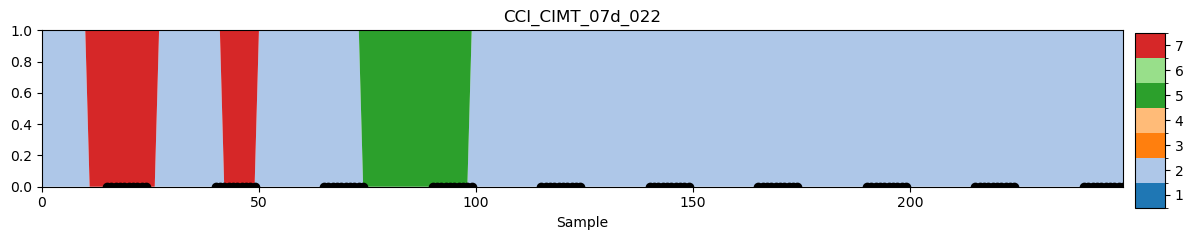

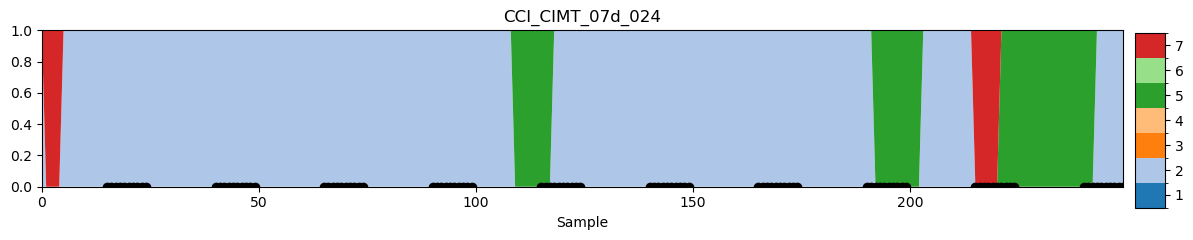

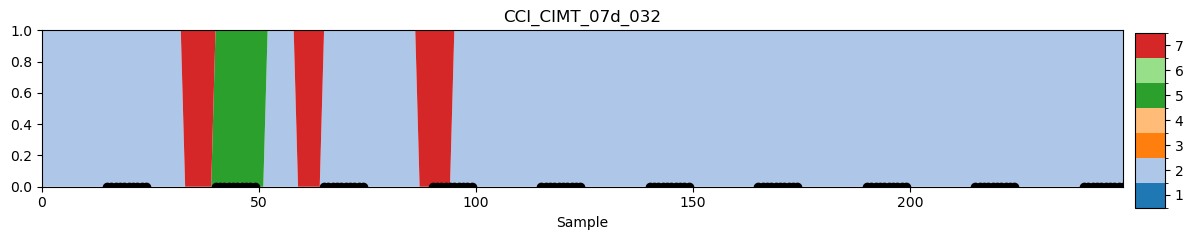

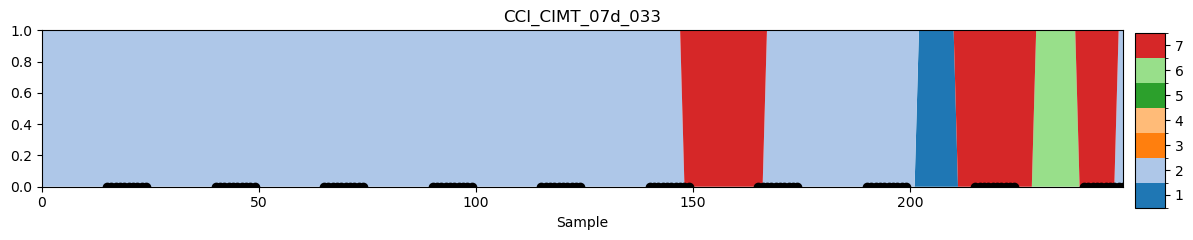

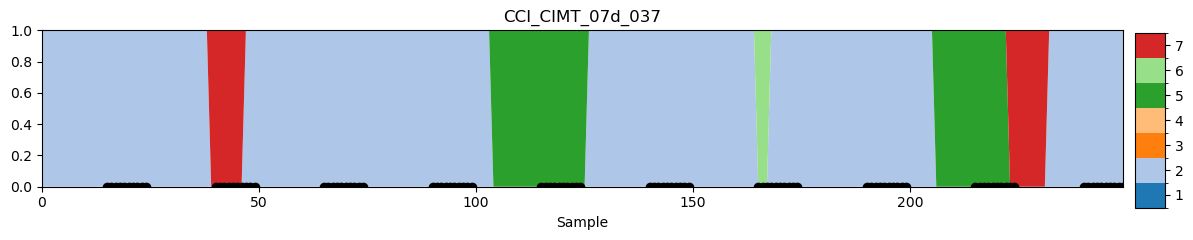

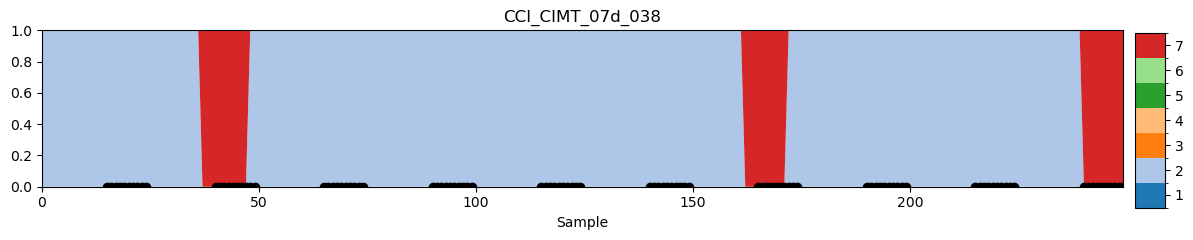

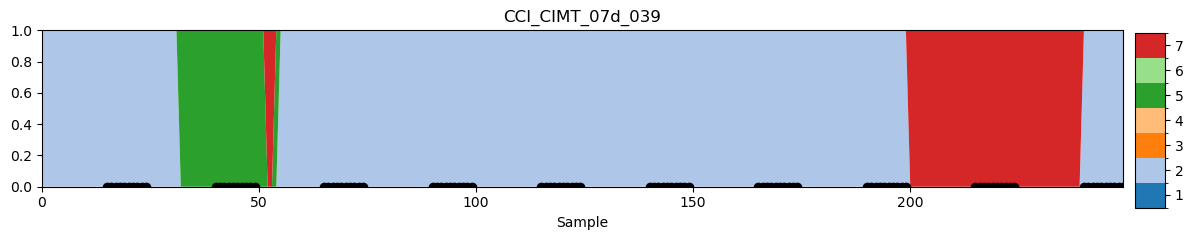

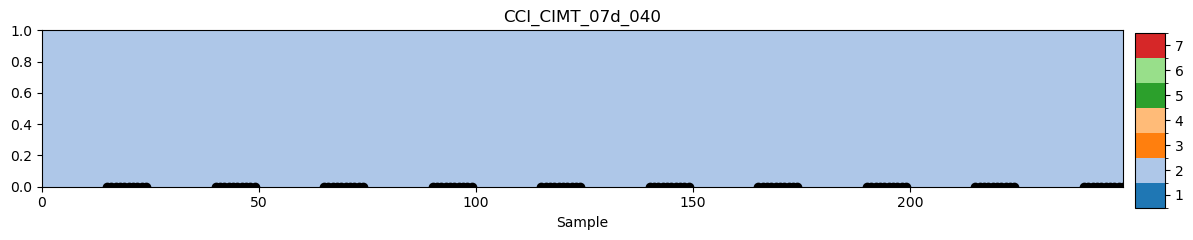

In [107]:
# CCI_CIMT_07d
for subj in np.where(y == 'CCI_CIMT_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

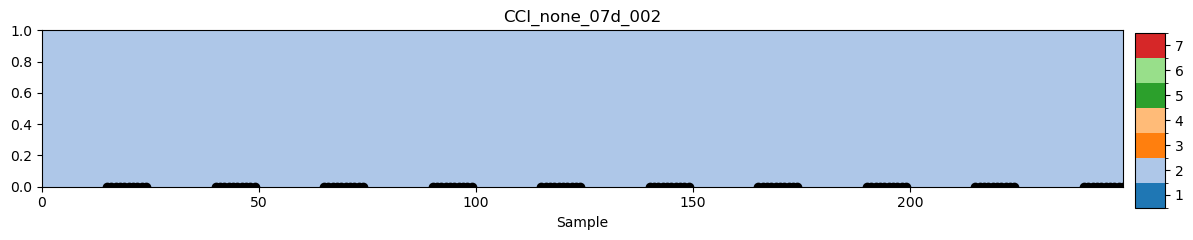

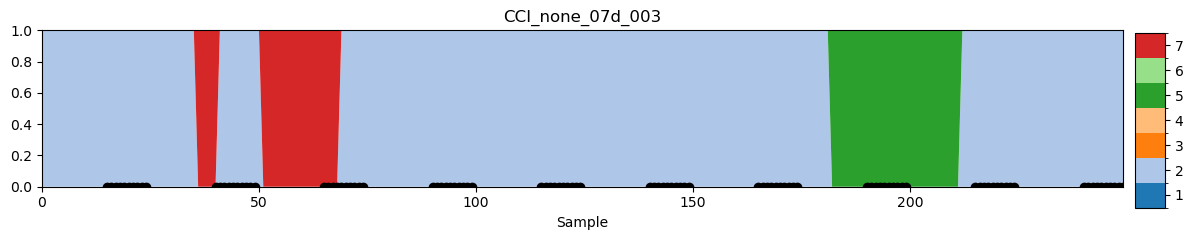

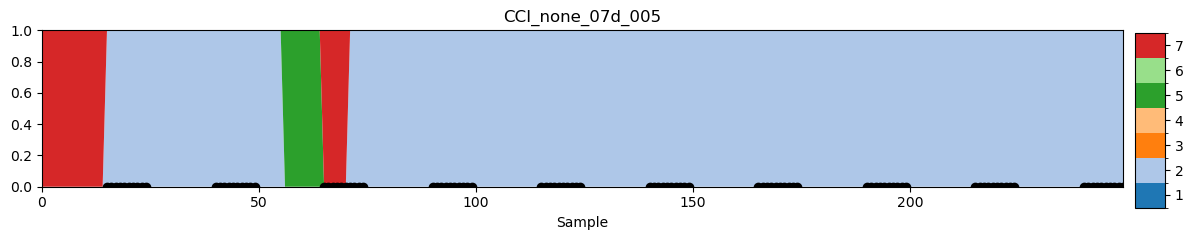

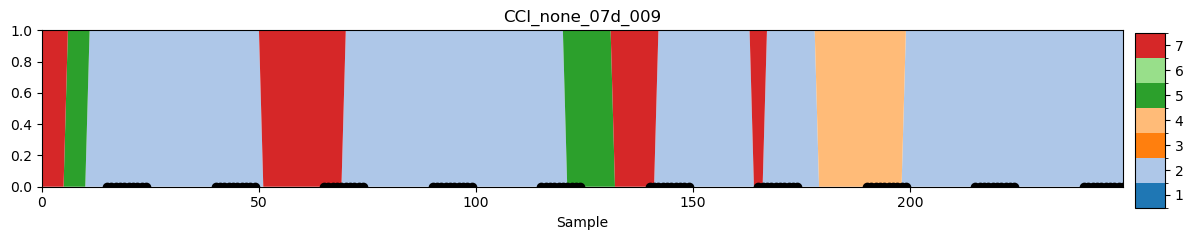

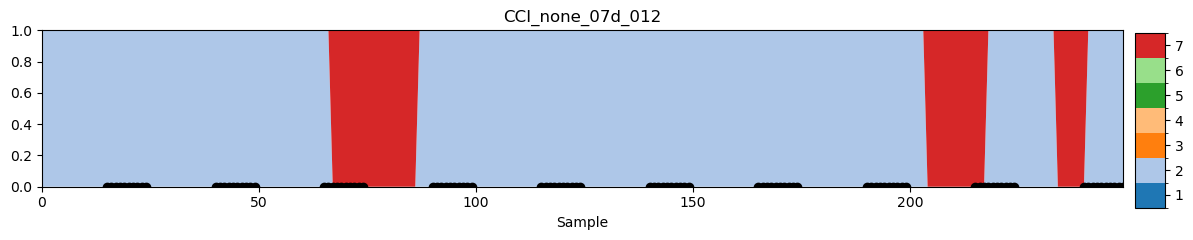

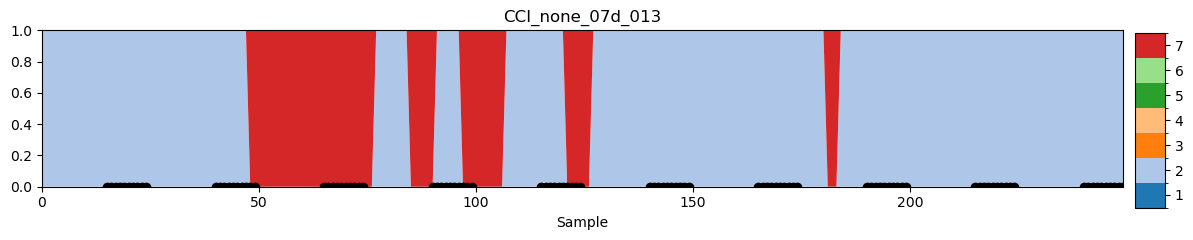

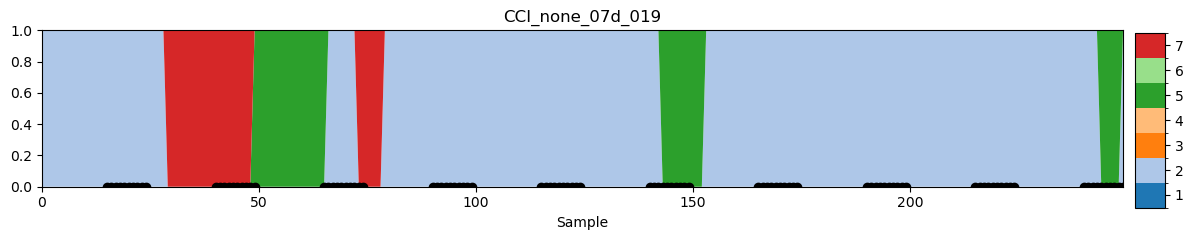

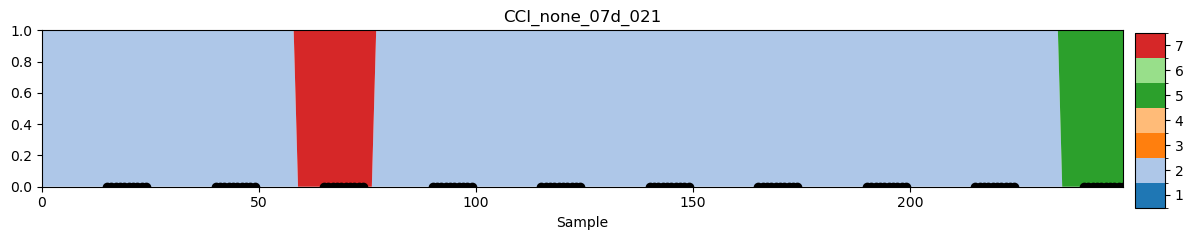

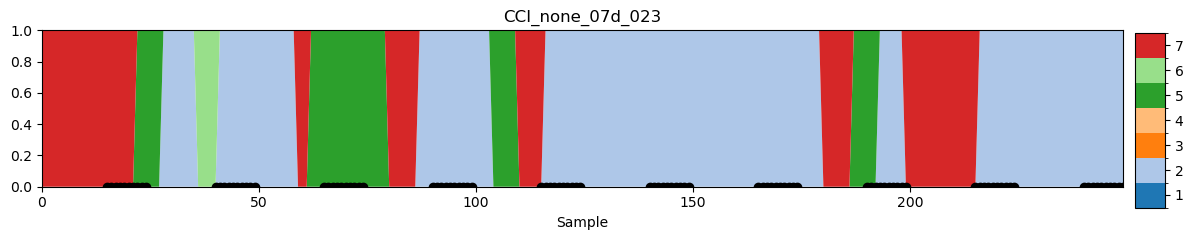

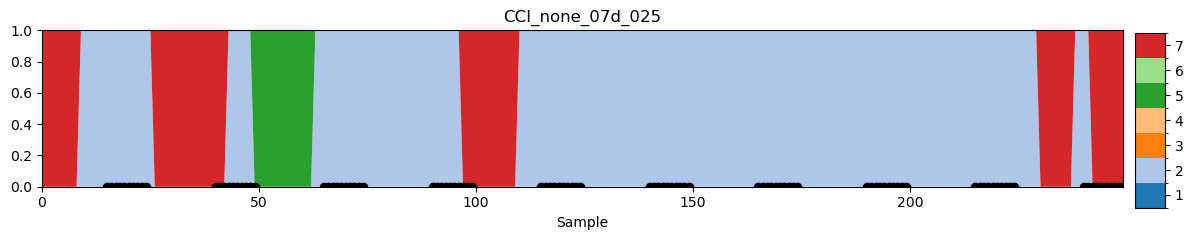

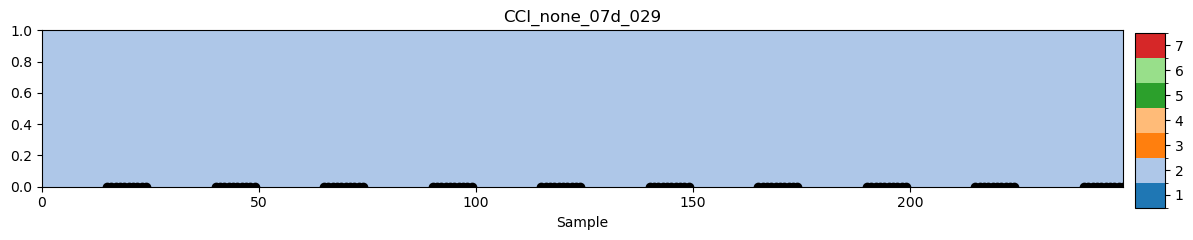

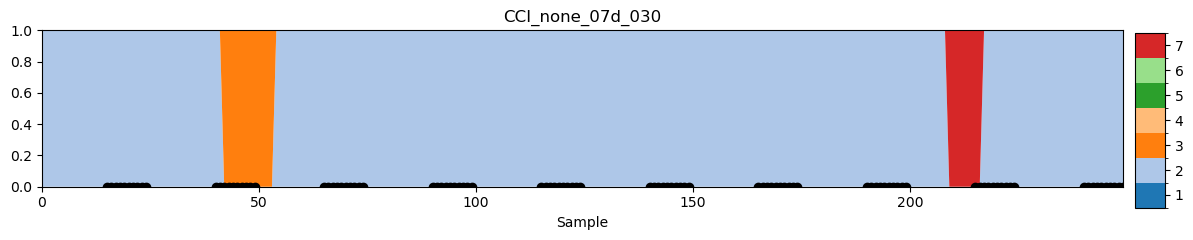

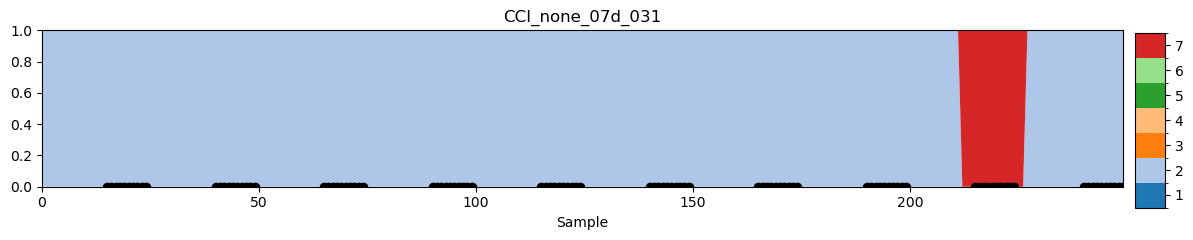

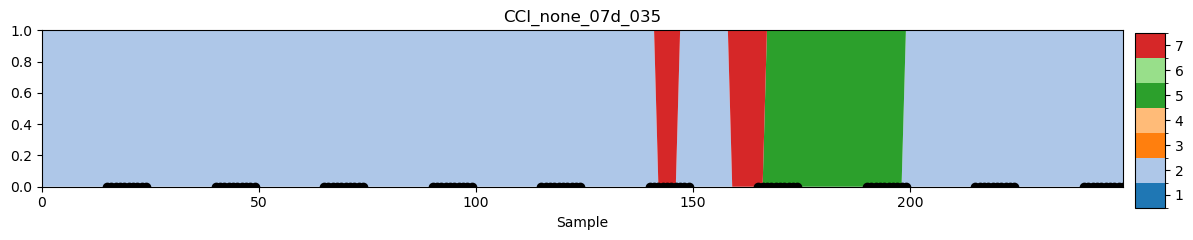

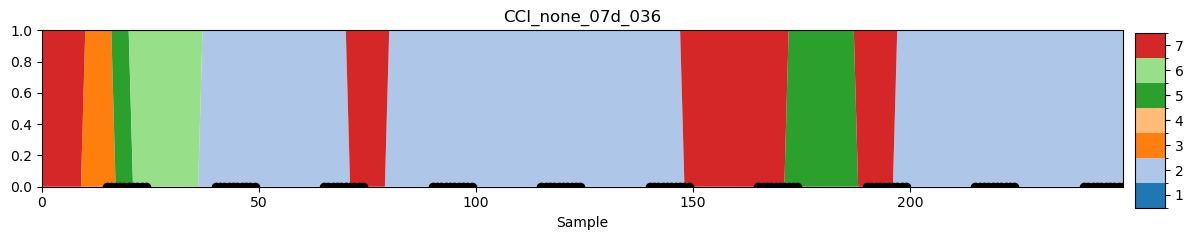

In [108]:
# CCI_none_07d
for subj in np.where(y == 'CCI_none_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

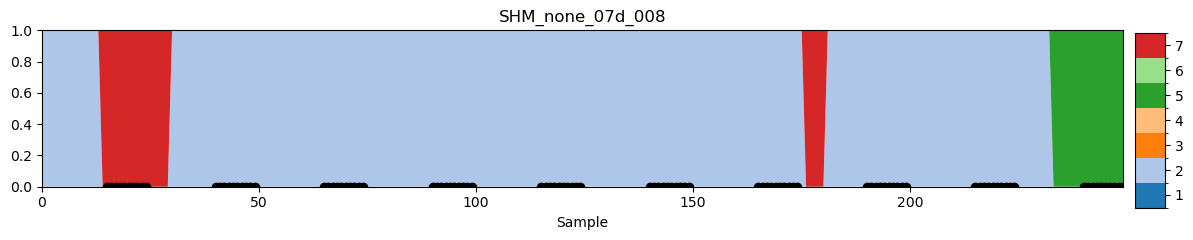

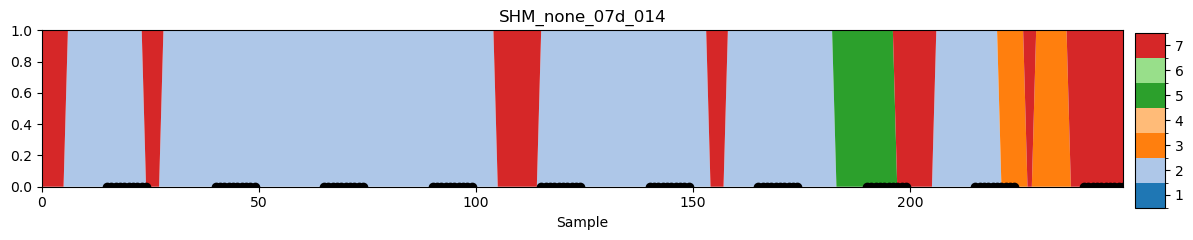

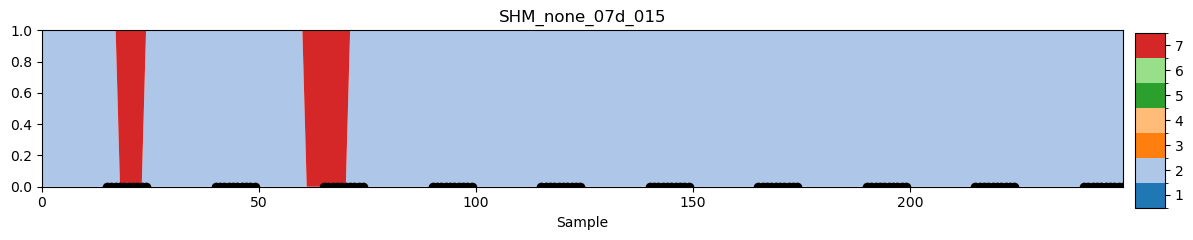

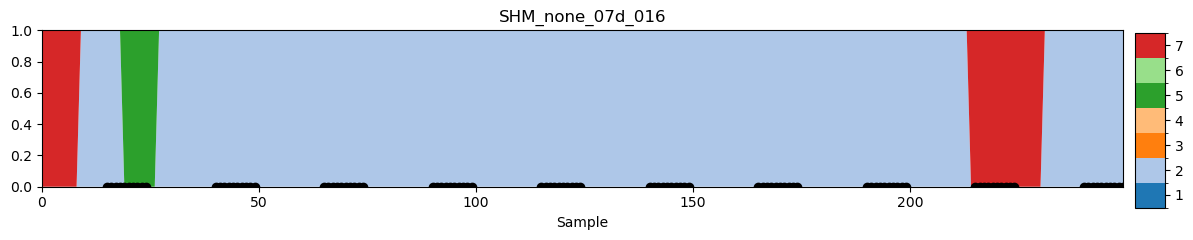

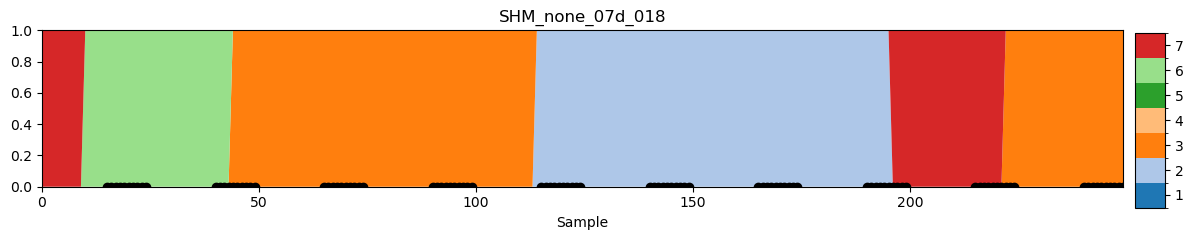

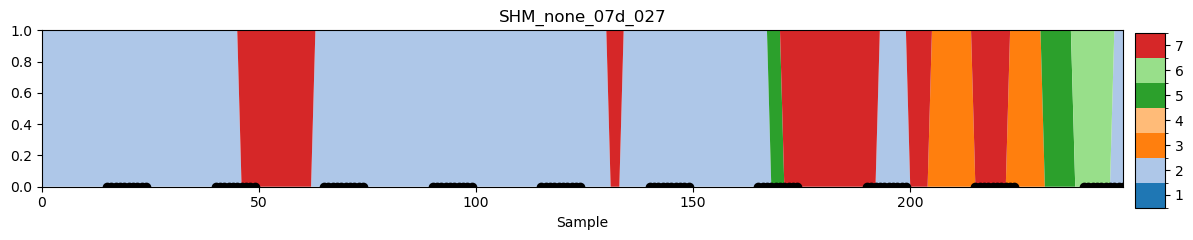

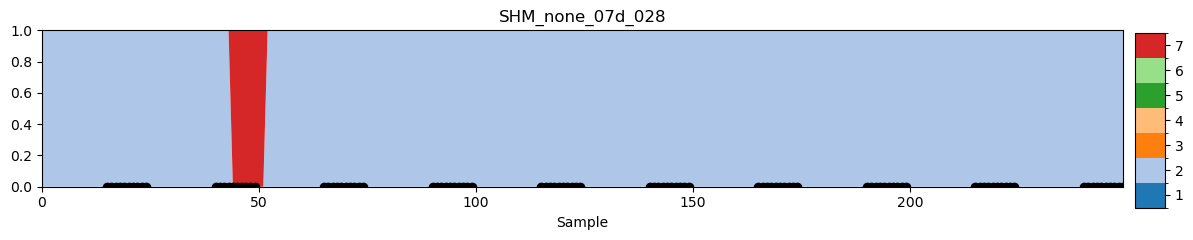

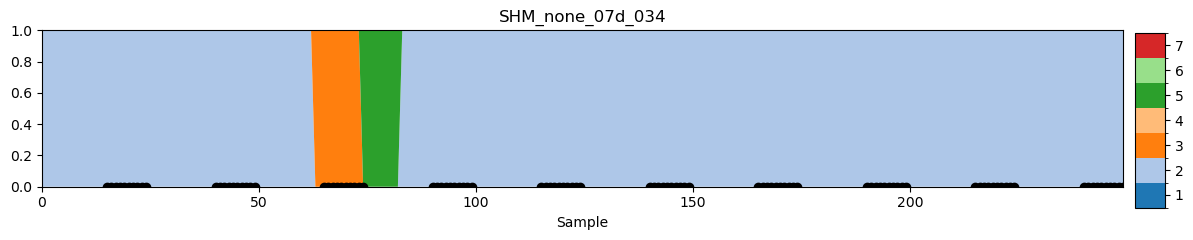

In [109]:
# SHM_none_07d
for subj in np.where(y == 'SHM_none_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

### 21d

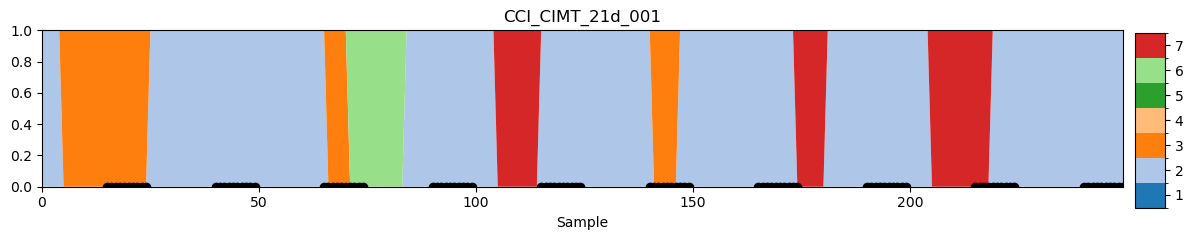

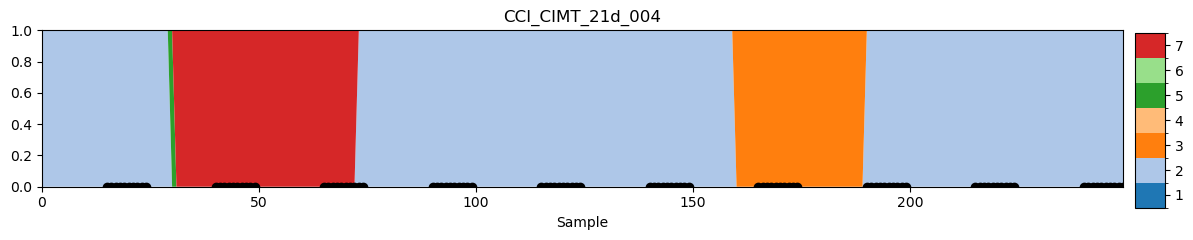

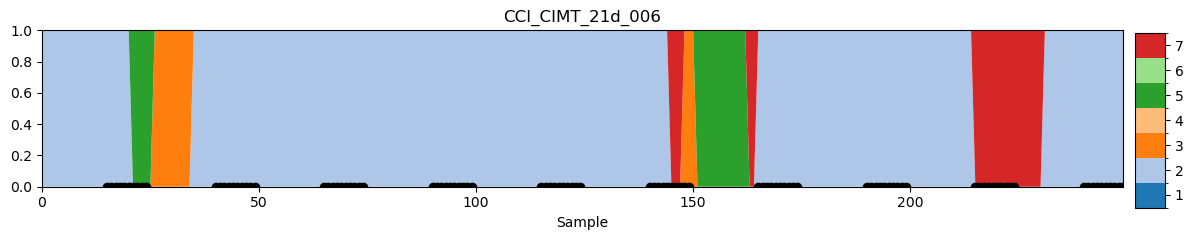

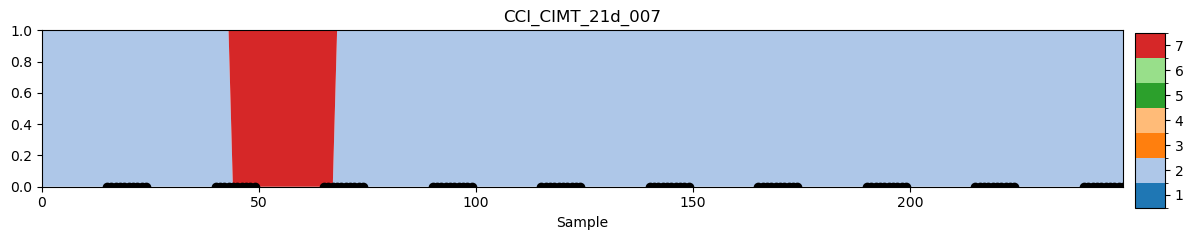

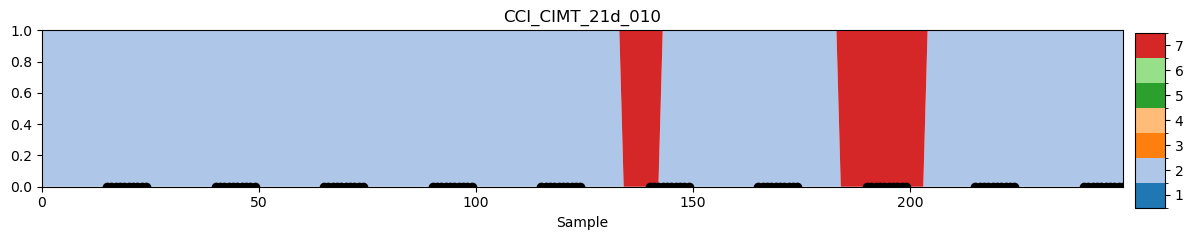

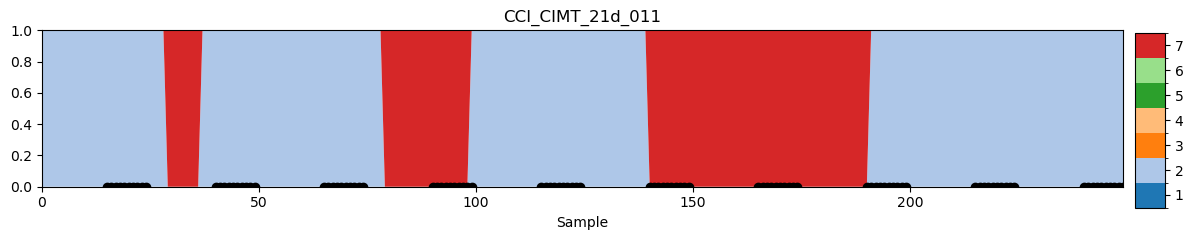

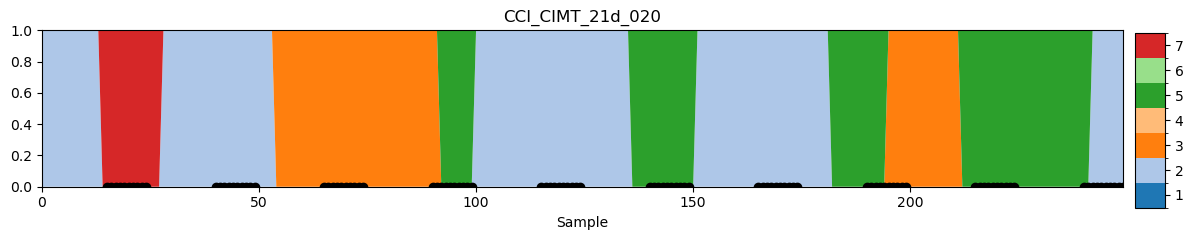

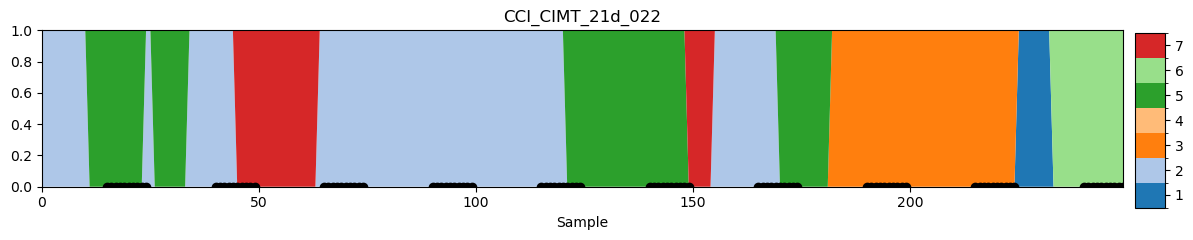

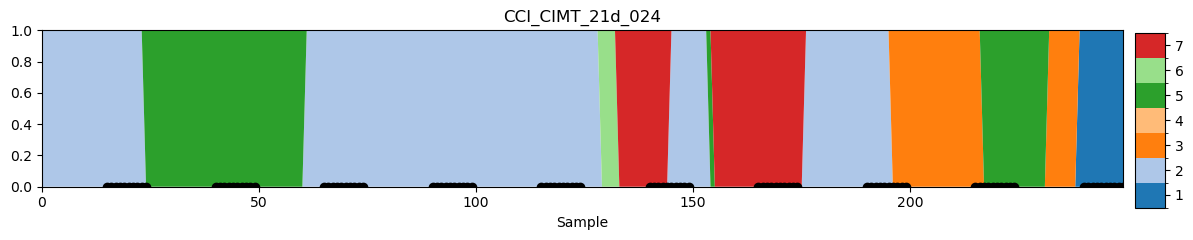

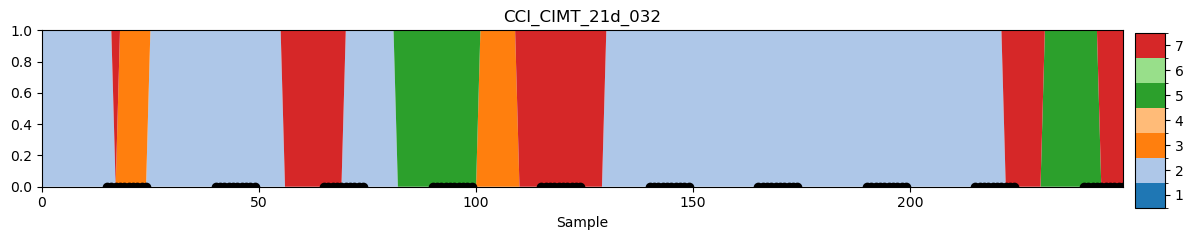

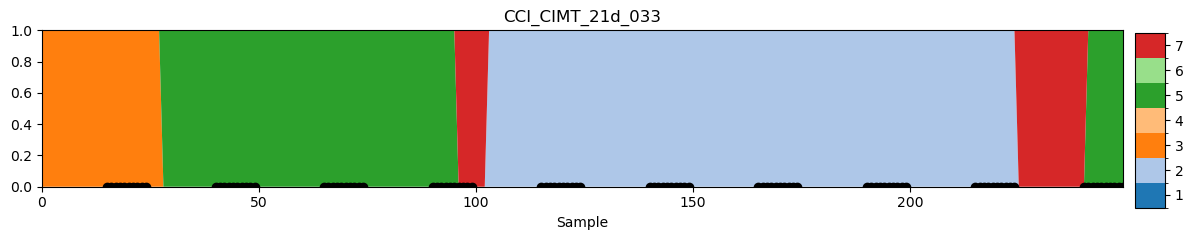

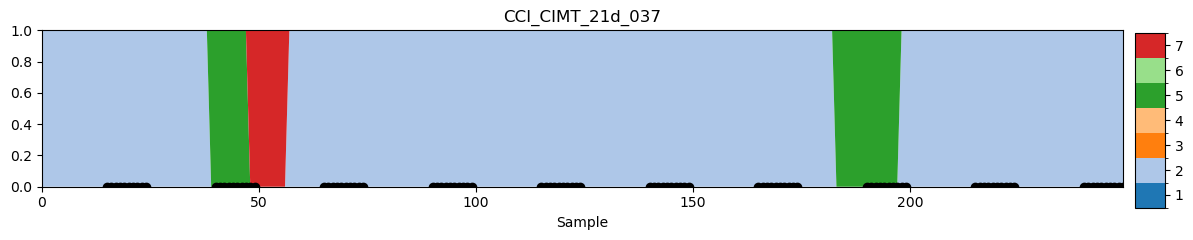

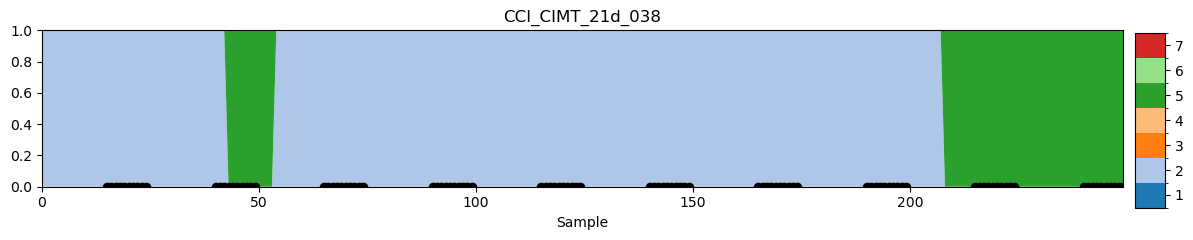

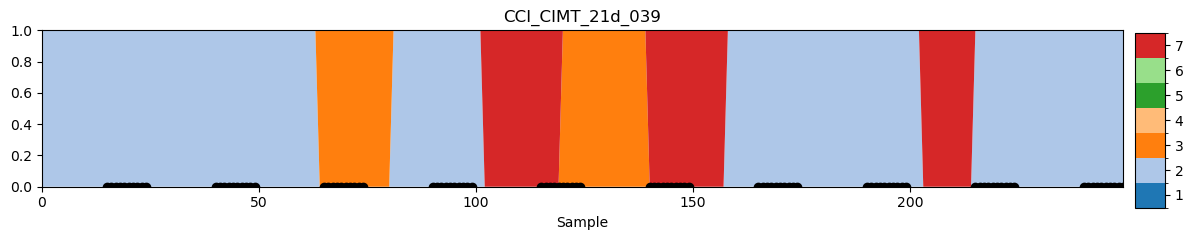

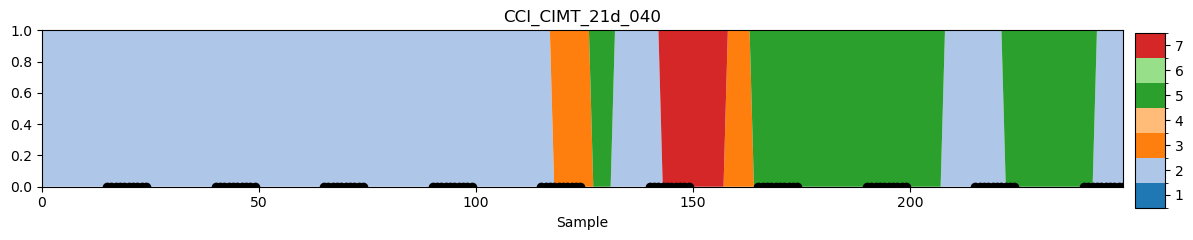

In [110]:
# CCI_CIMT_21d
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

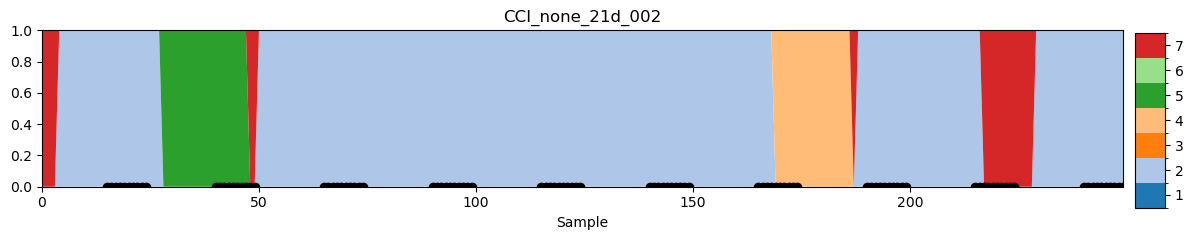

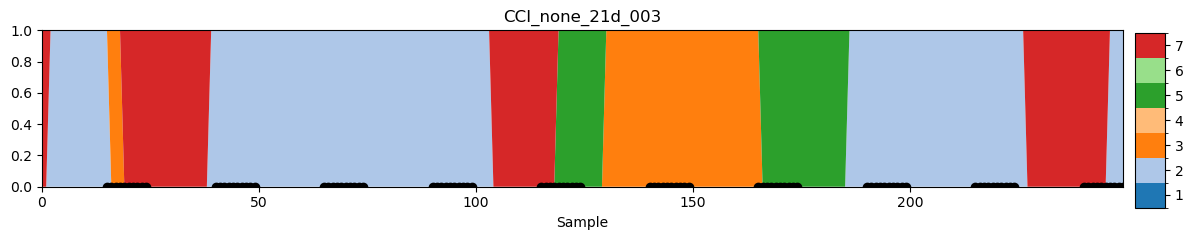

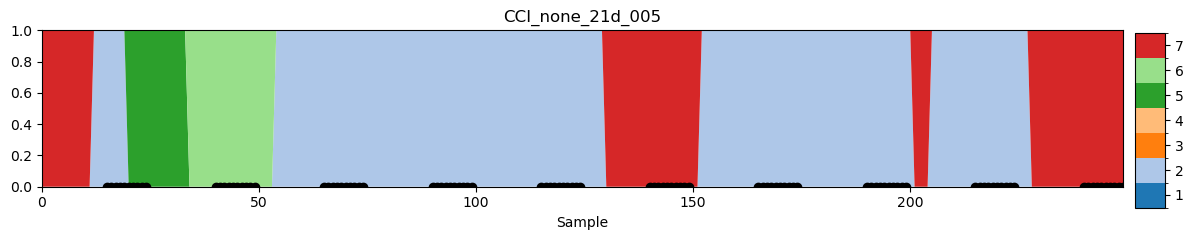

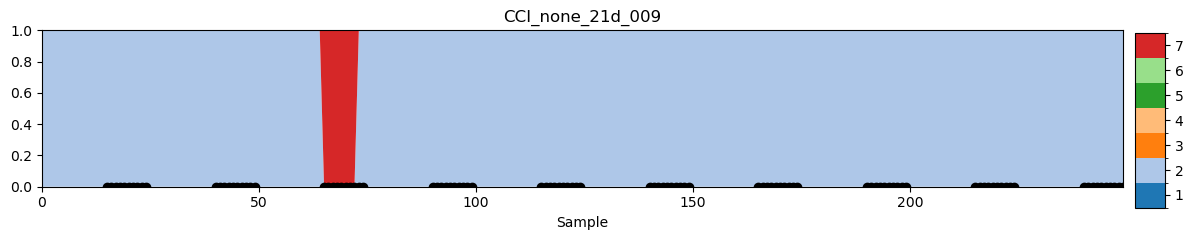

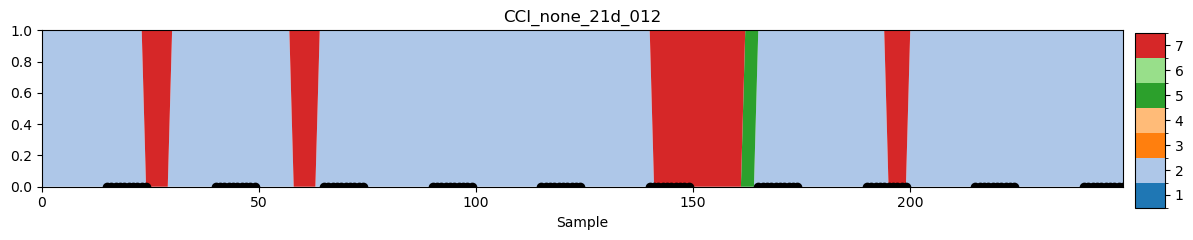

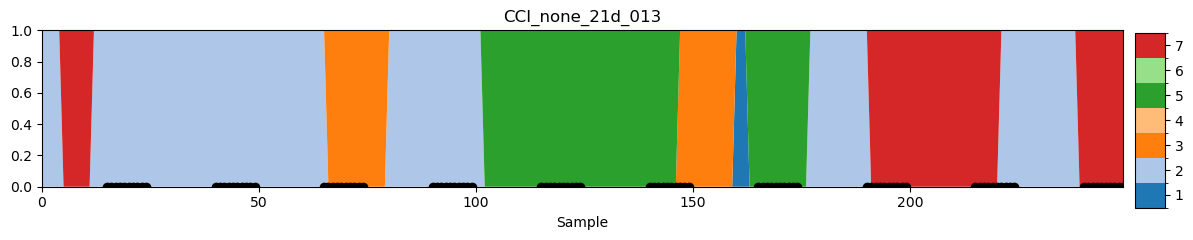

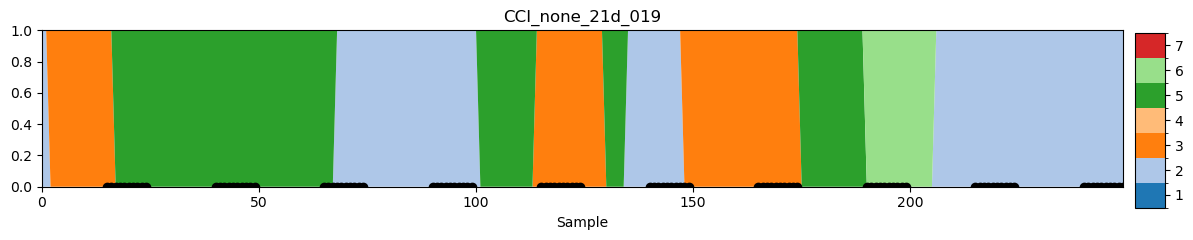

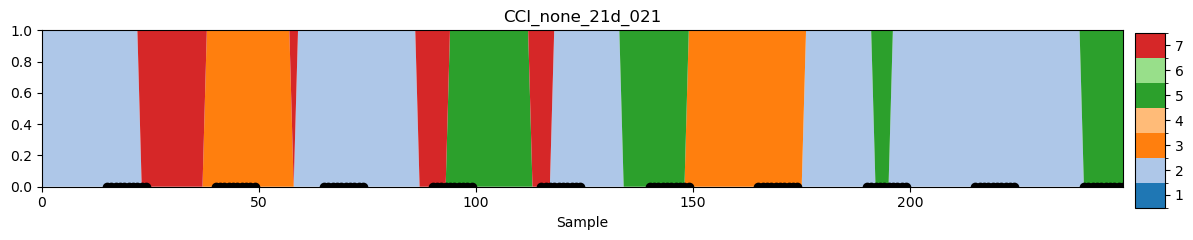

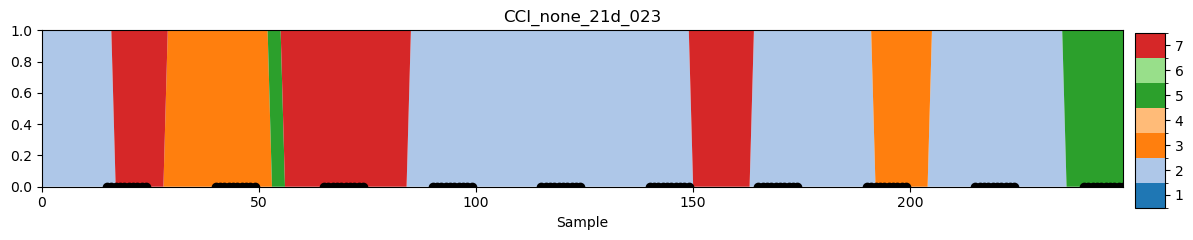

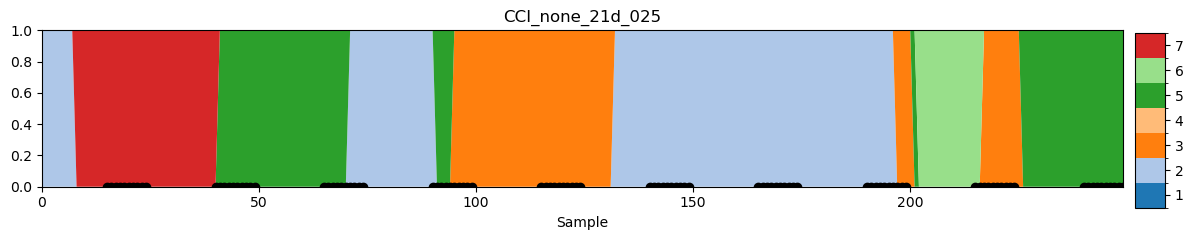

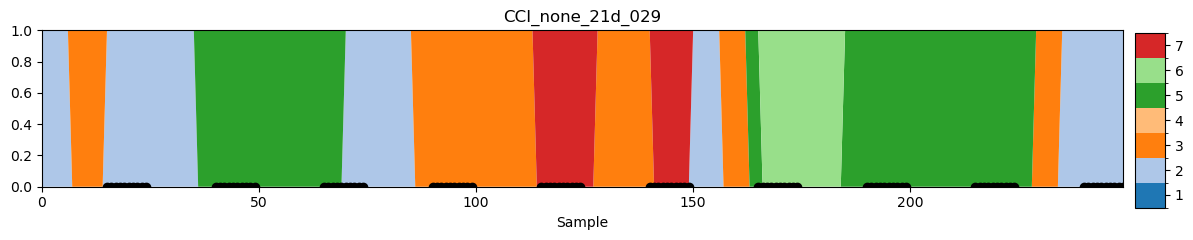

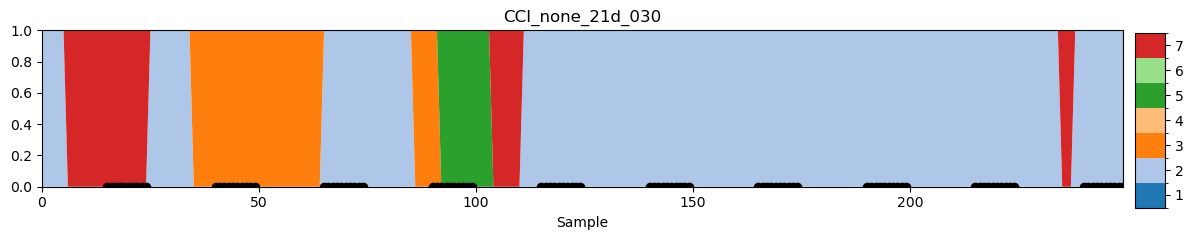

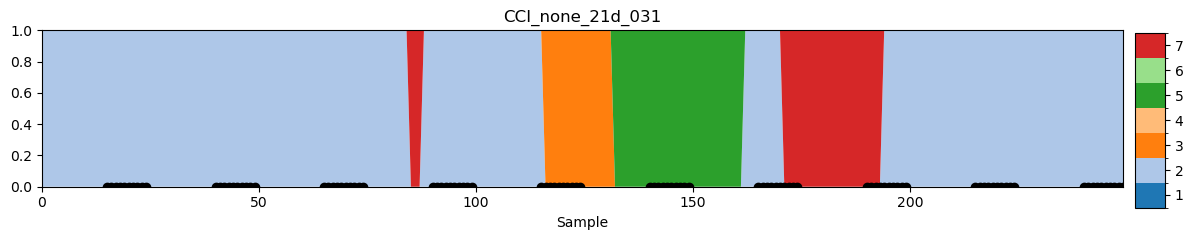

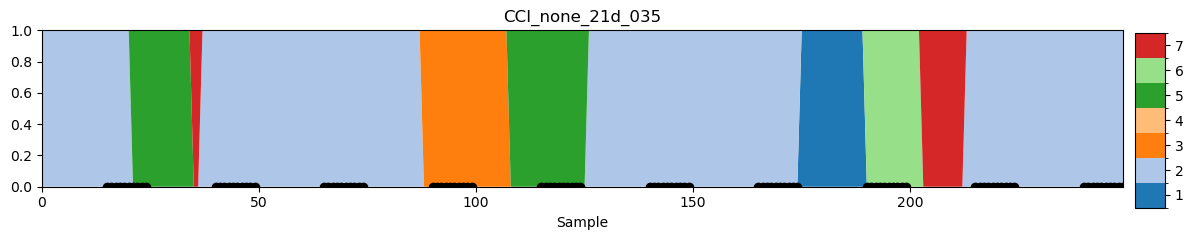

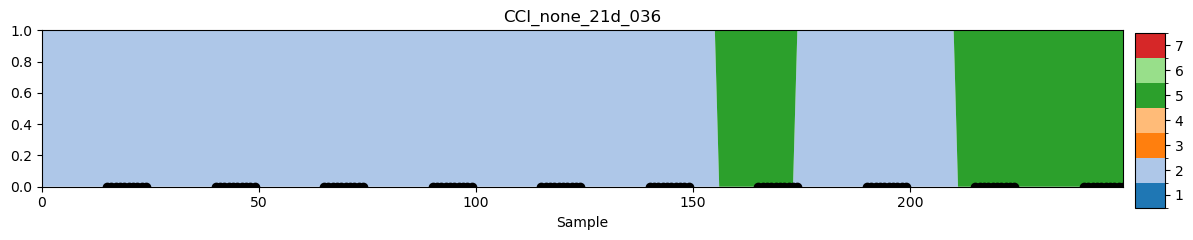

In [111]:
# CCI_none_21d
for subj in np.where(y == 'CCI_none_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

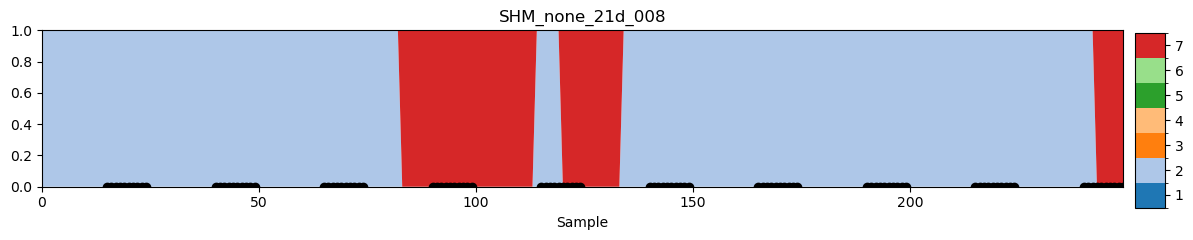

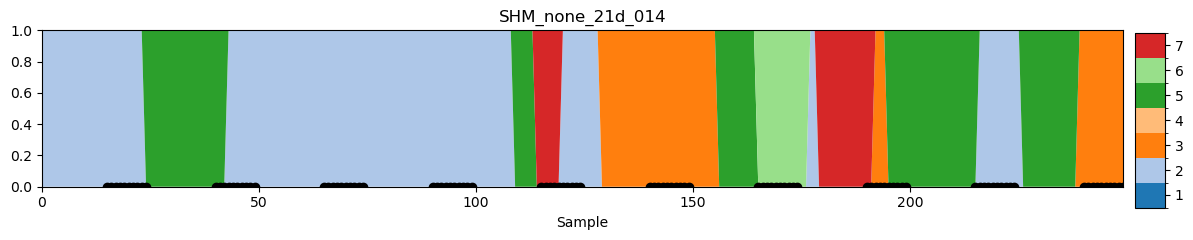

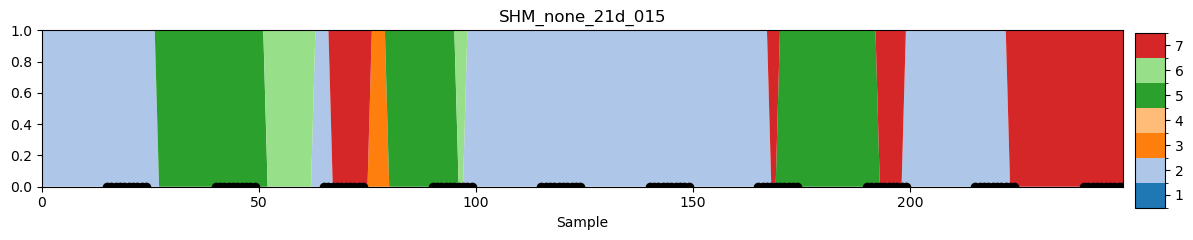

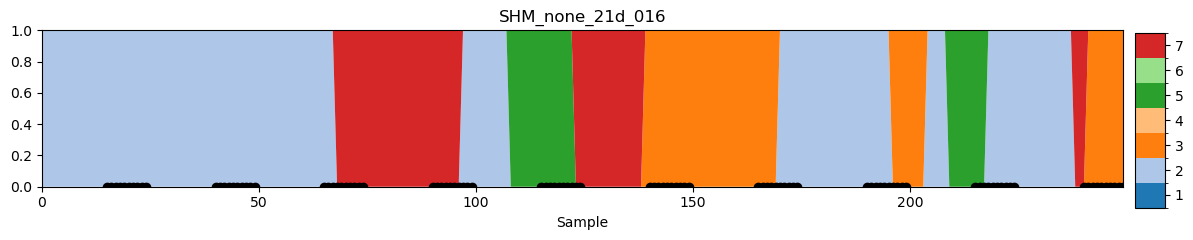

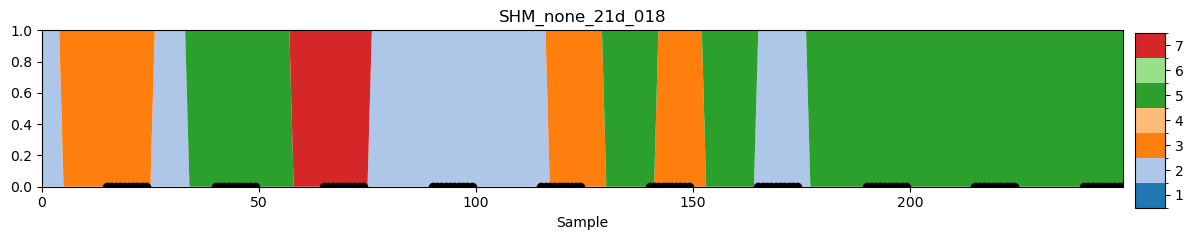

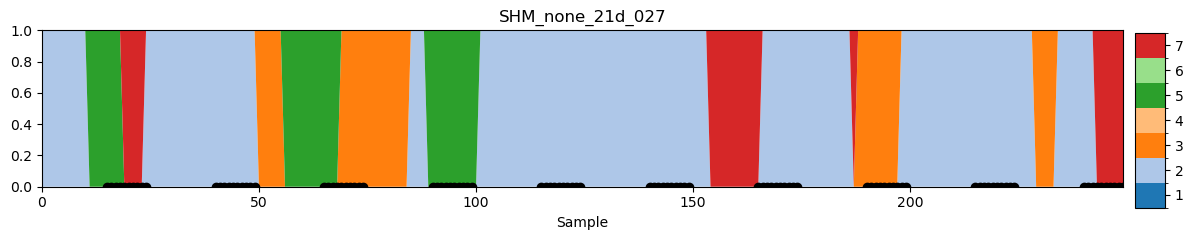

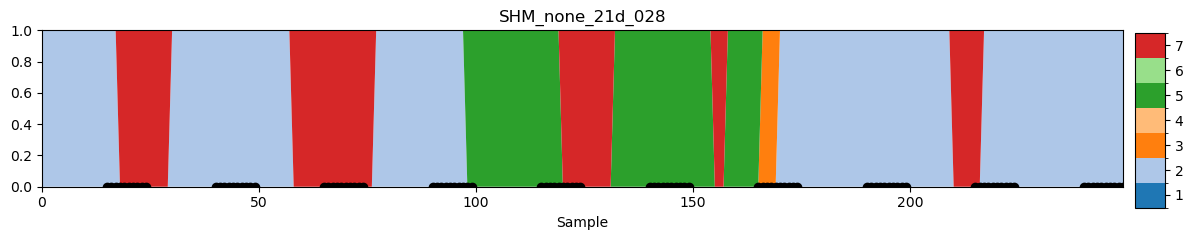

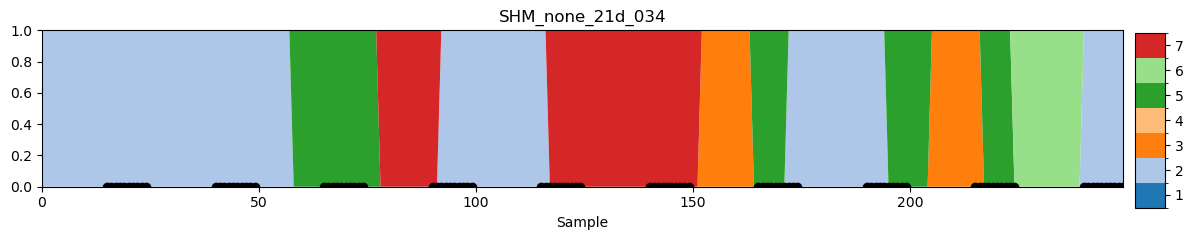

In [112]:
# SHM_none_21d
for subj in np.where(y == 'SHM_none_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

### 49d

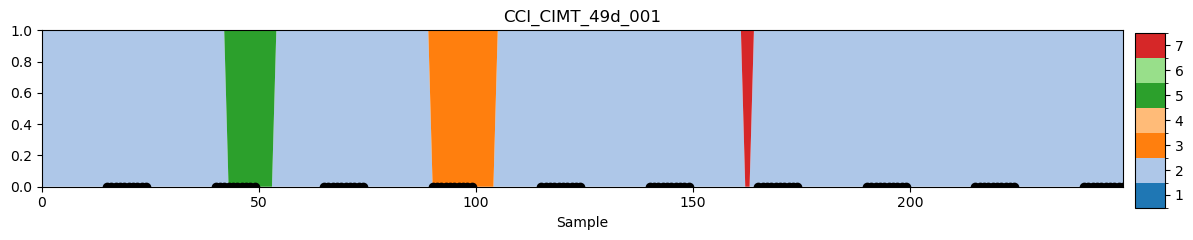

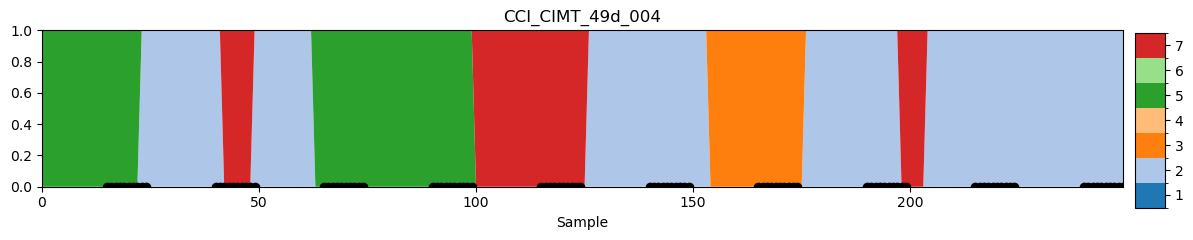

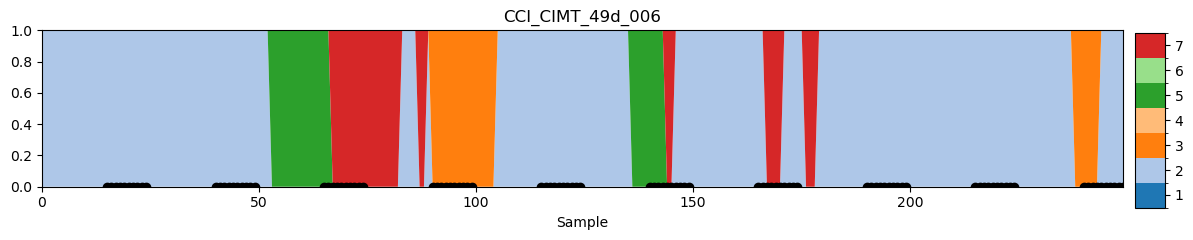

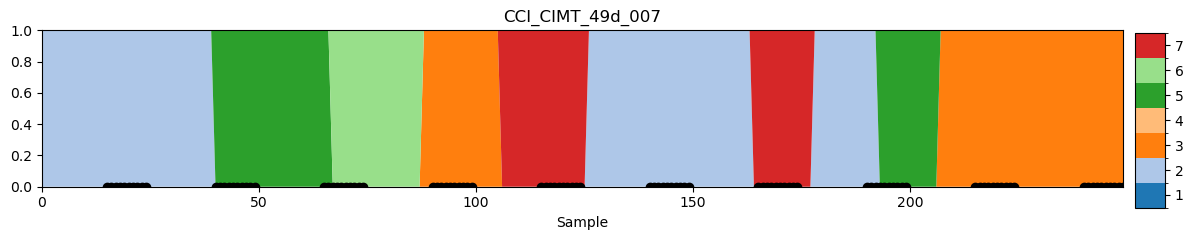

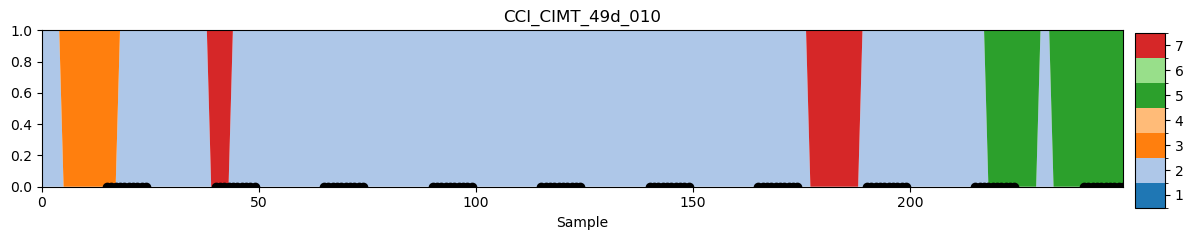

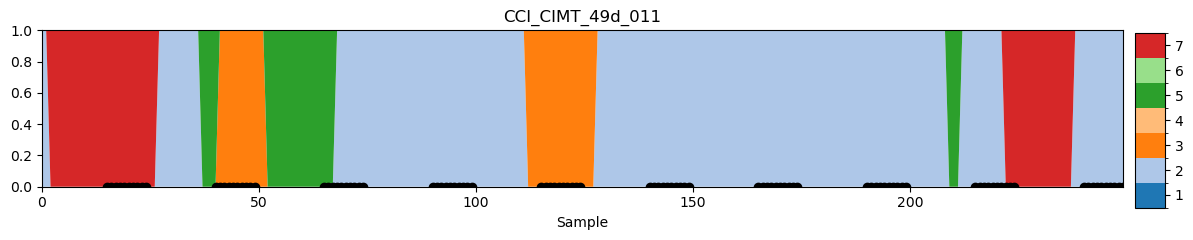

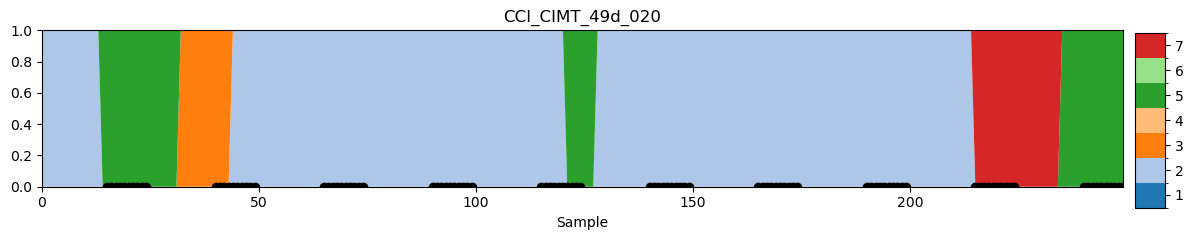

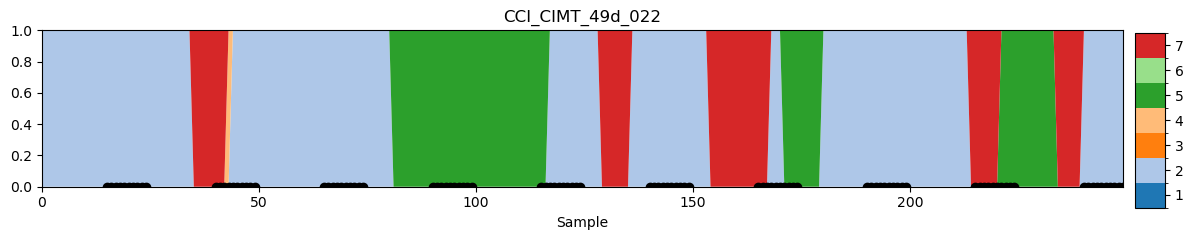

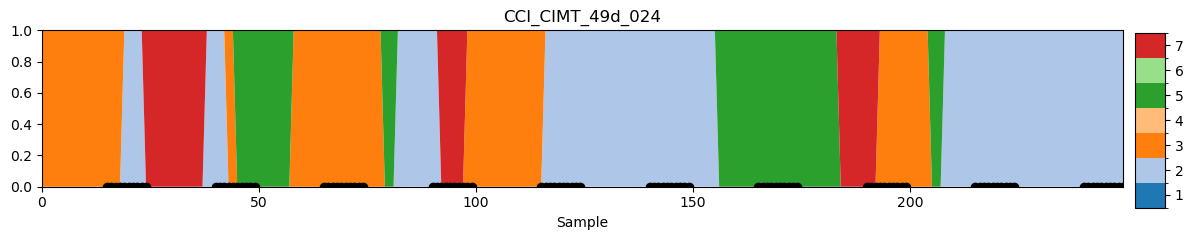

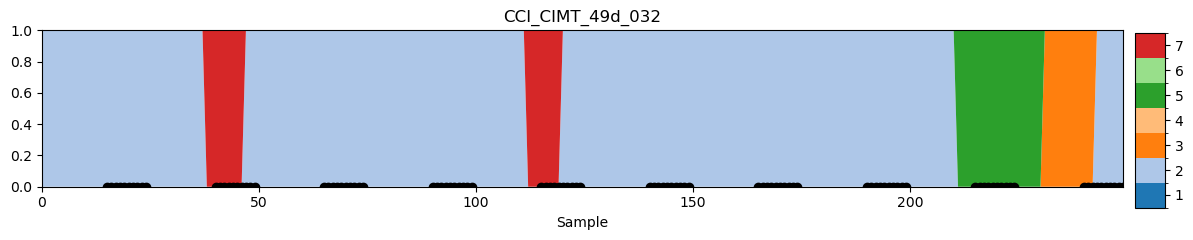

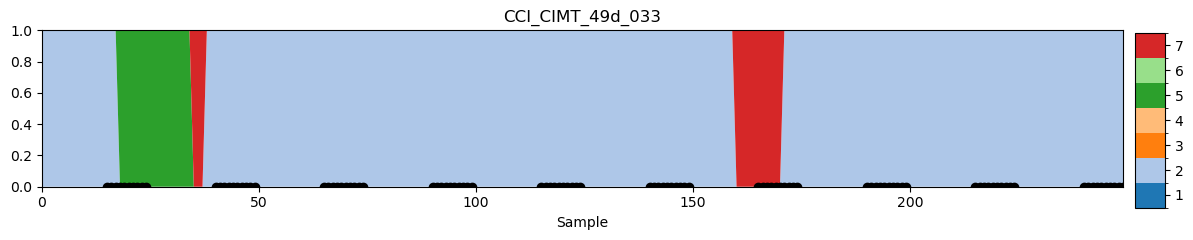

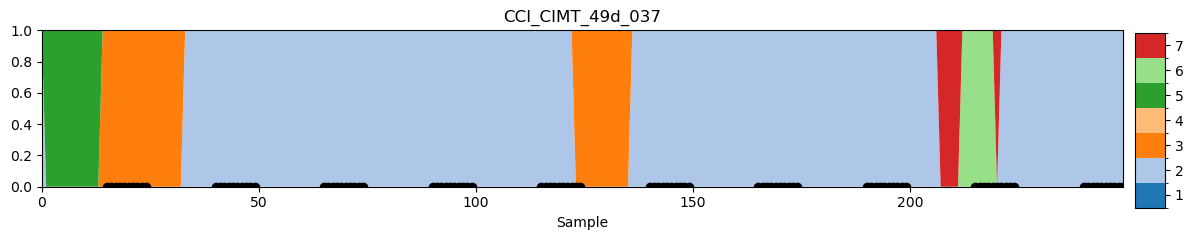

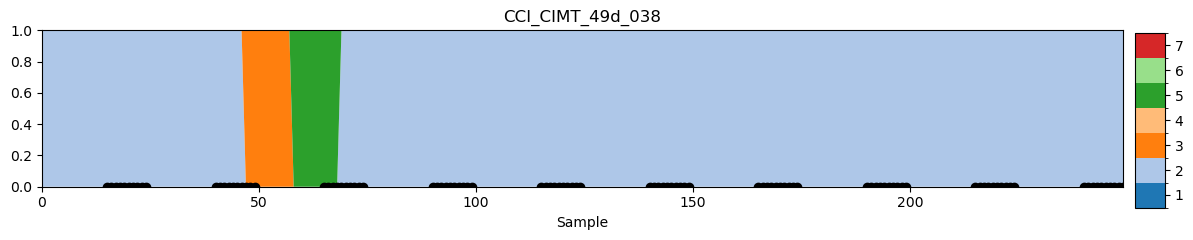

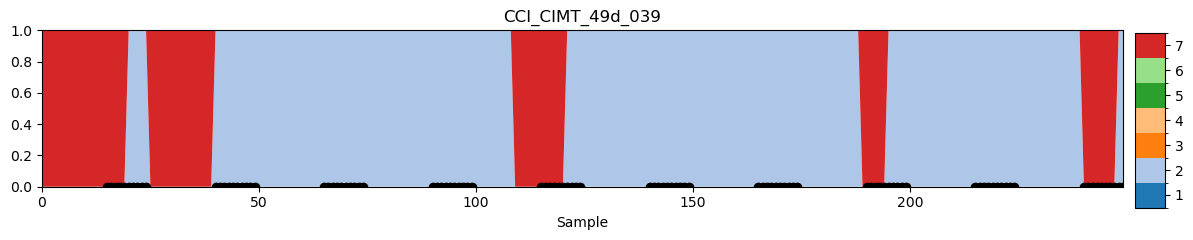

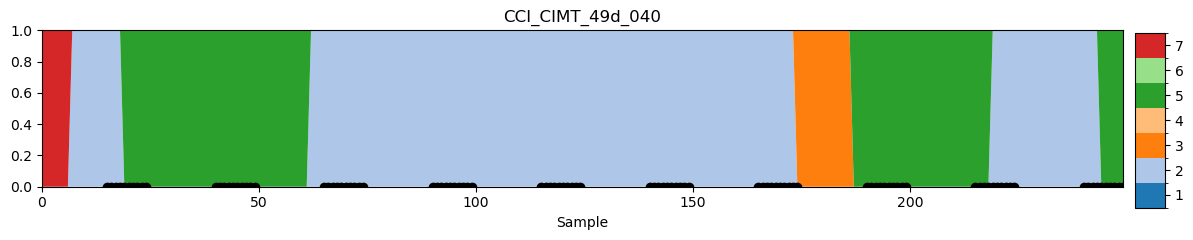

In [113]:
# CCI_CIMT_49d
for subj in np.where(y == 'CCI_CIMT_49d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

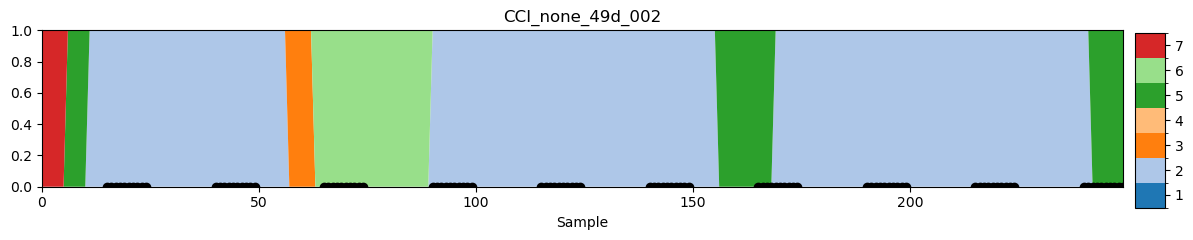

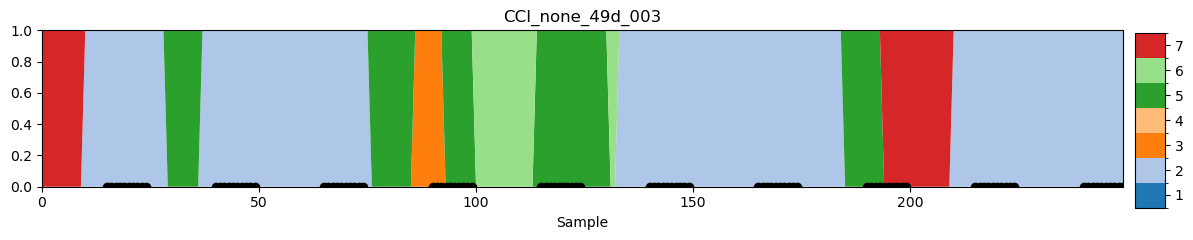

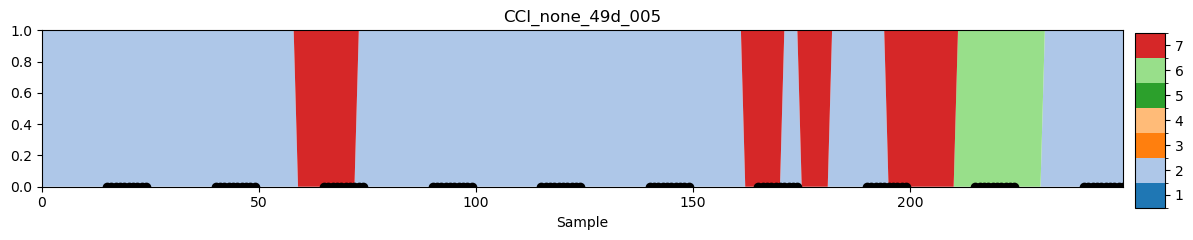

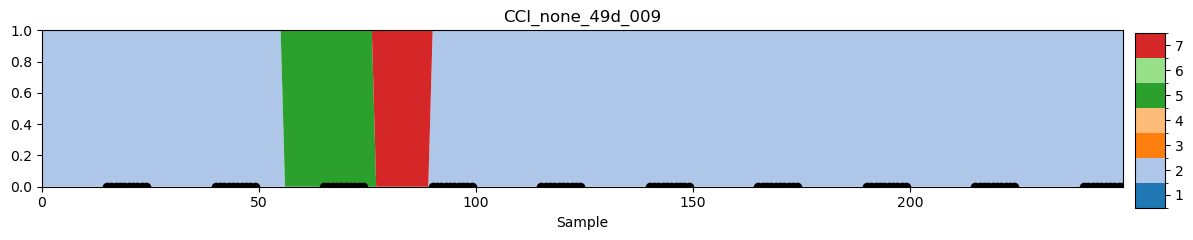

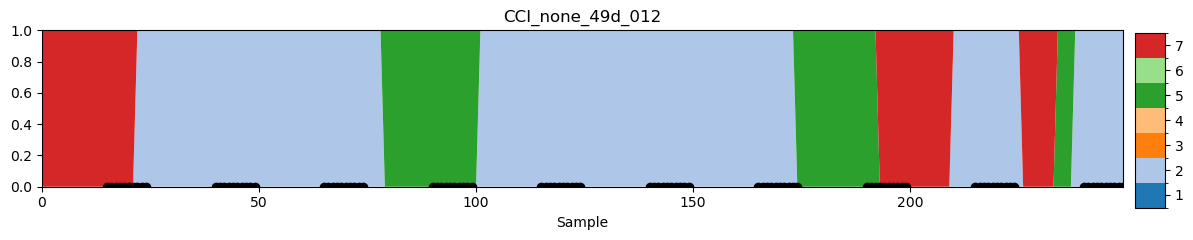

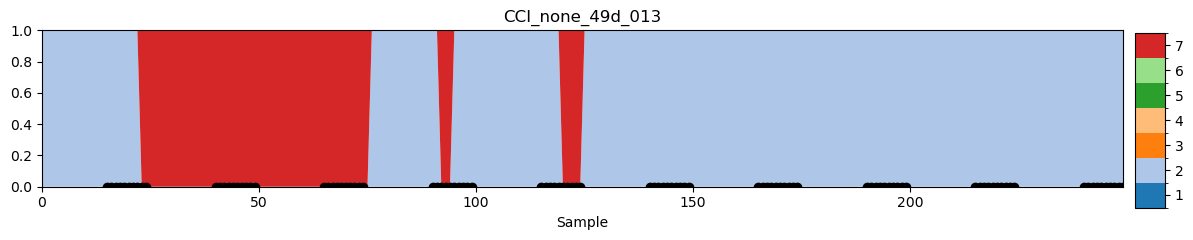

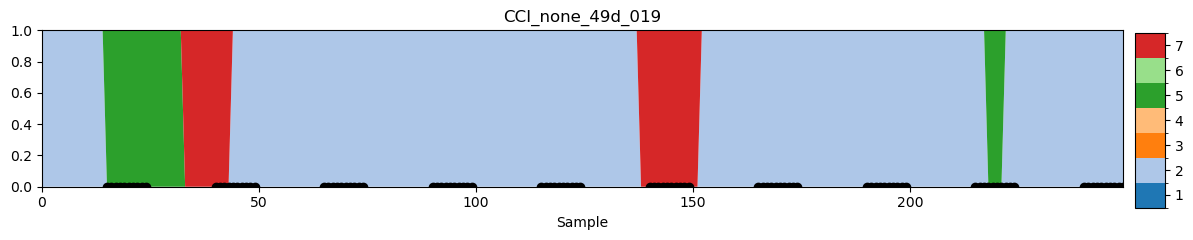

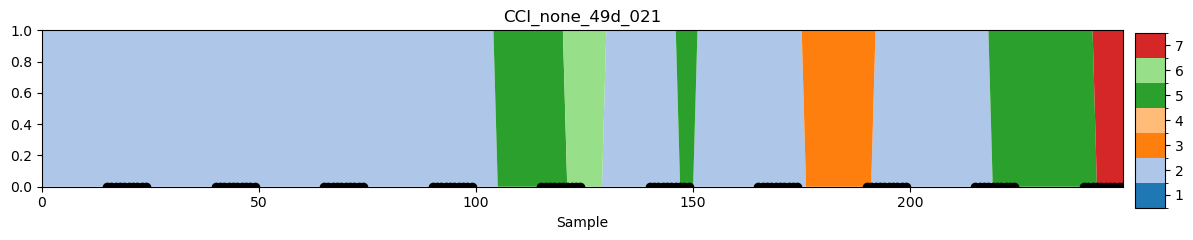

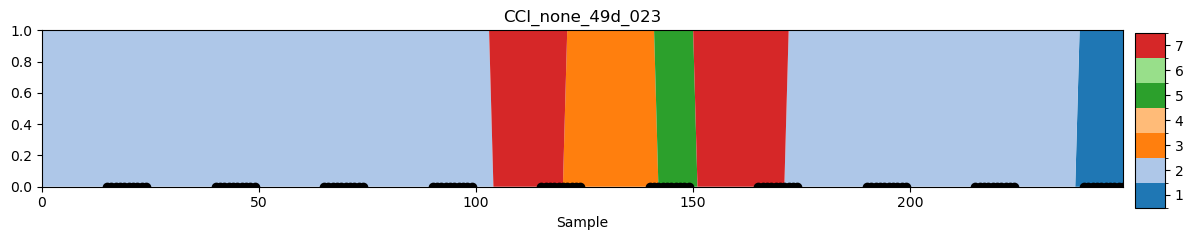

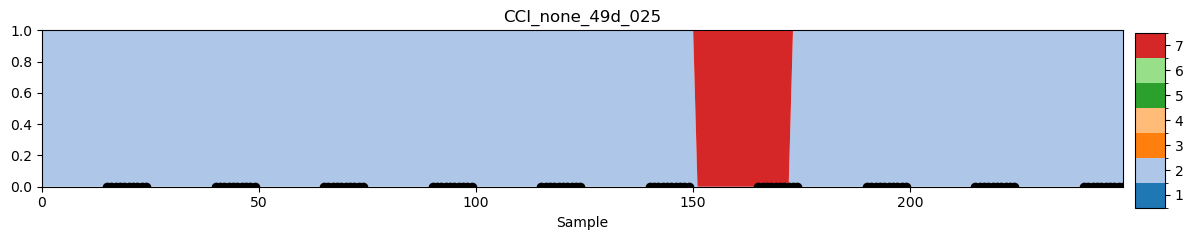

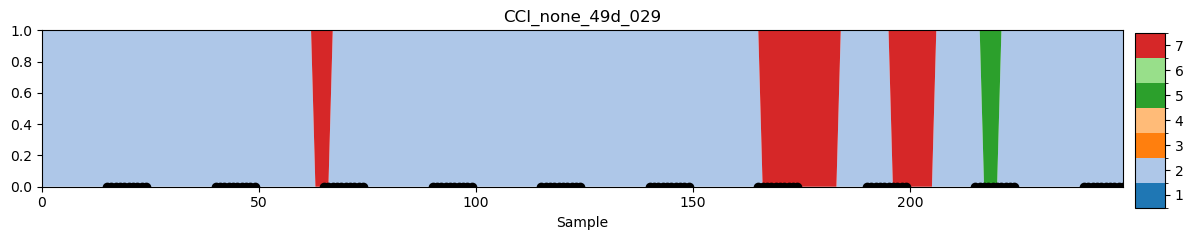

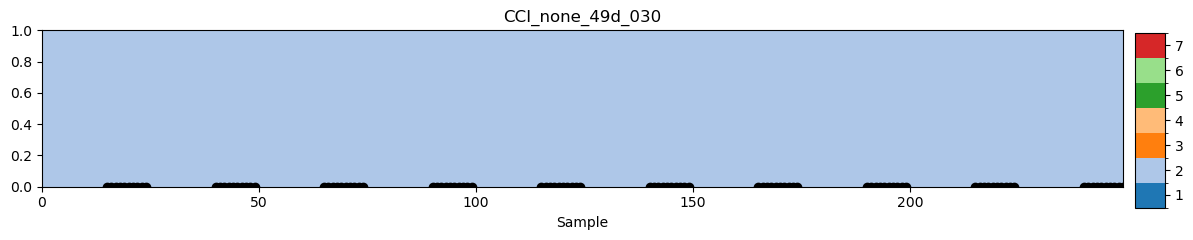

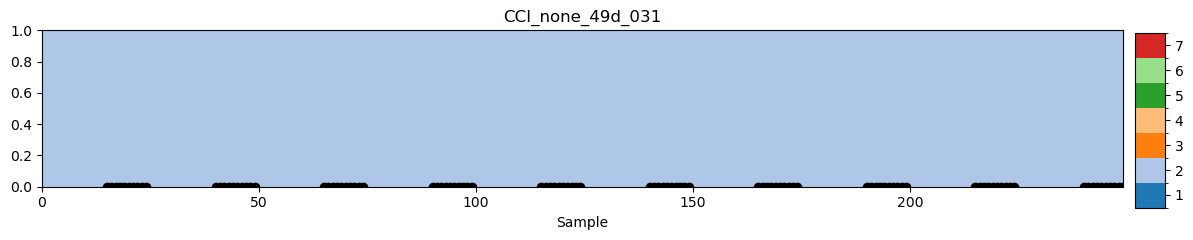

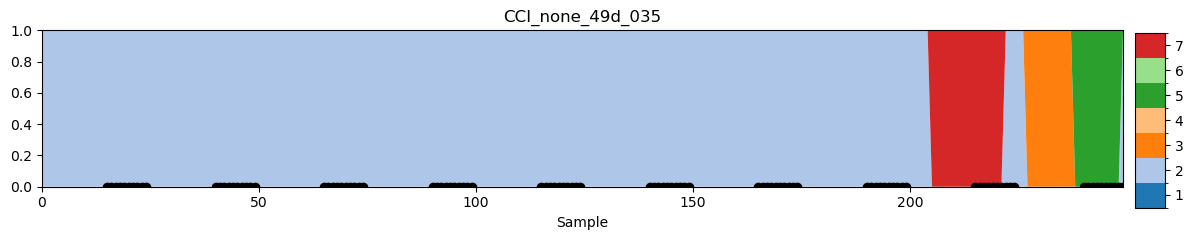

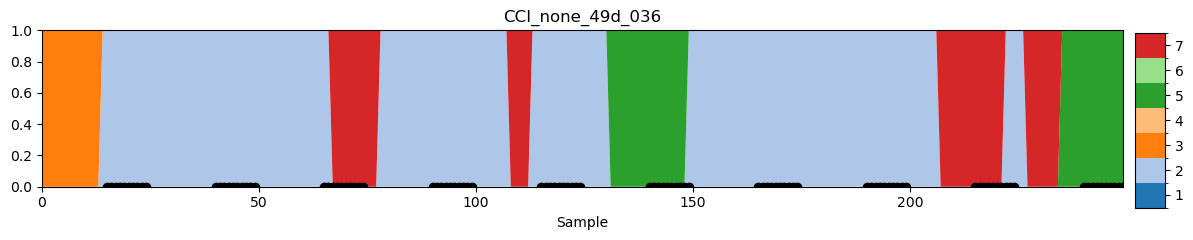

In [114]:
# CCI_none_49d
for subj in np.where(y == 'CCI_none_49d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

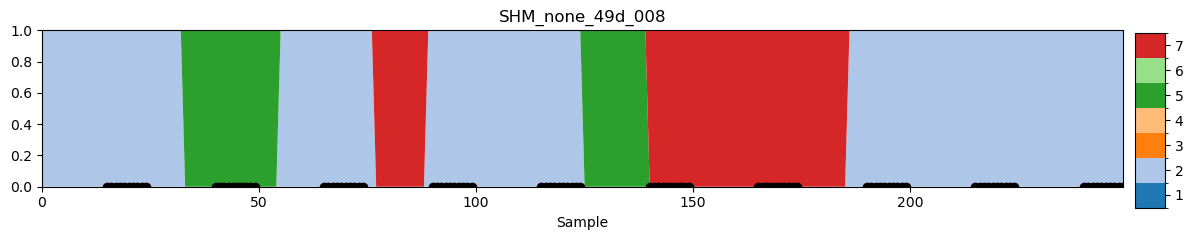

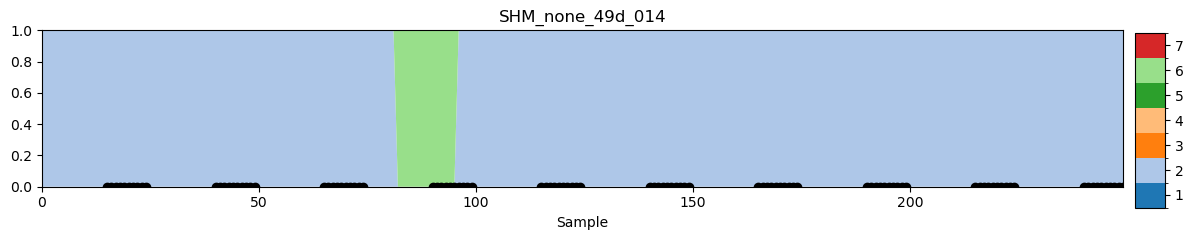

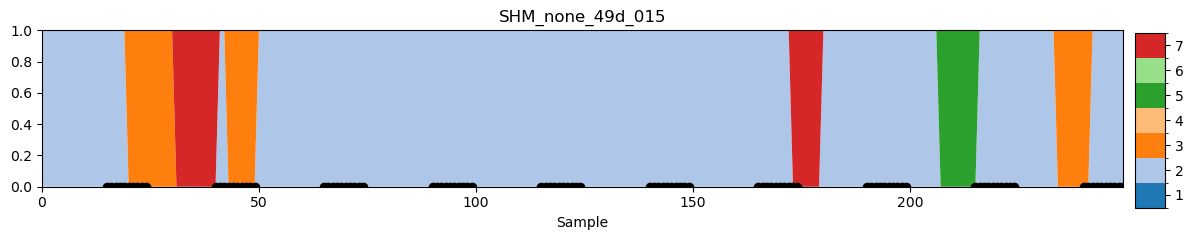

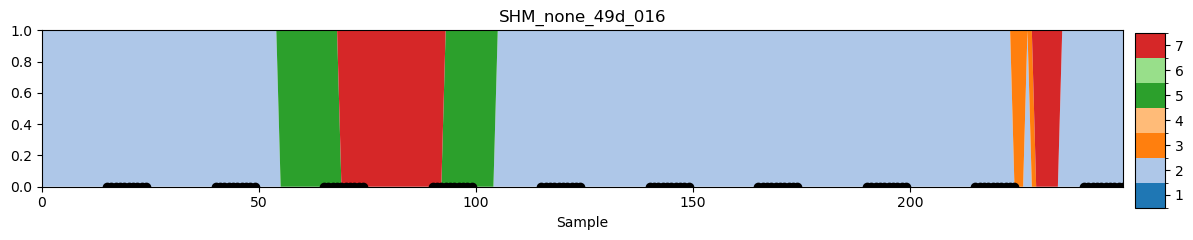

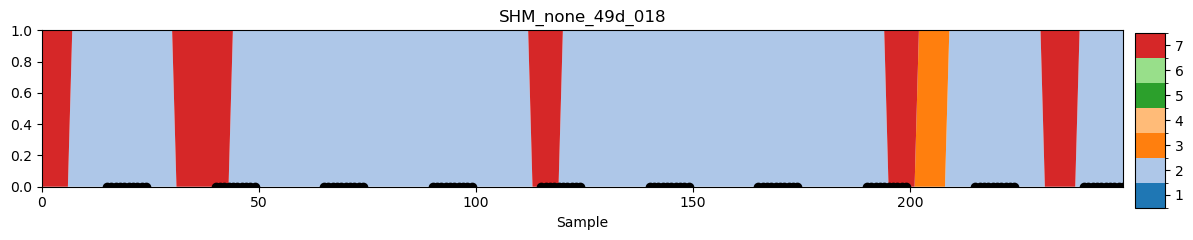

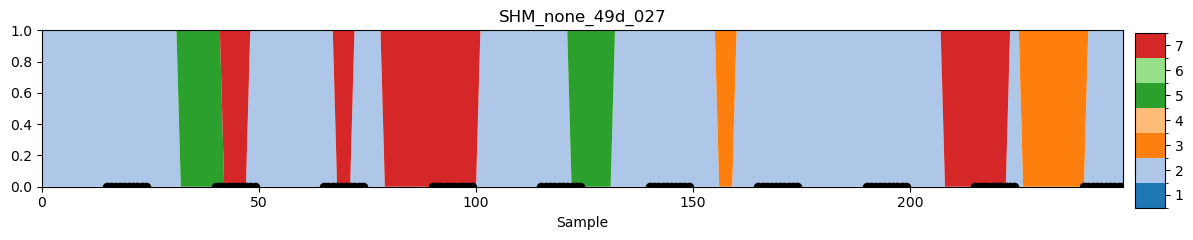

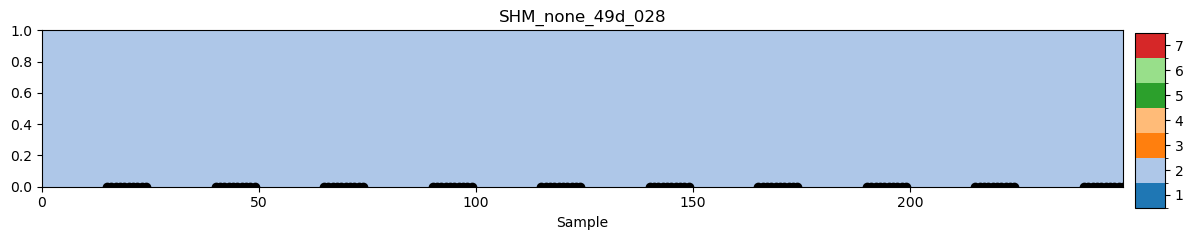

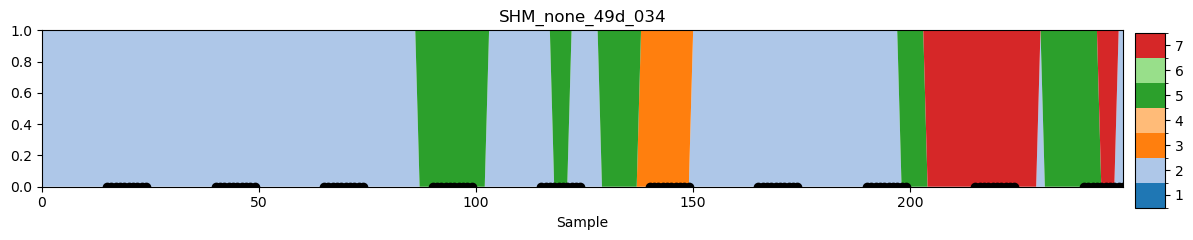

In [115]:
# SHM_none_49d
for subj in np.where(y == 'SHM_none_49d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'LLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])

## Overall Mean State Lifetimes, Intervals, and Switching Rates

[ 8.57485558 21.74104619 27.82713602 11.94377044 24.27974102  7.32871056
  5.39288423 13.92234653]


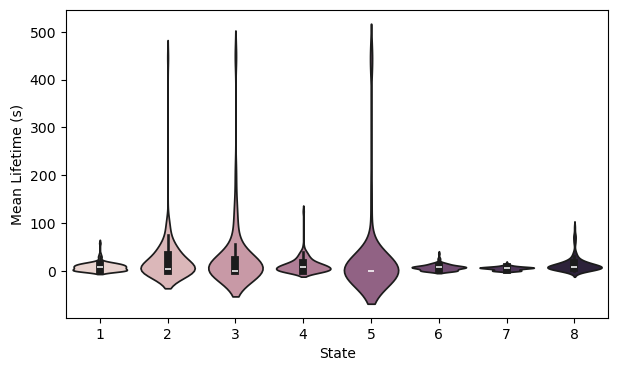

In [53]:
# Calculate mean lifetimes (in seconds)
lt = modes.mean_lifetimes(stc, sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

# # Convert to ms
# lt *= 1000

# Print the group average
print(np.mean(lt, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(lt.T, x_label="State", y_label="Mean Lifetime (s)")

[50.45887841 53.62582846 28.56734893 49.66622232  4.14239766 41.16242064
 72.59377731 95.24441043]


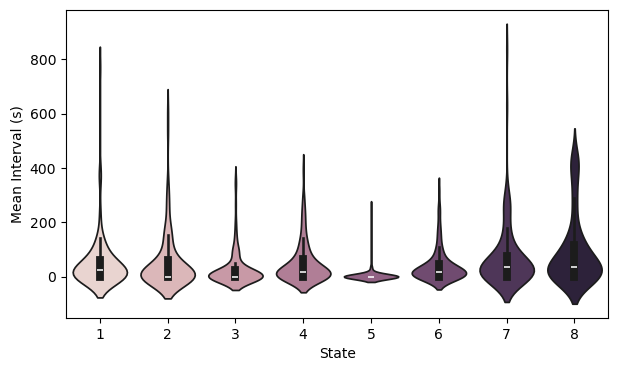

In [54]:
# Calculate mean intervals (in seconds). An interval is the duration between successive visits for a particular state
intv = modes.mean_intervals(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(intv, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(intv.T, x_label="State", y_label="Mean Interval (s)")

[0.0070078  0.00309942 0.00191033 0.00823587 0.00034113 0.01688109
 0.01148148 0.00719298]


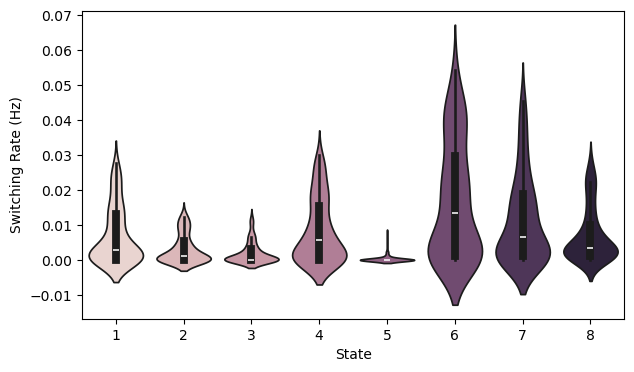

In [55]:
# Calculate the switching rate (Hz). This is defined as the number of state activations per second.
sr = modes.switching_rates(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(sr, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(sr.T, x_label="State", y_label="Switching Rate (Hz)")

## Group-level FO

In [56]:
groups = {}

for group in np.unique(y):
    groups[group] = {}

In [57]:
# FO means for each experimental group
for group in groups:
    groups[group]['fo'] = fo[np.where(y == group)]
    print(f"FO means for {group}:", np.mean(groups[group]['fo'], axis=0))

print(sum([len(groups[group]['fo']) for group in groups]) == full_data.n_sessions)

FO means for CCI_CIMT_07d: [0.13022222 0.0717037  0.23511111 0.04859259 0.17407407 0.11407407
 0.05555556 0.17066667]
FO means for CCI_CIMT_21d: [0.03288889 0.24118519 0.02577778 0.29437037 0.10103704 0.18844444
 0.09140741 0.02488889]
FO means for CCI_CIMT_49d: [0.068      0.0797037  0.17762963 0.19185185 0.13066667 0.14859259
 0.07540741 0.12814815]
FO means for CCI_none_07d: [0.05555556 0.00755556 0.27422222 0.10696296 0.00207407 0.19037037
 0.13940741 0.22385185]
FO means for CCI_none_21d: [0.04581197 0.21521368 0.00735043 0.28769231 0.0808547  0.19042735
 0.11333333 0.05931624]
FO means for CCI_none_49d: [0.09081481 0.07777778 0.13777778 0.15437037 0.06488889 0.23940741
 0.0997037  0.13525926]
FO means for SHM_none_07d: [0.215      0.24861111 0.12694444 0.01027778 0.00416667 0.01194444
 0.00472222 0.37833333]
FO means for SHM_none_21d: [0.10765432 0.25135802 0.00444444 0.20246914 0.         0.22049383
 0.09259259 0.12098765]
FO means for SHM_none_49d: [0.13209877 0.20419753 0.1034

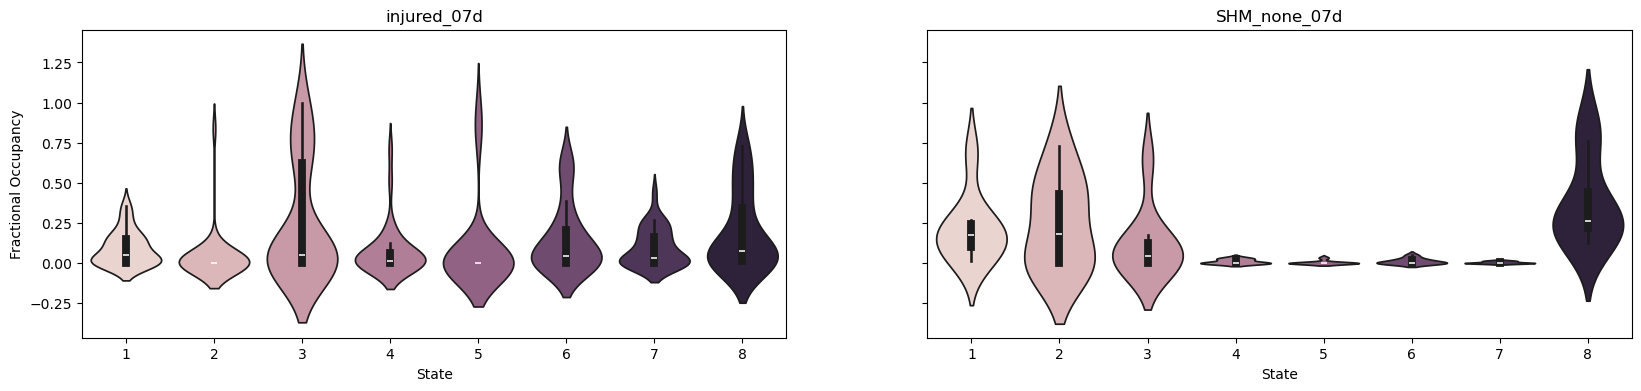

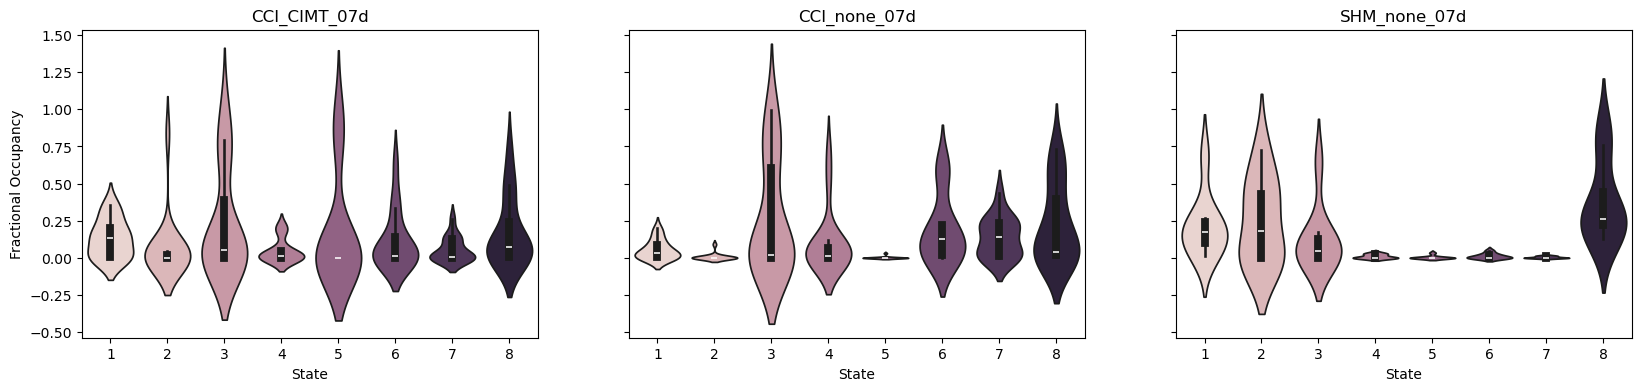

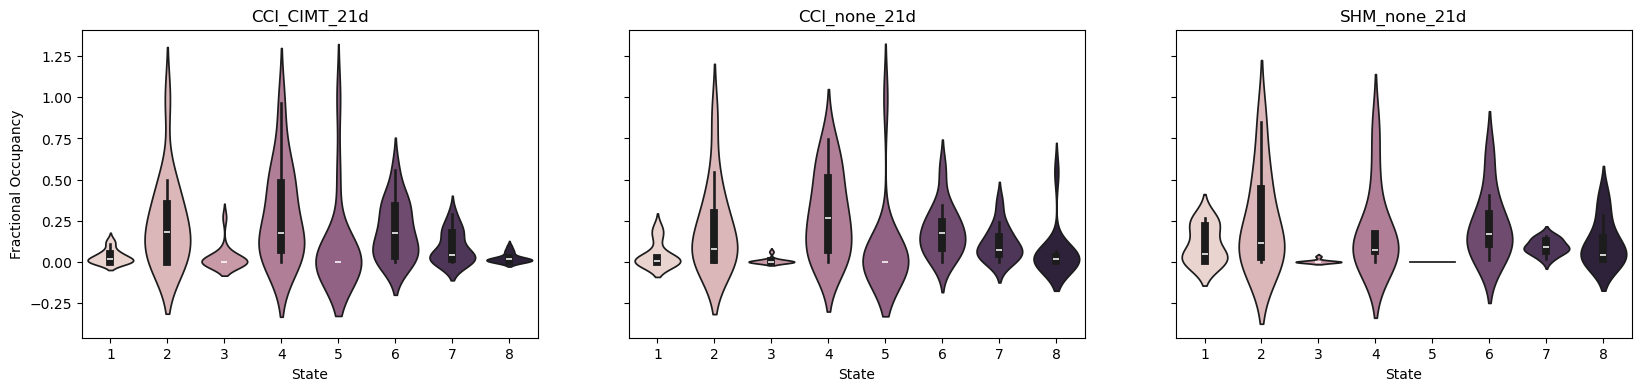

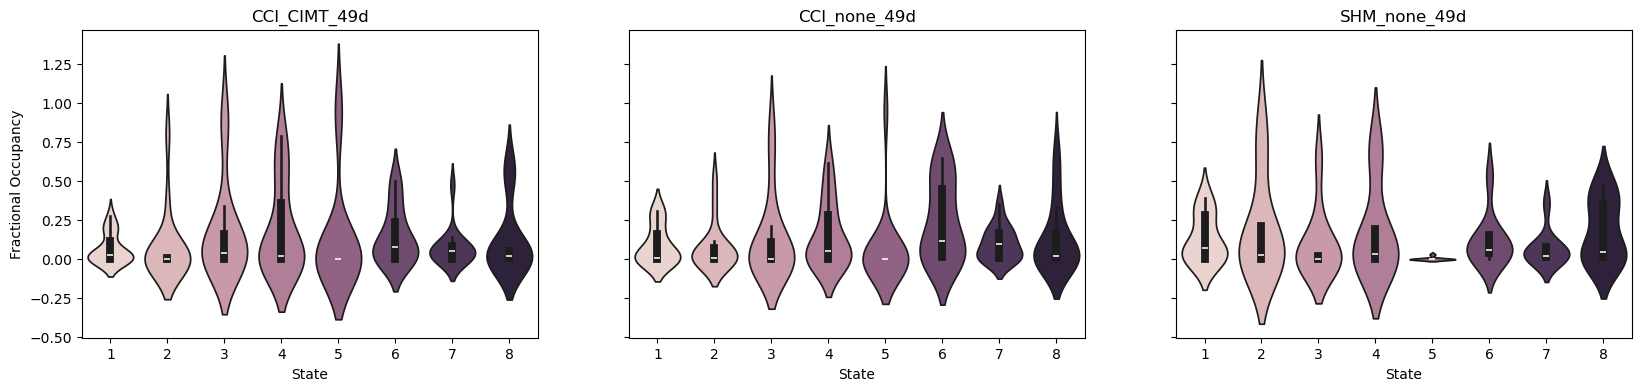

In [58]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
plotting.plot_violin(
    np.concatenate((groups['CCI_CIMT_07d']['fo'], groups['CCI_none_07d']['fo']), axis=0).T, 
    x_label="State", 
    y_label="Fractional Occupancy", 
    title="injured_07d", 
    ax=ax[0]
)
plotting.plot_violin(groups['SHM_none_07d']['fo'].T, x_label="State", y_label="Fractional Occupancy", title="SHM_none_07d", ax=ax[1])

for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['fo'].T, x_label="State", y_label="Fractional Occupancy", title="SHM_none_" + PID, ax=ax[2])

## Group-level mean state lifetimes

In [59]:
# State time course (STC) for each experimental group
for group in groups:
    groups[group]['stc'] = [stc[i] for i in range(len(stc)) if i in np.where(y == group)[0]]

print(sum([len(groups[group]['stc']) for group in groups]) == full_data.n_sessions)

True


In [60]:
# Calculate mean lifetimes (in seconds) for each experimental group
for group in groups:
    groups[group]['lt'] = modes.mean_lifetimes(groups[group]['stc'], sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

print(sum([len(groups[group]['lt']) for group in groups]) == full_data.n_sessions)

True


CCI_CIMT_07d: [ 8.22972159 10.22666667 51.1803367   5.99929825 37.56888889  5.6231332
  3.71918217 12.70085587]
CCI_CIMT_21d: [10.77407407 53.87390572  6.77777778 23.8184929  34.32380952  6.8236846
  5.70273382  6.77460317]
CCI_CIMT_49d: [ 7.45809524  9.63555556 32.31873016 10.75660131 45.5         7.69726597
  5.4049229  12.2625641 ]
CCI_none_07d: [ 5.9089899   3.15555556 67.55319865  8.27191495  1.86666667  6.49267457
  6.78128686 26.68219373]
CCI_none_21d: [ 6.5994006  29.15167055  4.46153846 16.88247863 36.38461538  7.3129487
  6.60240443  6.89151874]
CCI_none_49d: [ 7.74730159 13.8378836  22.91587302  8.03707071 29.86666667  8.18531815
  5.2379202   9.88010738]
SHM_none_07d: [13.12294372 24.31703297 29.73333333  4.125       3.75        6.16666667
  2.1875     32.15858483]
SHM_none_21d: [10.01058201 35.21296296  1.33333333 14.44330484  0.          9.04302764
  6.5306607  10.21539109]
SHM_none_49d: [10.54331162 25.2345679  17.02645503 13.98635478  3.11111111  9.70588235
  5.55454545

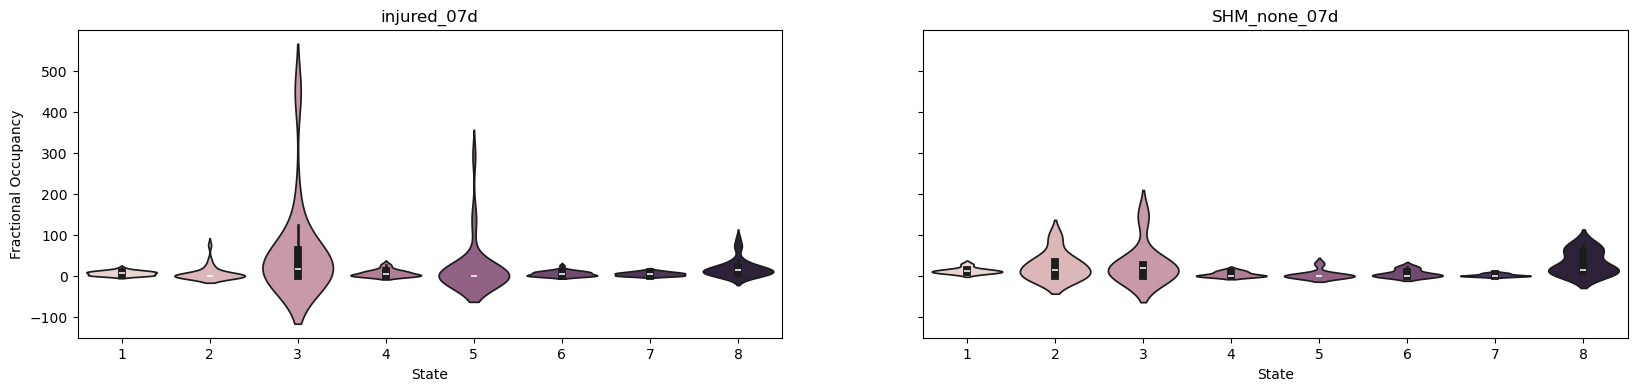

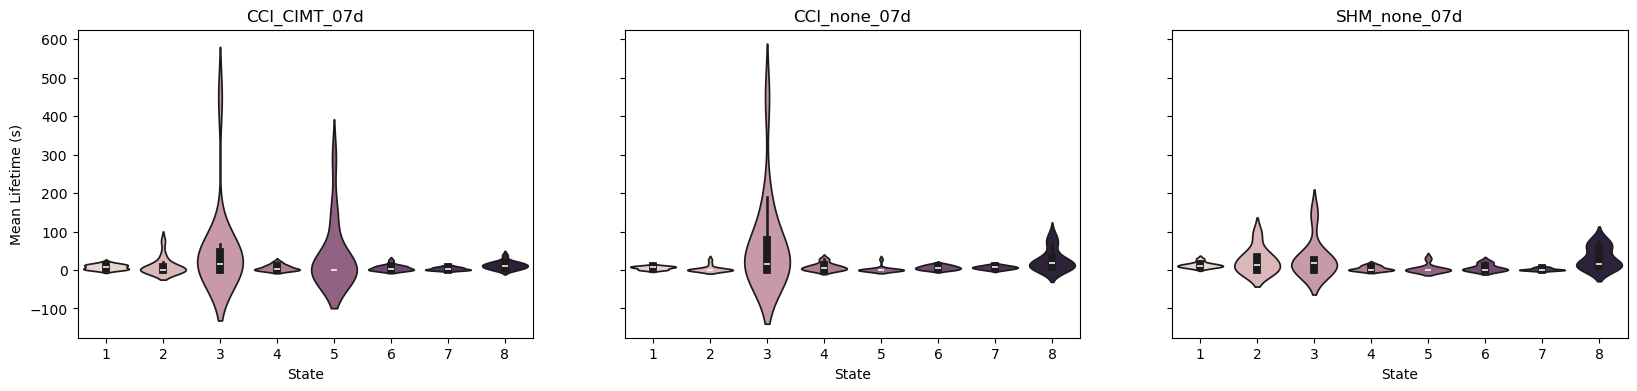

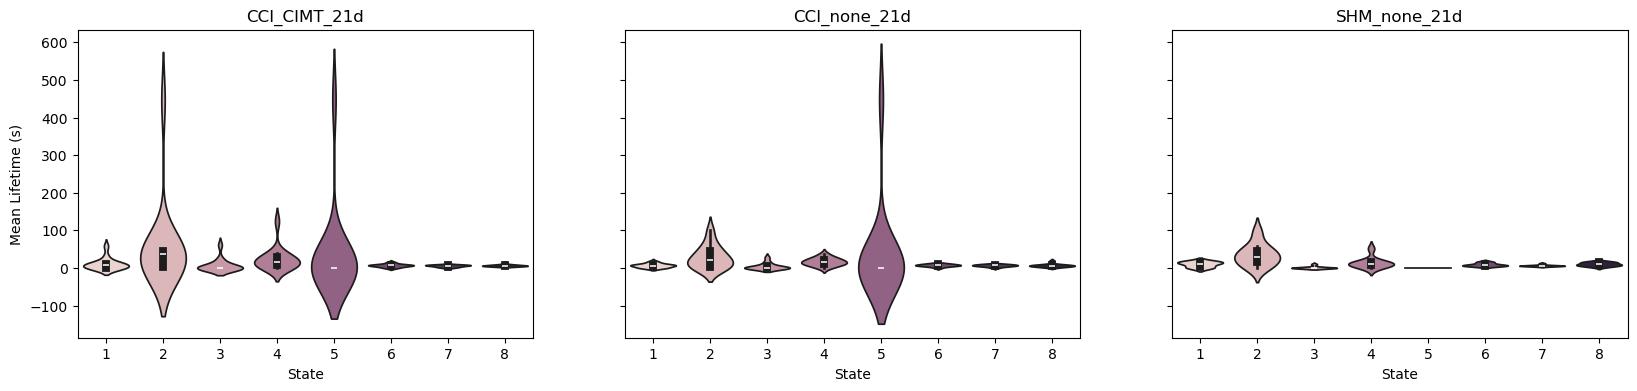

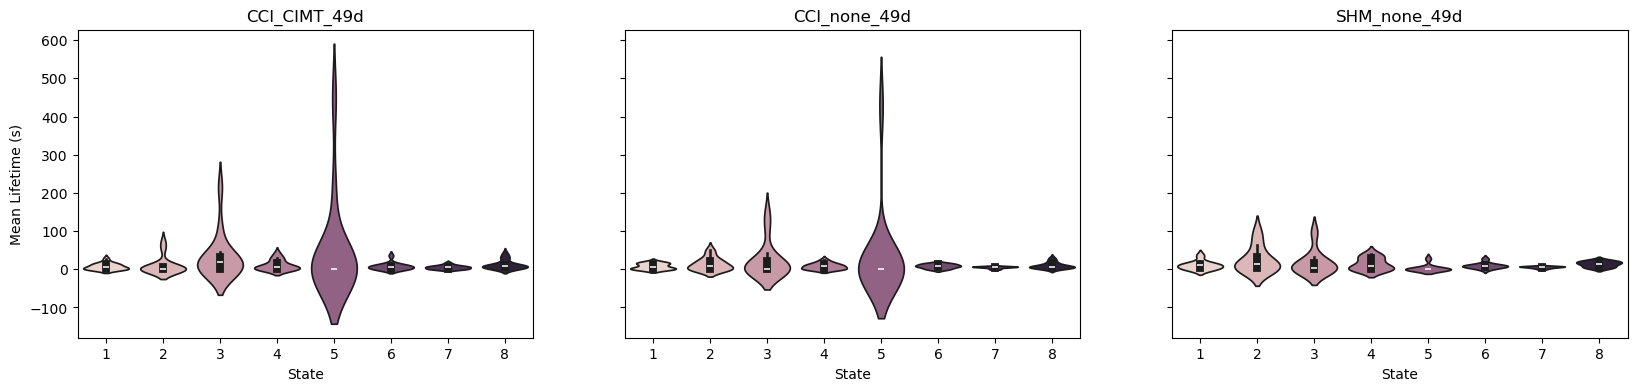

In [61]:
for group, attr in groups.items():
    # Print the group average
    print(f"{group}: {np.mean(attr['lt'], axis=0)}")

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
plotting.plot_violin(
    np.concatenate((groups['CCI_CIMT_07d']['lt'], groups['CCI_none_07d']['lt']), axis=0).T, 
    x_label="State", 
    y_label="Fractional Occupancy", 
    title="injured_07d", 
    ax=ax[0]
)
plotting.plot_violin(groups['SHM_none_07d']['lt'].T, x_label="State", y_label="Fractional Occupancy", title="SHM_none_07d", ax=ax[1])

for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['lt'].T, x_label="State", y_label="Mean Lifetime (s)", title="SHM_none_" + PID, ax=ax[2])

## Group-level mean interstate intervals

In [62]:
# Calculate mean intervals (in seconds) for each experimental group. An interval is the duration between successive visits for a particular state
for group in groups:
    groups[group]['intv'] = modes.mean_intervals(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['intv']) for group in groups]) == full_data.n_sessions)

True


CCI_CIMT_07d: [27.08940929 46.46666667 50.47740741 50.35724868  4.99333333 19.40464185
 55.23113601 40.95320878]
CCI_CIMT_21d: [100.97        66.7352381   15.37777778  45.91466914   4.48888889
  40.76547006  94.85105152 101.07555556]
CCI_CIMT_49d: [ 28.22916732  17.33037037  33.25777778  61.12529421  19.73333333
  28.39244775  52.73814815 154.08089636]
CCI_none_07d: [ 79.97227513  23.66666667  26.85888889  53.20992063   0.
  41.47673835  44.68478517 146.6153824 ]
CCI_none_21d: [10.62670663 60.78205128  2.76923077 45.64726278  0.46153846 44.74983402
 76.89767762 68.2632967 ]
CCI_none_49d: [ 35.75921622 109.82222222  21.99111111  25.47784219   1.86666667
  24.35528146  26.97532777  73.43792398]
SHM_none_07d: [ 57.13612878  19.81805556  92.77083333  99.125        0.
  33.75       122.66666667  48.31801948]
SHM_none_21d: [49.86780627 95.81128748 15.22222222 57.61763533  0.         48.27691952
 70.35641398 65.93359788]
SHM_none_49d: [ 69.77384961  38.0015873   13.56296296  23.96684303   0.


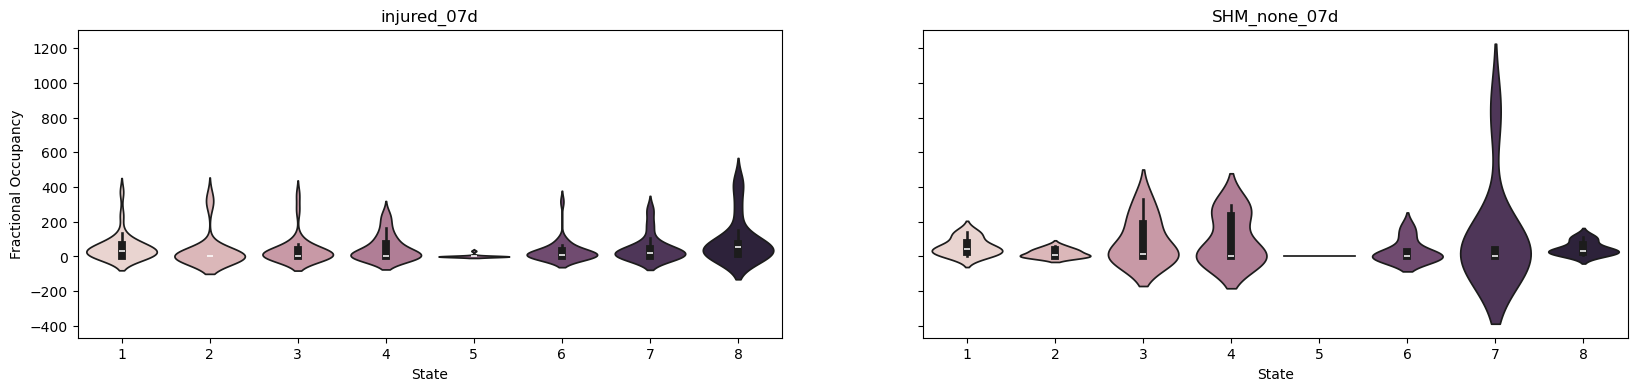

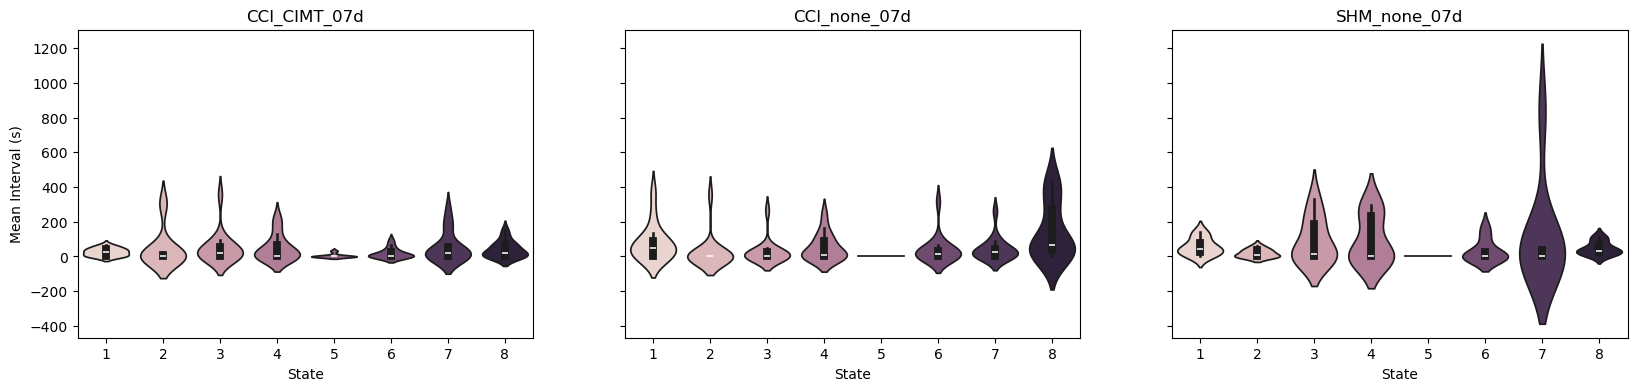

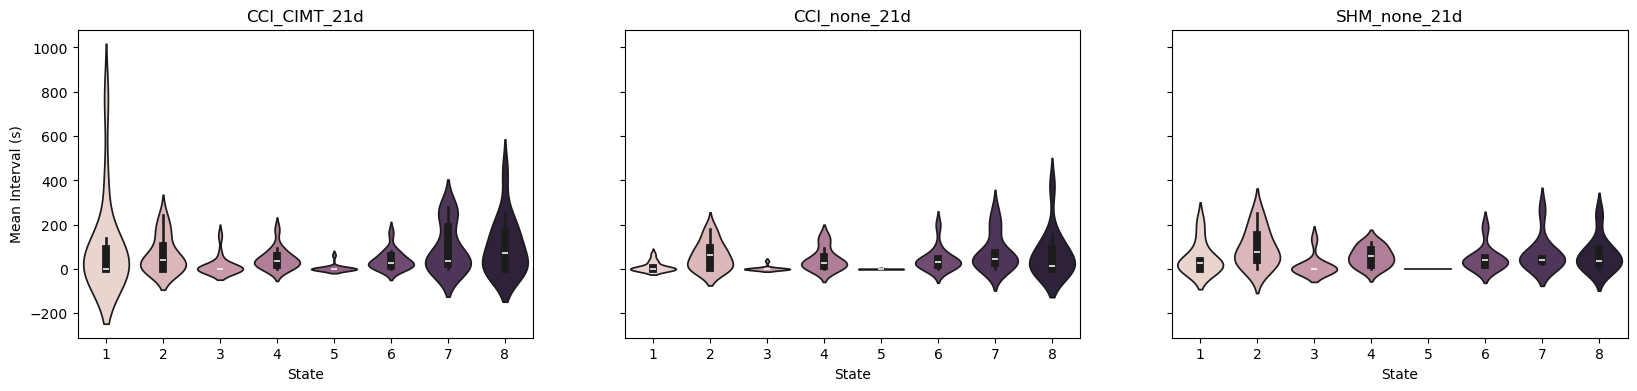

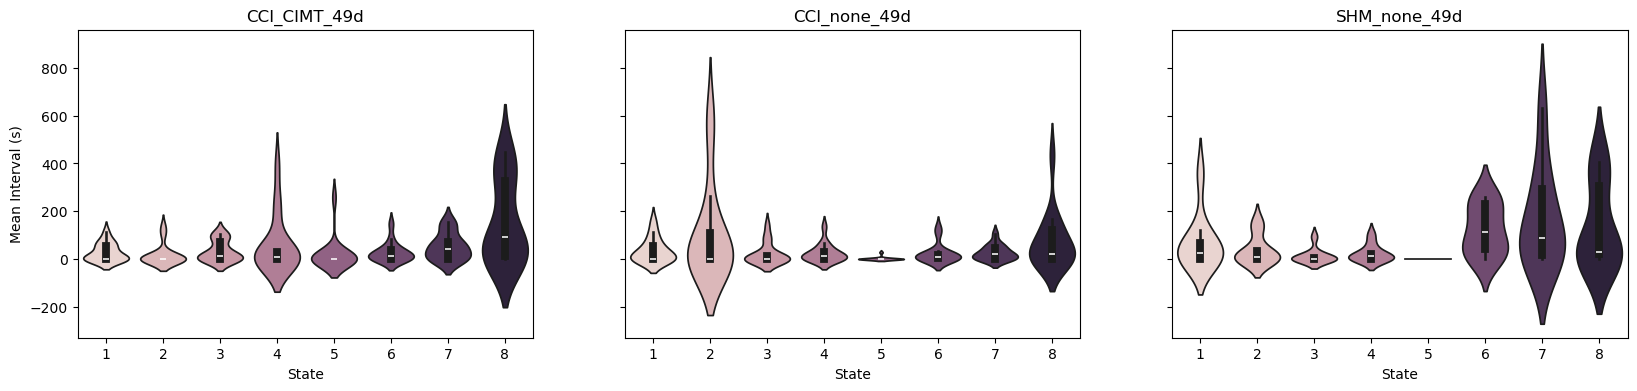

In [63]:
for group, attr in groups.items():
    # Print the group average
    print(f"{group}: {np.mean(attr['intv'], axis=0)}")

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
plotting.plot_violin(
    np.concatenate((groups['CCI_CIMT_07d']['intv'], groups['CCI_none_07d']['intv']), axis=0).T, 
    x_label="State", 
    y_label="Fractional Occupancy", 
    title="injured_07d", 
    ax=ax[0]
)
plotting.plot_violin(groups['SHM_none_07d']['intv'].T, x_label="State", y_label="Fractional Occupancy", title="SHM_none_07d", ax=ax[1])

for PID in ['07d', '21d', '49d']:
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
    plotting.plot_violin(groups['CCI_CIMT_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="CCI_CIMT_" + PID, ax=ax[0])
    plotting.plot_violin(groups['CCI_none_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="CCI_none_" + PID, ax=ax[1])
    plotting.plot_violin(groups['SHM_none_' + PID]['intv'].T, x_label="State", y_label="Mean Interval (s)", title="SHM_none_" + PID, ax=ax[2])

## Subject-Level Transition Probability Matrices

In [64]:
subj_trans_matrices = post_hoc.calc_trans_prob_matrix(stc, n_states=optimal_num_states)
subj_trans_matrices.shape

(114, 8, 8)

In [65]:
for group in groups:
    group_trans_matrices = subj_trans_matrices[np.where(y == group)]
    groups[group]['trans_matrices'] = group_trans_matrices
    print(group_trans_matrices.shape)
    groups[group]['mean_trans_matrix'] = np.mean(group_trans_matrices, axis=0)
    print(groups[group]['mean_trans_matrix'].shape)

(15, 8, 8)
(8, 8)
(15, 8, 8)
(8, 8)
(15, 8, 8)
(8, 8)
(15, 8, 8)
(8, 8)
(13, 8, 8)
(8, 8)
(15, 8, 8)
(8, 8)
(8, 8, 8)
(8, 8)
(9, 8, 8)
(8, 8)
(9, 8, 8)
(8, 8)


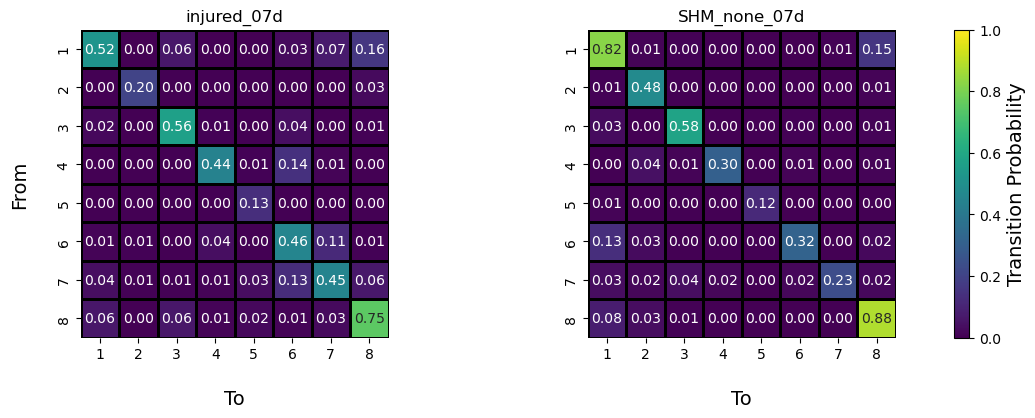

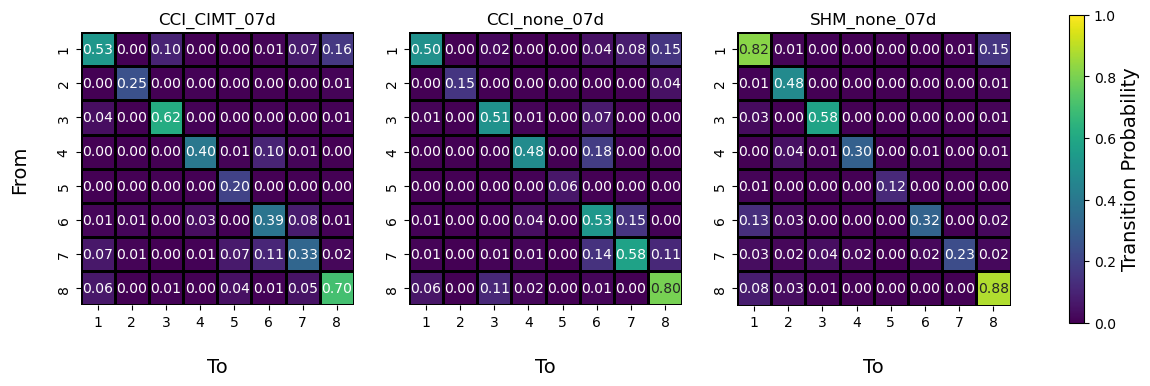

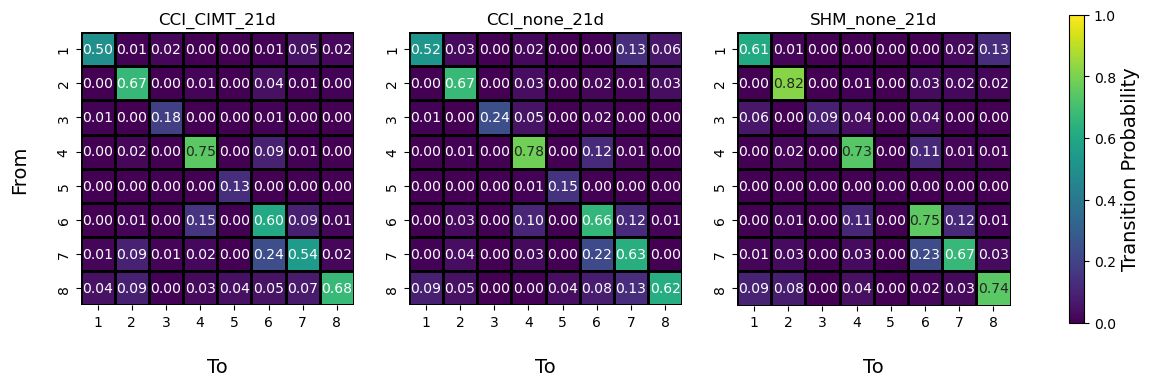

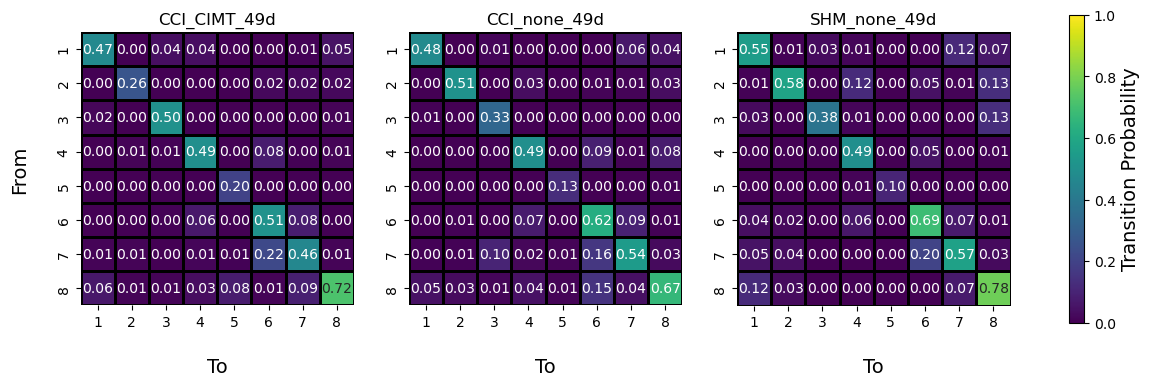

In [66]:
def heatmap_wrapper(data, ax):
    return sns.heatmap(
        data,
        cmap='viridis',
        linecolor='black',
        linewidths=1,
        cbar=False,
        annot=True,
        square=True,
        vmin=0,
        vmax=1,
        center=0.5,
        fmt='.2f',
        ax=ax,
    )

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
im = heatmap_wrapper(np.mean(subj_trans_matrices[np.where((y == 'CCI_CIMT_07d') | (y == 'CCI_none_07d'))], axis=0), axs[0])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
im.set_xticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
axs[0].set_title("injured_07d")

im = heatmap_wrapper(groups['SHM_none_07d']['mean_trans_matrix'], ax=axs[1])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
im.set_xticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
axs[1].set_title('SHM_none_07d')

cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
cbar.set_label('Transition Probability', fontsize=14)
plt.show()

for PID in ['07d', '21d', '49d']:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im = heatmap_wrapper(groups['CCI_CIMT_' + PID]['mean_trans_matrix'], ax=axs[0])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    im.set_xticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    axs[0].set_title("CCI_CIMT_" + PID)

    im = heatmap_wrapper(groups['CCI_none_' + PID]['mean_trans_matrix'], ax=axs[1])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    im.set_xticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    axs[1].set_title("CCI_none_" + PID)
    
    im = heatmap_wrapper(groups['SHM_none_' + PID]['mean_trans_matrix'], ax=axs[2])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    im.set_xticks(ticks=np.arange(0.5, optimal_num_states + 0.5, 1), labels=range(1, optimal_num_states + 1))
    axs[2].set_title("SHM_none_" + PID)

    cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
    cbar.set_label('Transition Probability', fontsize=14)
    plt.show()

### Create same plots using pyleida functions

In [287]:
def transition_probabilities(labels,k,norm=True,plot=False):
    """
    Compute the transitions between patterns across time
    for a single subject. The number of states ('k')
    defines the matrix shape, ensuring that, if a given
    subject don't traverse a state of the detected states
    for the whole group, the matrix will be constructed
    correctly, respecting the original number of states.
    If a subject don't traverse a particular state,
    then the corresponding row will contain all zeros.
    
    Params:
    ------
    labels : ndarray with shape (N_time_points,). 
        Contains the KMeans predicted label
        for each time point.

    norm : bool.
        Whether to normalize the values of the
        transitions matrix.

    plot : bool. 
        Whether to plot the transitions matrix.
    
    Returns:
    --------
    transitions : ndarray with shape (N_states,N_states).
    """

    N_states = k
    transitions = np.zeros((N_states, N_states)) #create empty matrix 
    N_volumes = labels.size 

    #compute the transitions
    for volume_idx in range(N_volumes-1):
        _from = labels[volume_idx]
        _to = _from + labels[volume_idx+1] - labels[volume_idx]
        transitions[_from,_to]+=1

    if norm:
        np.seterr(invalid='ignore') # hide potential warning when dividing 0/0 = NaN
        transitions = np.divide(
            transitions.astype(np.float64),
            np.sum(transitions,axis=1).reshape(transitions.shape[1],1)
            ) #normalize the values to probabilities

    #replace nan (if any) with 0. Can happen when a subject
    # doesn't traverse a state at all.
    transitions = np.nan_to_num(transitions,copy=True)
        
    if plot:
        plt.figure()
        sns.heatmap(
            transitions,
            annot=True,
            cmap='viridis', 
            square=True,
            linecolor='black',
            linewidths=0.5,
            xticklabels=[f'State {i+1}' for i in range(N_states)],
            yticklabels=[f'State {i+1}' for i in range(N_states)],
            cbar_kws={"shrink": 0.5}
            )
        plt.yticks(rotation='horizontal')
        plt.xlabel('To',fontsize=15,fontweight='regular')
        plt.ylabel('From',fontsize=15,fontweight='regular')
        plt.tight_layout()

    return transitions

def transition_probabilities_group(metadata,labels,save_results=False,path=None):
    """
    Compute the transition probabilities between
    phase-locking states for each subject in 'metadata'.

    Params:
    -------
    metadata : pd.dataframe (N_subjects x N_time_points, 2).
        Contains the metadata. 1st column contains
        the subjects ids, and 2nd column contains
        the class/conditions/sessions labels.

    labels : ndarray with shape (N_samples,). 
        Contains the clusters labels of each time
        point for each subject and condition contained
        in 'metadata'.

    save_results: bool. 
        Whether to save the computed transition
        probabilities in a .csv file.

    path : str. 
        Only provided if save_results=True. Define
        the path in which we want to save the results.

    Returns:
    --------
    results: pd.dataframe. 
        Contains 'subject_id' in 1st col, 'condition' in 2nd col,
        and a column for each transition [e.g. From_1_to_2,From_1_to_3 ...].
    """
    assert metadata.shape[0] == labels.shape[0], \
        "The number of rows in 'metadata' must be the same as in 'labels'"
    if save_results and path is None: 
        raise Exception('You must provide a path to save the results')

    results = []
    subjects_list,cond_list = [],[]
    N_clusters = len(np.unique(labels))
    for cond in np.unique(metadata.condition):
        subs_ids = metadata[metadata.condition==cond].subject_id.values #get an array with the subjects ids that belongs to a given condition.
        for subject in np.unique(subs_ids):
            idx = np.logical_and(metadata.subject_id==subject,metadata.condition==cond)
            tr = transition_probabilities(labels[idx],k=N_clusters,norm=True,plot=False)
            results.append(np.ravel(tr)) #vectorize the transitions matrix.
            subjects_list.append(subject)
            cond_list.append(cond)

    results = pd.DataFrame(np.vstack(results))
    columns_names = []
    for i in range(N_clusters):
        for j in range(N_clusters):
            columns_names.append(f'From_{i+1}_to_{j+1}')
    
    results.columns = columns_names
    results.insert(0,'subject_id',subjects_list)
    results.insert(1,'condition',cond_list)

    if save_results: 
        try:
            results.to_csv(f'{path}/transitions_probabilities.csv',sep='\t',index=False)
        except:
            print("The results could't be saved in .csv file. Please check the provided path.")

    return results

def group_transition_matrix(transitions_df,metric='mean',plot=True,cmap='inferno',darkstyle=False):
    """
    Compute and plot the mean or median transition matrix
    of each group (or a single group).

    Params:
    -------
    transitions_df : pd.DataFrame.
        Contains the transitions probabilities of each
        subject and group/condition. Output of the
        'transition_probabilities_group' function.

    metric : str.
       Select whether to compute the 'mean' or 'median'
       transition matrix for each group.

    plot : bool.
        Whether to plot the matrices.

    cmap : str.
        Select the cmap to use in the heatmap/s.

    darkstyle : bool.
        Whether to use a darkstyle for the plot.

    Returns:
    --------
    mats : dict. 
        Contains the groups names as keys, and a
        numpy 2D array (N_states,N_states) as values.
    """
    if not isinstance(metric,str):
        raise TypeError("'metric' must be a string!")
    else:
        if metric not in ['mean','median']:
            raise ValueError("Valid options for 'metric' are 'mean' or 'median'.")

    N_clusters = np.sqrt(len(transitions_df.columns[2:])).astype(int) #get the number of clusters/states.
    mats = {}

    conds = np.unique(transitions_df.condition)

    for cond in conds:
        if metric=='mean': 
            current_group_matrix = transitions_df[transitions_df.condition==cond].iloc[:,2:].mean().values.reshape(N_clusters,N_clusters)
        elif metric=='median':
            current_group_matrix = transitions_df[transitions_df.condition==cond].iloc[:,2:].median().values.reshape(N_clusters,N_clusters)
        mats[cond] = current_group_matrix

        if plot:
            #plotting
            with plt.style.context('dark_background' if darkstyle else 'default'):
                plt.figure(figsize=(5.5,4) if N_clusters<10 else (8,6) if 10<N_clusters<15 else (10,8))
                sns.heatmap(
                    current_group_matrix,
                    cmap=cmap,
                    linecolor='black' if not darkstyle else 'white',
                    linewidths=1,
                    annot=True,
                    square=True,
                    cbar_kws={"shrink": .5,"label":"Transition\nprobability"},
                    vmin=0,
                    vmax=1,
                    center=0.5,
                    fmt='.2f'
                    )
                plt.xlabel('To',fontsize=15,fontweight='regular',labelpad=20)
                plt.ylabel('From',fontsize=15,fontweight='regular',labelpad=20)
                plt.yticks(np.arange(0.5,N_clusters+.5,1),[f'State {i+1}' for i in range(N_clusters)],fontweight='regular',rotation='horizontal')
                if N_clusters<=5:
                    plt.xticks(np.arange(0.5,N_clusters+.5,1),[f'State {i+1}' for i in range(N_clusters)],fontweight='regular')
                else:
                    plt.xticks(np.arange(0.5,N_clusters+.5,1),[f'State {i+1}' for i in range(N_clusters)],fontweight='regular',rotation=30,horizontalalignment="right")
                plt.title(cond,fontweight='regular',fontsize=18)
                plt.tight_layout()
                plt.show()

    return mats

In [288]:
subj_order_extended = []
for l in [[subj] * X.shape[1] for subj in subj_order]:
    subj_order_extended += l

metadata = pd.DataFrame({
    'subject_id': subj_order_extended,
    'condition': [subj[:-4] for subj in subj_order_extended]
})

In [189]:
stc_clean = []
for tc in stc:
    stc_clean.append(np.argmax(tc, axis=1))

all_samples_stc = np.concatenate(stc_clean, axis=0)
all_samples_stc.shape

(28500,)

In [190]:
group_trans_probs = transition_probabilities_group(metadata=metadata,labels=all_samples_stc)
group_trans_probs.head()

,subject_id,condition,From_1_to_1,From_1_to_2,From_1_to_3,From_1_to_4,From_2_to_1,From_2_to_2,From_2_to_3,From_2_to_4,From_3_to_1,From_3_to_2,From_3_to_3,From_3_to_4,From_4_to_1,From_4_to_2,From_4_to_3,From_4_to_4
0,CCI_CIMT_07d_001,CCI_CIMT_07d,0.790698,0.046512,0.023256,0.139535,0.037736,0.679245,0.037736,0.245283,0.000000,0.037037,0.901235,0.061728,0.097222,0.166667,0.069444,0.666667
1,CCI_CIMT_07d_004,CCI_CIMT_07d,0.000000,0.000000,0.000000,0.000000,0.000000,0.680000,0.000000,0.320000,0.000000,0.000000,0.833333,0.166667,0.000000,0.088083,0.005181,0.906736
2,CCI_CIMT_07d_006,CCI_CIMT_07d,0.666667,0.200000,0.000000,0.133333,0.028571,0.571429,0.028571,0.371429,0.000000,0.000000,0.769231,0.230769,0.013245,0.178808,0.006623,0.801325
3,CCI_CIMT_07d_007,CCI_CIMT_07d,0.700000,0.100000,0.100000,0.100000,0.017857,0.625000,0.017857,0.339286,0.023256,0.093023,0.790698,0.093023,0.007143,0.121429,0.050000,0.821429
4,CCI_CIMT_07d_010,CCI_CIMT_07d,0.000000,0.000000,0.000000,0.000000,0.000000,0.377778,0.000000,0.622222,0.000000,1.000000,0.000000,0.000000,0.000000,0.128079,0.004926,0.866995


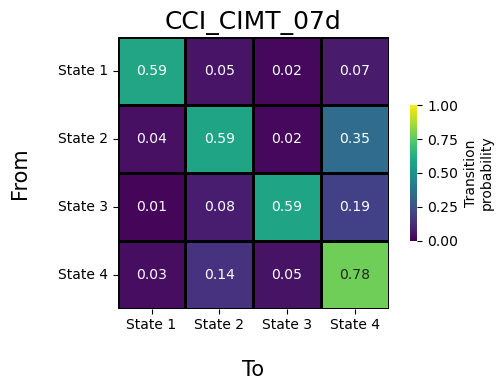

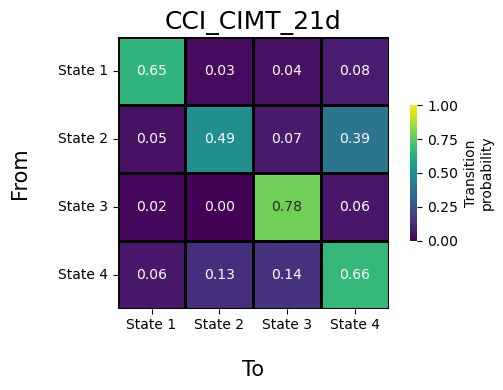

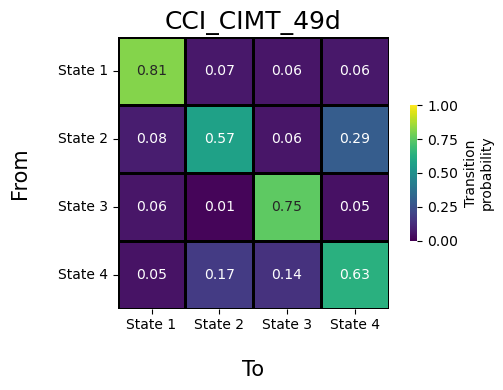

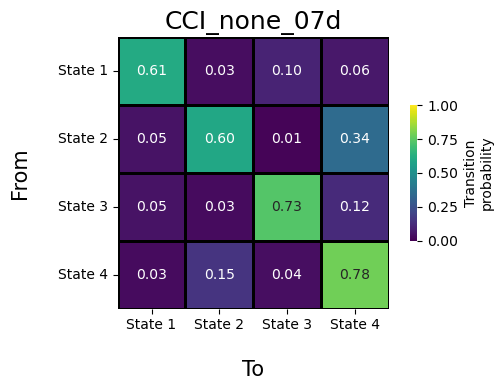

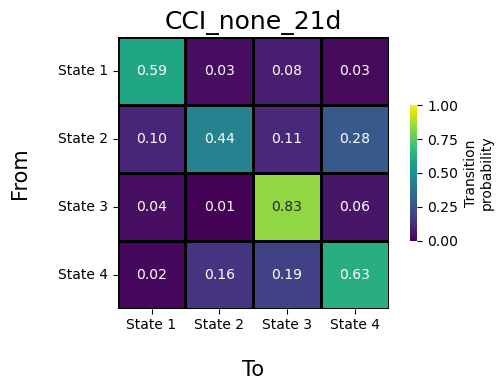

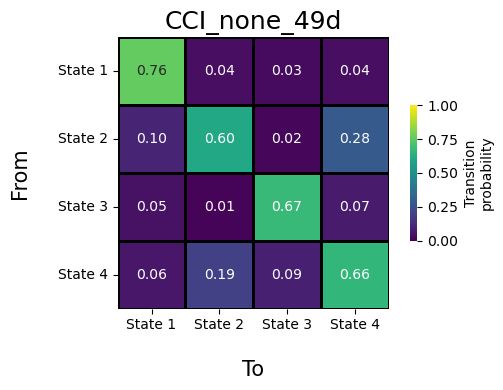

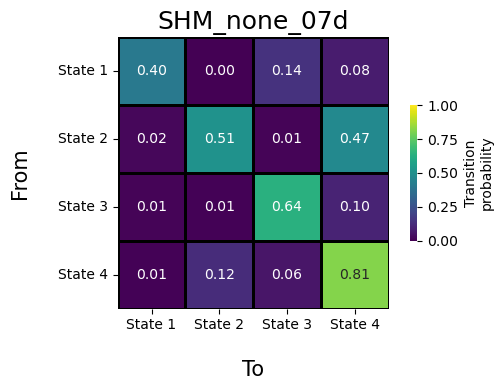

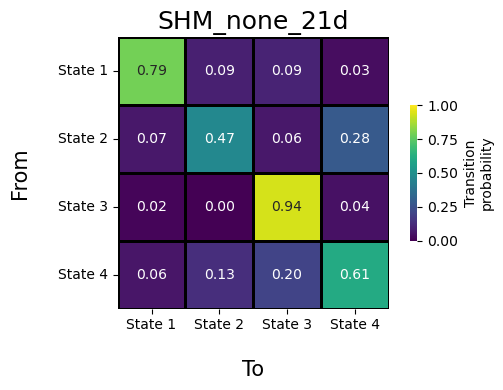

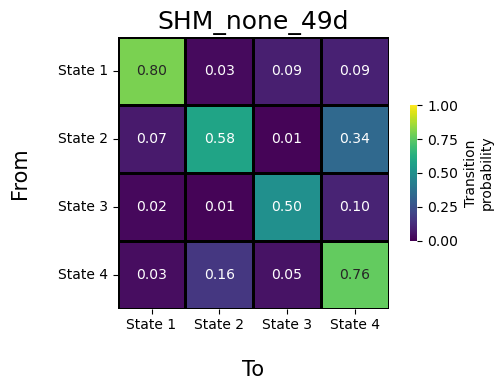

{'CCI_CIMT_07d': array([[0.58796803, 0.05250649, 0.02059114, 0.07226768],
        [0.04213026, 0.58589919, 0.0206495 , 0.35132104],
        [0.01210706, 0.08011642, 0.58523603, 0.18920716],
        [0.0312603 , 0.14135569, 0.04965672, 0.77772729]]),
 'CCI_CIMT_21d': array([[0.65048601, 0.02842823, 0.04061002, 0.08047575],
        [0.04531732, 0.49382143, 0.0733697 , 0.38749154],
        [0.02160606, 0.00397875, 0.78191463, 0.05916723],
        [0.06346492, 0.13028717, 0.14140372, 0.6648442 ]]),
 'CCI_CIMT_49d': array([[0.81476569, 0.06523746, 0.05612188, 0.06387497],
        [0.08049406, 0.57194368, 0.05742219, 0.29014007],
        [0.05588286, 0.01403807, 0.75117659, 0.04556915],
        [0.05009903, 0.17449371, 0.14148012, 0.63392714]]),
 'CCI_none_07d': array([[0.60584751, 0.03468016, 0.09651034, 0.06296199],
        [0.04930098, 0.59613667, 0.00997183, 0.34459052],
        [0.05000721, 0.03041331, 0.73224578, 0.12066704],
        [0.02766778, 0.15153634, 0.03901714, 0.78177874]]),


In [191]:
group_transition_matrix(group_trans_probs, cmap='viridis')

# Hypothesis Testing

In [192]:
def mannwhitneyu_statistic(x, y, axis):
    return mannwhitneyu(x, y, axis=axis).statistic

def kruskal_statistic(x, y, z, axis):
    return kruskal(x, y, z, axis=axis).statistic

def anova_statistic(x, y, z, axis):
    return f_oneway(x, y, z, axis=axis).statistic

In [193]:
def pt(metric, state, day, test, n_resamples, rng):
    if day == '07d':
        data = (
            np.concatenate((
                groups['CCI_CIMT_' + day][metric][:, state - 1], 
                groups['CCI_none_' + day][metric][:, state - 1], 
            )),
            groups['SHM_none_' + day][metric][:, state - 1]
        )
    elif day == '21d' or day == '49d':
        data = (
            groups['CCI_CIMT_' + day][metric][:, state - 1], 
            groups['CCI_none_' + day][metric][:, state - 1], 
            groups['SHM_none_' + day][metric][:, state - 1]
        )
        
    return permutation_test(
        data=data, 
        statistic=test, 
        permutation_type='independent',
        n_resamples=n_resamples,
        rng=rng,
    )

## 07d

In [194]:
for state, _ in sorted_fos:
    pt_res = pt('fo', state, '07d', mannwhitneyu_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 89.5
p-value: 0.2853714628537146

Testing with state 3...
Test statistic: 105.0
p-value: 0.6059394060593941

Testing with state 1...
Test statistic: 160.5
p-value: 0.14058594140585942

Testing with state 2...
Test statistic: 152.0
p-value: 0.251974802519748


In [195]:
for state, _ in sorted_fos:
    pt_res = pt('lt', state, '07d', mannwhitneyu_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 99.5
p-value: 0.4747525247475253

Testing with state 3...
Test statistic: 113.0
p-value: 0.8069193080691931

Testing with state 1...
Test statistic: 147.0
p-value: 0.32456754324567544

Testing with state 2...
Test statistic: 160.5
p-value: 0.15258474152584742


In [196]:
for state, _ in sorted_fos:
    pt_res = pt('intv', state, '07d', mannwhitneyu_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 156.0
p-value: 0.20357964203579643

Testing with state 3...
Test statistic: 167.5
p-value: 0.0867913208679132

Testing with state 1...
Test statistic: 133.0
p-value: 0.6301369863013698

Testing with state 2...
Test statistic: 107.0
p-value: 0.6531346865313469


## 21d

In [197]:
for state, _ in sorted_fos:
    pt_res = pt('fo', state, '21d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 1.2920143838871345
p-value: 0.936906309369063

Testing with state 3...
Test statistic: 1.9780867914887372
p-value: 0.7519248075192481

Testing with state 1...
Test statistic: 0.2170797077504889
p-value: 0.192980701929807

Testing with state 2...
Test statistic: 0.9575380283750033
p-value: 0.7611238876112388


In [198]:
for state, _ in sorted_fos:
    pt_res = pt('lt', state, '21d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 2.1913593944042695
p-value: 0.682931706829317

Testing with state 3...
Test statistic: 3.518611567232264
p-value: 0.34636536346365365

Testing with state 1...
Test statistic: 0.48049743024962066
p-value: 0.41515848415158485

Testing with state 2...
Test statistic: 0.30638614314479834
p-value: 0.27217278272172785


In [199]:
for state, _ in sorted_fos:
    pt_res = pt('intv', state, '21d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 3.2183451924831212
p-value: 0.3855614438556144

Testing with state 3...
Test statistic: 0.3803959131545288
p-value: 0.34656534346565343

Testing with state 1...
Test statistic: 4.861335329120011
p-value: 0.17118288171182883

Testing with state 2...
Test statistic: 0.0725321320334438
p-value: 0.06999300069993


## 49d

In [200]:
for state, _ in sorted_fos:
    pt_res = pt('fo', state, '49d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 7.728061941251595
p-value: 0.034596540345965404

Testing with state 3...
Test statistic: 3.86307399837973
p-value: 0.28677132286771323

Testing with state 1...
Test statistic: 1.014303244288737
p-value: 0.7597240275972402

Testing with state 2...
Test statistic: 1.8895584747308876
p-value: 0.8033196680331967


In [201]:
for state, _ in sorted_fos:
    pt_res = pt('lt', state, '49d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 9.44595283707352
p-value: 0.015398460153984602

Testing with state 3...
Test statistic: 4.72337853013735
p-value: 0.18238176182381763

Testing with state 1...
Test statistic: 0.32640606757151014
p-value: 0.296970302969703

Testing with state 2...
Test statistic: 1.00744315273817
p-value: 0.7787221277872213


In [202]:
for state, _ in sorted_fos:
    pt_res = pt('intv', state, '49d', kruskal_statistic, 10000, 42)
    print(f"\nTesting with state {state}...")
    print("Test statistic:", pt_res.statistic) 
    print("p-value:", pt_res.pvalue)


Testing with state 4...
Test statistic: 3.051282051282044
p-value: 0.45035496450354967

Testing with state 3...
Test statistic: 0.7928399635985408
p-value: 0.6461353864613538

Testing with state 1...
Test statistic: 1.5846804854865835
p-value: 0.9009099090090991

Testing with state 2...
Test statistic: 2.4863697705802963
p-value: 0.6013398660133986
